# SKU-Node Correlation Analysis

Exploratory analysis of correlations between pricing, inventory, and sales at the SKU-Node-Date level.

**Business questions:**
- How do NLC price changes affect subsequent sales volume?
- What factors most influence sales at the SKU-Node level?
- What margin levels maximize total revenue/profit?

## 1. Parameters & Setup

In [1]:
# === PARAMETERS ===
ANALYSIS_DAYS = 30
END_DATE = "2026-03-25"
TOP_SKU_PCT = 0.90
SKU_SALES_LOOKBACK_DAYS = 60
ROLLING_WINDOW = 7
INVENTORY_SAMPLE_FREQ = "4D"
WAREHOUSE_ADDRESSES_PATH = r"C:\Users\valen\Desktop\WalmartPricing\Warehouse Addresses 03-25-2026 01-43-16 PM.csv"
ROLLBACKS_PATH = None  # Set to rollbacks Excel path to exclude rollback SKUs

In [2]:
import sys
import os
import logging
import warnings
from datetime import timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add project root to path
sys.path.insert(0, os.path.abspath(".."))

from src.data.loader import DataLoader
from src.adapters.module_loader import load_yaml, ensure_modules_path

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

In [3]:
# Derived date boundaries
end_dt = pd.to_datetime(END_DATE)
start_dt = end_dt - pd.Timedelta(days=ANALYSIS_DAYS - 1)
warmup_dt = start_dt - pd.Timedelta(days=ROLLING_WINDOW)
sku_filter_start_dt = end_dt - pd.Timedelta(days=SKU_SALES_LOOKBACK_DAYS)

START_DATE = start_dt.strftime("%Y-%m-%d")
WARMUP_DATE = warmup_dt.strftime("%Y-%m-%d")
SKU_FILTER_START = sku_filter_start_dt.strftime("%Y-%m-%d")

print(f"Analysis window: {START_DATE} to {END_DATE}")
print(f"Warmup start (for rolling): {WARMUP_DATE}")
print(f"SKU filter lookback start: {SKU_FILTER_START}")

Analysis window: 2026-02-24 to 2026-03-25
Warmup start (for rolling): 2026-02-17
SKU filter lookback start: 2026-01-24


In [4]:
# Initialize loader and configs
loader = DataLoader()
nlc_config = load_yaml("nlc_model.yaml")

## 2. SKU Filtering (top 90% by qty sold)

In [5]:
# Load 2-month sales for SKU filtering
df_sales_filter = loader.load("dw_walmart_sales", start_date=SKU_FILTER_START)
print(f"Sales rows (last {SKU_SALES_LOOKBACK_DAYS} days): {len(df_sales_filter):,}")

2026-03-30 18:05:36,574 INFO Loading source: dw_walmart_sales (type=sql)


2026-03-30 18:05:36,786 INFO Data warehouse module loaded.


Sales rows (last 60 days): 227,605


In [6]:
# Identify top SKUs by cumulative quantity sold
df_sku_qty = (
    df_sales_filter.groupby("sku")["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"quantity": "total_qty"})
    .sort_values("total_qty", ascending=False)
    .reset_index(drop=True)
)
df_sku_qty["cum_qty"] = df_sku_qty["total_qty"].cumsum()
df_sku_qty["cum_pct"] = df_sku_qty["cum_qty"] / df_sku_qty["total_qty"].sum()

# Include the first SKU that crosses the threshold
cutoff_idx = (df_sku_qty["cum_pct"] <= TOP_SKU_PCT).sum()
top_skus = set(df_sku_qty.iloc[: cutoff_idx + 1]["sku"].tolist())

print(f"Total unique SKUs with sales: {df_sku_qty.shape[0]:,}")
print(f"Top {TOP_SKU_PCT:.0%} SKUs selected: {len(top_skus):,}")
print(f"Coverage: {df_sku_qty.iloc[:cutoff_idx + 1]['total_qty'].sum() / df_sku_qty['total_qty'].sum():.1%}")

Total unique SKUs with sales: 20,075
Top 90% SKUs selected: 6,447
Coverage: 90.0%


In [7]:
# Optionally exclude rollback SKUs
if ROLLBACKS_PATH:
    df_rollbacks = loader.load("rollbacks", rollbacks_path=ROLLBACKS_PATH)
    df_rollbacks["End date"] = pd.to_datetime(df_rollbacks["End date"])
    active_rollbacks = df_rollbacks[df_rollbacks["End date"] > start_dt]["Product Code"].unique()
    before = len(top_skus)
    top_skus -= set(active_rollbacks)
    print(f"Excluded {before - len(top_skus)} rollback SKUs, {len(top_skus)} remaining")
else:
    print("Rollback exclusion skipped (ROLLBACKS_PATH not set)")

Rollback exclusion skipped (ROLLBACKS_PATH not set)


## 3. Load Daily Sales

In [8]:
# Load sales for analysis window + 7-day warmup
df_sales_raw = loader.load("dw_walmart_sales", start_date=WARMUP_DATE)
df_sales_raw["order_date"] = pd.to_datetime(df_sales_raw["order_date"])

# Filter to top SKUs and analysis+warmup window
df_sales_raw = df_sales_raw[
    (df_sales_raw["sku"].isin(top_skus))
    & (df_sales_raw["order_date"] <= end_dt)
].copy()

print(f"Sales rows after filtering: {len(df_sales_raw):,}")

2026-03-30 18:06:07,078 INFO Loading source: dw_walmart_sales (type=sql)


Sales rows after filtering: 123,782


In [9]:
# Aggregate to SKU-Node-Date level
df_sales_agg = (
    df_sales_raw
    .groupby(["sku", "externalwarehouseid", "order_date"])
    .agg(
        qty_sold=("quantity", "sum"),
        revenue=("total_inv_amount", "sum"),
        profit=("profit", "sum"),
    )
    .reset_index()
    .rename(columns={"externalwarehouseid": "node", "order_date": "date"})
)
df_sales_agg["node"] = df_sales_agg["node"].astype(str)

# Valid SKU-Nodes: any with at least 1 sale in the full window
sku_nodes = df_sales_agg[["sku", "node"]].drop_duplicates()
print(f"Unique SKU-Nodes with sales: {len(sku_nodes):,}")
print(f"Daily aggregated rows: {len(df_sales_agg):,}")

Unique SKU-Nodes with sales: 44,690
Daily aggregated rows: 90,605


## 4. Build Date Scaffold

In [10]:
# Full date range including warmup
all_dates = pd.date_range(warmup_dt, end_dt, freq="D")
df_dates = pd.DataFrame({"date": all_dates})

# Cross-join: every SKU-Node x every date
scaffold = sku_nodes.merge(df_dates, how="cross")
print(f"Scaffold shape: {scaffold.shape[0]:,} rows ({len(sku_nodes):,} SKU-Nodes x {len(all_dates)} days)")

# Left-join sales
scaffold = scaffold.merge(df_sales_agg, on=["sku", "node", "date"], how="left")
scaffold["qty_sold"] = scaffold["qty_sold"].fillna(0)
scaffold["revenue"] = scaffold["revenue"].fillna(0)
scaffold["profit"] = scaffold["profit"].fillna(0)

print(f"Non-zero sales days: {(scaffold['qty_sold'] > 0).sum():,} / {len(scaffold):,}")

Scaffold shape: 1,653,530 rows (44,690 SKU-Nodes x 37 days)


Non-zero sales days: 90,605 / 1,653,530


## 5. DSV History (Cost to Walmart)

In [11]:
import re

# List all DSV files and parse dates
dsv_config = loader.get_source_config("walmart_dsv_folder")
dsv_files = loader.google.get_folder_files(dsv_config["id"])

dsv_files["parsed_date"] = dsv_files["Name"].apply(
    lambda x: re.search(r"\d{4}-\d{2}-\d{2}", str(x))
)
dsv_files = dsv_files[dsv_files["parsed_date"].notna()].copy()
dsv_files["dsv_date"] = dsv_files["parsed_date"].apply(lambda m: pd.to_datetime(m.group()))
dsv_files = dsv_files.drop(columns=["parsed_date"])

# Filter to files relevant to our window (warmup_dt - 30 days buffer to END_DATE)
buffer_start = warmup_dt - pd.Timedelta(days=30)
dsv_files = dsv_files[
    (dsv_files["dsv_date"] >= buffer_start) & (dsv_files["dsv_date"] <= end_dt)
].sort_values("dsv_date")

# Deduplicate: keep only the LATEST file per date (later upload supersedes)
dsv_files = dsv_files.sort_values("Name").groupby("dsv_date").last().reset_index()
dsv_files = dsv_files.sort_values("dsv_date")

print(f"DSV files in range (deduplicated): {len(dsv_files)}")
print(dsv_files[["Name", "dsv_date"]].to_string(index=False))


2026-03-30 18:06:21,565 INFO Initializing Google API service connection...


2026-03-30 18:06:22,613 INFO file_cache is only supported with oauth2client<4.0.0


2026-03-30 18:06:22,623 INFO file_cache is only supported with oauth2client<4.0.0


2026-03-30 18:06:22,626 INFO Google API service connected.


DSV files in range (deduplicated): 40
                                             Name   dsv_date
dsvpriceupload-walmartb2b-2026-01-20_19-08-49.csv 2026-01-20
dsvpriceupload-walmartb2b-2026-01-27_00-44-46.csv 2026-01-27
dsvpriceupload-walmartb2b-2026-01-28_05-00-13.csv 2026-01-28
dsvpriceupload-walmartb2b-2026-01-29_06-54-35.csv 2026-01-29
dsvpriceupload-walmartb2b-2026-01-30_05-19-01.csv 2026-01-30
dsvpriceupload-walmartb2b-2026-02-02_19-14-26.csv 2026-02-02
dsvpriceupload-walmartb2b-2026-02-03_07-31-45.csv 2026-02-03
dsvpriceupload-walmartb2b-2026-02-04_06-28-35.csv 2026-02-04
dsvpriceupload-walmartb2b-2026-02-05_10-02-51.csv 2026-02-05
dsvpriceupload-walmartb2b-2026-02-06_08-49-22.csv 2026-02-06
dsvpriceupload-walmartb2b-2026-02-09_07-54-20.csv 2026-02-09
dsvpriceupload-walmartb2b-2026-02-11_04-14-28.csv 2026-02-11
dsvpriceupload-walmartb2b-2026-02-12_08-39-38.csv 2026-02-12
dsvpriceupload-walmartb2b-2026-02-16_06-36-29.csv 2026-02-16
dsvpriceupload-walmartb2b-2026-02-17_05-02-13.c

In [12]:
# Load each DSV file, filtering to top SKUs immediately to manage memory
# Each raw file has ~2M rows; filtering to top 6K SKUs reduces to ~125K each
dsv_snapshots = []
for idx, (_, row) in enumerate(dsv_files.iterrows()):
    df_dsv_i = loader.google.get_file_as_df(
        row["ID"], "csv",
        read_cols=["SKU", "Price", "Source"],
        dtype={"SKU": str, "Price": float, "Source": str},
    )
    # Filter to top SKUs immediately to save memory
    df_dsv_i = df_dsv_i[df_dsv_i["SKU"].isin(top_skus)].copy()
    df_dsv_i = df_dsv_i.drop_duplicates(subset=["SKU", "Source"], keep="first")
    df_dsv_i["dsv_date"] = row["dsv_date"]
    dsv_snapshots.append(df_dsv_i)
    if (idx + 1) % 10 == 0 or idx == 0:
        logger.info("Loaded DSV %d/%d: %s (%d rows after SKU filter)",
                     idx + 1, len(dsv_files), row["Name"], len(df_dsv_i))

df_dsv_all = pd.concat(dsv_snapshots, ignore_index=True)
df_dsv_all = df_dsv_all.rename(columns={"SKU": "sku", "Price": "cost_to_walmart", "Source": "source"})
df_dsv_all["source"] = df_dsv_all["source"].astype(str)

print(f"Total DSV rows (filtered to top SKUs): {len(df_dsv_all):,}")
print(f"Unique DSV dates: {df_dsv_all['dsv_date'].nunique()}")


Download 100.


2026-03-30 18:06:34,378 INFO Loaded DSV 1/40: dsvpriceupload-walmartb2b-2026-01-20_19-08-49.csv (465202 rows after SKU filter)


Download 100.


Download 100.


Download 100.


...

Download 100.


Download 87.


Download 100.


2026-03-30 18:10:17,331 INFO Loaded DSV 40/40: dsvpriceupload-walmartb2b-2026-03-24_07-22-00.csv (607720 rows after SKU filter)


Total DSV rows (filtered to top SKUs): 22,915,930
Unique DSV dates: 40


In [13]:
# For each scaffold row, assign cost_to_walmart from the most recent DSV
# Strategy: for each analysis date, find the latest DSV date <= that date

# Step 1: Node-specific prices (source = node identifier)
df_dsv_node = df_dsv_all[df_dsv_all["source"] != "nan"].copy()
df_dsv_node = df_dsv_node.rename(columns={"source": "node"})
df_dsv_node = df_dsv_node.sort_values("dsv_date")

# Step 2: National prices (source = nan/null) as fallback
df_dsv_national = df_dsv_all[df_dsv_all["source"] == "nan"].copy()
df_dsv_national = df_dsv_national[["sku", "cost_to_walmart", "dsv_date"]].sort_values("dsv_date")

# merge_asof for node-specific prices
scaffold = scaffold.sort_values("date")
df_dsv_node = df_dsv_node.sort_values("dsv_date")

scaffold = pd.merge_asof(
    scaffold.sort_values("date"),
    df_dsv_node[["sku", "node", "cost_to_walmart", "dsv_date"]].sort_values("dsv_date"),
    left_on="date",
    right_on="dsv_date",
    by=["sku", "node"],
    direction="backward",
    suffixes=("", "_dsv"),
)

# Fill NaN cost_to_walmart with national price fallback
scaffold_missing = scaffold[scaffold["cost_to_walmart"].isna()].copy()
if len(scaffold_missing) > 0:
    scaffold_missing = scaffold_missing.drop(columns=["cost_to_walmart", "dsv_date"])
    scaffold_missing = pd.merge_asof(
        scaffold_missing.sort_values("date"),
        df_dsv_national.rename(columns={"cost_to_walmart": "cost_to_walmart_nat", "dsv_date": "dsv_date_nat"}),
        left_on="date",
        right_on="dsv_date_nat",
        by="sku",
        direction="backward",
    )
    # Update scaffold with national fallback
    scaffold.loc[scaffold["cost_to_walmart"].isna(), "cost_to_walmart"] = (
        scaffold_missing["cost_to_walmart_nat"].values
    )

scaffold = scaffold.drop(columns=["dsv_date"], errors="ignore")

pct_with_price = scaffold["cost_to_walmart"].notna().mean()
print(f"Rows with cost_to_walmart: {pct_with_price:.1%}")
print(f"Rows missing price: {scaffold['cost_to_walmart'].isna().sum():,}")

Rows with cost_to_walmart: 94.3%
Rows missing price: 94,743


## 6. Walmart Offer Prices

In [14]:
# Load item report (single snapshot for END_DATE)
# Note: assumes offer prices are relatively stable over the 30-day window
df_item_report = loader.load("dw_walmart_item_report", date_str=END_DATE)

# Keep relevant columns and filter to top SKUs
df_offer = df_item_report[["Product Code", "offer_price"]].copy()
df_offer = df_offer.rename(columns={"Product Code": "sku"})
df_offer = df_offer[df_offer["sku"].isin(top_skus)].drop_duplicates(subset="sku", keep="first")
df_offer["offer_price"] = pd.to_numeric(df_offer["offer_price"], errors="coerce")

print(f"Offer prices loaded: {len(df_offer):,} SKUs")

# Merge to scaffold
scaffold = scaffold.merge(df_offer, on="sku", how="left")
print(f"Rows with offer_price: {scaffold['offer_price'].notna().sum():,} / {len(scaffold):,}")

2026-03-30 18:10:28,994 INFO Loading source: dw_walmart_item_report (type=sql)


Offer prices loaded: 6,422 SKUs
Rows with offer_price: 1,650,977 / 1,653,530


## 7. Supporting Data

In [15]:
# MAP prices
df_map = loader.load("dw_map_prices", date_str=END_DATE)
df_map = df_map.rename(columns={"Product Code": "sku"})
df_map = df_map[["sku", "MAP"]].drop_duplicates(subset="sku", keep="first")
df_map["MAP"] = pd.to_numeric(df_map["MAP"], errors="coerce")
scaffold = scaffold.merge(df_map, on="sku", how="left")
print(f"SKUs with MAP: {scaffold['MAP'].notna().sum():,} rows")

# Shipping costs
df_shipping = loader.load("shipping_costs_by_node")
df_shipping = df_shipping.rename(columns={"Identifier": "node"})
df_shipping["node"] = df_shipping["node"].astype(str)
scaffold = scaffold.merge(df_shipping[["node", "Shipping cost"]], on="node", how="left")
scaffold = scaffold.rename(columns={"Shipping cost": "shipping_cost"})
print(f"Rows with shipping cost: {scaffold['shipping_cost'].notna().sum():,}")

2026-03-30 18:10:55,765 INFO Loading source: dw_map_prices (type=sql)


2026-03-30 18:11:00,433 INFO Loading source: shipping_costs_by_node (type=local)


SKUs with MAP: 235,135 rows


Rows with shipping cost: 27,935


In [16]:
# Warehouse node mapping (for bridging Warehouse Code <-> Identifier)
df_wh_mapping = loader.load("warehouse_node_mapping")
df_wh_mapping["Identifier"] = df_wh_mapping["Identifier"].astype(str)
df_wh_mapping["Warehouse Code"] = df_wh_mapping["Warehouse Code"].astype(str)
node_to_wh = df_wh_mapping[["Identifier", "Warehouse Code"]].drop_duplicates(subset="Identifier")

# Warehouse addresses -> city/state
df_addresses = pd.read_csv(WAREHOUSE_ADDRESSES_PATH, dtype={"Code": str})
df_city = df_addresses[["Code", "Town", "State"]].rename(columns={"Code": "Warehouse Code"})

# Join: node -> Warehouse Code -> Town/State
node_city = node_to_wh.merge(df_city, on="Warehouse Code", how="left")
node_city = node_city.rename(columns={"Identifier": "node"})

scaffold = scaffold.merge(node_city[["node", "Town", "State"]], on="node", how="left")
print(f"Rows with city mapping: {scaffold['Town'].notna().sum():,} / {len(scaffold):,}")

2026-03-30 18:11:00,966 INFO Loading source: warehouse_node_mapping (type=folder)


Last modified time 2026-03-30T10:00:24.912Z


Download 100.


Rows with city mapping: 1,653,530 / 1,653,530


## 8. Inventory (sampled every 4 days)

In [17]:
# Lazy import pricing_module
ensure_modules_path()
import pricing_module as pricing

# Sample dates across the window
inv_dates = pd.date_range(start_dt, end_dt, freq=INVENTORY_SAMPLE_FREQ).strftime("%Y-%m-%d").tolist()
# Ensure END_DATE is included
if END_DATE not in inv_dates:
    inv_dates.append(END_DATE)

print(f"Inventory dates to load: {len(inv_dates)}")
print(inv_dates)

Running python file...


2026-03-30 18:11:03,900 INFO file_cache is only supported with oauth2client<4.0.0


2026-03-30 18:11:03,912 INFO file_cache is only supported with oauth2client<4.0.0


Inventory dates to load: 9
['2026-02-24', '2026-02-28', '2026-03-04', '2026-03-08', '2026-03-12', '2026-03-16', '2026-03-20', '2026-03-24', '2026-03-25']


In [18]:
# Load inventory for sampled dates
min_units = nlc_config["inventory"]["min_units_secondary"]  # 4

# Warehouse node mapping for filtering (WalmartB2B, ENABLED, Inventory Enabled=1)
df_wh_filt = df_wh_mapping[
    (df_wh_mapping["Channel"] == "WalmartB2B")
    & (df_wh_mapping["Warehouse Status"] == "ENABLED")
    & (df_wh_mapping["Identifier Status"] == "ENABLED")
    & (df_wh_mapping["Inventory Enabled"] == 1)
].copy()

inv_records = []
for date_i in inv_dates:
    logger.info("Loading inventory for %s...", date_i)
    df_inv_i = pricing.get_inventory(date_i, add_rebates=False, amazon=False, greater3=True)
    df_inv_i["date"] = pd.to_datetime(date_i)
    
    # Filter by min_units
    df_inv_i = df_inv_i[df_inv_i["Available"] >= min_units].copy()
    
    # Filter to top SKUs
    df_inv_i = df_inv_i[df_inv_i["Product Code"].isin(top_skus)].copy()
    
    # Merge with node mapping
    df_inv_i["Warehouse Code"] = df_inv_i["Warehouse Code"].astype(str)
    df_inv_i = df_inv_i.merge(
        df_wh_filt[["Warehouse Code", "Identifier", "Inventory Threshold"]],
        on="Warehouse Code", how="inner"
    )
    
    # Filter by Inventory Threshold
    df_inv_i = df_inv_i[df_inv_i["Available"] >= df_inv_i["Inventory Threshold"]].copy()
    
    # Per SKU-Node: min Purchase Price+FET
    df_inv_agg = (
        df_inv_i.groupby(["Product Code", "Identifier"])
        .agg({"Purchase Price+FET": "min"})
        .reset_index()
        .rename(columns={
            "Product Code": "sku",
            "Identifier": "node",
            "Purchase Price+FET": "min_purchase_price_fet",
        })
    )
    df_inv_agg["inv_date"] = pd.to_datetime(date_i)
    df_inv_agg["can_show_inv"] = 1
    inv_records.append(df_inv_agg)
    logger.info("  -> %d SKU-Node pairs with inventory", len(df_inv_agg))

df_inv_all = pd.concat(inv_records, ignore_index=True)
df_inv_all["node"] = df_inv_all["node"].astype(str)
print(f"Total inventory records: {len(df_inv_all):,}")


2026-03-30 18:11:03,924 INFO Loading inventory for 2026-02-24...


Download 100.


Last modified time 2026-02-24T11:01:34.374Z


Download 93.


Download 100.


...

Last modified time 2026-03-25T10:01:25.883Z


Download 96.


Download 100.


2026-03-30 18:13:41,698 INFO   -> 444958 SKU-Node pairs with inventory


Total inventory records: 4,092,760


In [19]:
# Forward-fill inventory to all analysis dates using merge_asof
scaffold = scaffold.sort_values("date")
df_inv_all = df_inv_all.sort_values("inv_date")

scaffold = pd.merge_asof(
    scaffold,
    df_inv_all[["sku", "node", "min_purchase_price_fet", "can_show_inv", "inv_date"]],
    left_on="date",
    right_on="inv_date",
    by=["sku", "node"],
    direction="backward",
)
scaffold["can_show_inv"] = scaffold["can_show_inv"].fillna(0).astype(int)
scaffold = scaffold.drop(columns=["inv_date"], errors="ignore")

print(f"Rows with inventory: {(scaffold['can_show_inv'] == 1).sum():,} / {len(scaffold):,}")
print(f"Rows with purchase price: {scaffold['min_purchase_price_fet'].notna().sum():,}")

Rows with inventory: 1,174,257 / 1,653,530
Rows with purchase price: 1,174,257


## 9. Assemble Master DataFrame

In [20]:
# Computed columns
scaffold["walmart_margin"] = (
    (scaffold["offer_price"] - scaffold["cost_to_walmart"]) / scaffold["offer_price"]
)
scaffold["te_margin"] = (
    (scaffold["cost_to_walmart"] - scaffold["min_purchase_price_fet"]) / scaffold["cost_to_walmart"]
)

# Brand = first 4 chars of SKU
scaffold["brand"] = scaffold["sku"].str[:4]

# Day of week
scaffold["day_of_week"] = scaffold["date"].dt.dayofweek  # 0=Mon, 6=Sun

# MAP proximity: how close cost_to_walmart is to the MAP floor
scaffold["map_proximity"] = scaffold["cost_to_walmart"] / (scaffold["MAP"] * 0.95)

# Can show inventory? (price-based visibility check)
# Min price to show inventory = (Purchase Price+FET) / 0.96  (Walmart 4% minimum margin)
# If cost_to_walmart > min_price_to_show_inv, Walmart can display the item
scaffold["min_price_to_show_inv"] = scaffold["min_purchase_price_fet"] / 0.96
scaffold["can_show_inventory"] = (
    scaffold["cost_to_walmart"] > scaffold["min_price_to_show_inv"]
)
# For rows missing either price, mark as False
scaffold["can_show_inventory"] = scaffold["can_show_inventory"].fillna(False)

print(f"can_show_inventory distribution:\n{scaffold['can_show_inventory'].value_counts()}")
print(f"can_show_inventory rate: {scaffold['can_show_inventory'].mean():.1%}")

# Number of active nodes per SKU per date
active_nodes = (
    scaffold[scaffold["can_show_inv"] == 1]
    .groupby(["sku", "date"])["node"]
    .nunique()
    .reset_index()
    .rename(columns={"node": "n_active_nodes"})
)
scaffold = scaffold.merge(active_nodes, on=["sku", "date"], how="left")
scaffold["n_active_nodes"] = scaffold["n_active_nodes"].fillna(0).astype(int)

print("Computed columns added.")
print(f"Columns: {scaffold.columns.tolist()}")

can_show_inventory distribution:
can_show_inventory
True     1131761
False     521769
Name: count, dtype: int64
can_show_inventory rate: 68.4%


Computed columns added.
Columns: ['sku', 'node', 'date', 'qty_sold', 'revenue', 'profit', 'cost_to_walmart', 'offer_price', 'MAP', 'shipping_cost', 'Town', 'State', 'min_purchase_price_fet', 'can_show_inv', 'walmart_margin', 'te_margin', 'brand', 'day_of_week', 'map_proximity', 'min_price_to_show_inv', 'can_show_inventory', 'n_active_nodes']


In [21]:
# Days since last price change (from DSV history)
# Build a per-SKU-Node price change timeline from DSV snapshots
dsv_prices = (
    df_dsv_all[df_dsv_all["source"] != "nan"]
    .rename(columns={"source": "node_dsv"})
    .sort_values("dsv_date")
)

# Detect price changes per SKU-Node
dsv_prices["prev_price"] = dsv_prices.groupby(["sku", "node_dsv"])["cost_to_walmart"].shift(1)
dsv_prices["price_changed"] = (
    (dsv_prices["cost_to_walmart"] != dsv_prices["prev_price"])
    & dsv_prices["prev_price"].notna()
)

# Get change dates
change_dates = dsv_prices[dsv_prices["price_changed"]][["sku", "node_dsv", "dsv_date"]].copy()
change_dates = change_dates.rename(columns={"node_dsv": "node", "dsv_date": "change_date"})
change_dates = change_dates.sort_values("change_date")

# For each scaffold row, find most recent price change
if len(change_dates) > 0:
    scaffold = scaffold.sort_values("date")
    scaffold = pd.merge_asof(
        scaffold,
        change_dates,
        left_on="date",
        right_on="change_date",
        by=["sku", "node"],
        direction="backward",
    )
    scaffold["days_since_price_change"] = (scaffold["date"] - scaffold["change_date"]).dt.days
    scaffold = scaffold.drop(columns=["change_date"], errors="ignore")
else:
    scaffold["days_since_price_change"] = np.nan

print(f"Rows with days_since_price_change: {scaffold['days_since_price_change'].notna().sum():,}")

Rows with days_since_price_change: 619,737


## 10. Rolling 7-Day Comparisons

In [22]:
# Sort by SKU-Node-Date for rolling calculations
scaffold = scaffold.sort_values(["sku", "node", "date"]).reset_index(drop=True)

rolling_cols = ["qty_sold", "te_margin", "cost_to_walmart", "offer_price", "walmart_margin"]

for col in rolling_cols:
    # Rolling 7-day average of prior days (shift 1 to exclude current day)
    scaffold[f"{col}_7d_avg"] = (
        scaffold.groupby(["sku", "node"])[col]
        .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=1).mean())
    )
    # Delta and percentage change
    scaffold[f"{col}_vs_7d"] = scaffold[col] - scaffold[f"{col}_7d_avg"]
    scaffold[f"{col}_vs_7d_pct"] = (
        scaffold[f"{col}_vs_7d"] / scaffold[f"{col}_7d_avg"].replace(0, np.nan)
    )

print(f"Rolling comparison columns added for: {rolling_cols}")

Rolling comparison columns added for: ['qty_sold', 'te_margin', 'cost_to_walmart', 'offer_price', 'walmart_margin']


In [23]:
# Trim warmup period â€” keep only the analysis window
df = scaffold[scaffold["date"] >= start_dt].copy().reset_index(drop=True)

print(f"Final dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nColumn types:")
print(df.dtypes)

Final dataset shape: (1340700, 38)
Date range: 2026-02-24 00:00:00 to 2026-03-25 00:00:00

Column types:
sku                                     str
node                                    str
date                         datetime64[us]
qty_sold                            float64
revenue                             float64
profit                              float64
cost_to_walmart                     float64
offer_price                         float64
MAP                                 float64
shipping_cost                       float64
Town                                    str
State                                   str
min_purchase_price_fet              float64
can_show_inv                          int64
walmart_margin                      float64
te_margin                           float64
brand                                   str
day_of_week                           int32
map_proximity                       float64
min_price_to_show_inv               float64
can_show_invent

## 11. Exploratory Data Analysis

In [24]:
# Dataset summary
print(f"Shape: {df.shape}")
print(f"\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print(f"\nDescriptive statistics:")
df.describe()

Shape: (1340700, 38)

Missing values:
shipping_cost                1318050
map_proximity                1152709
MAP                          1150050
qty_sold_vs_7d_pct            967882
days_since_price_change       809676
te_margin_vs_7d_pct           235209
te_margin_vs_7d               235205
te_margin_7d_avg              235205
te_margin                     194128
min_price_to_show_inv         166443
min_purchase_price_fet        166443
walmart_margin_vs_7d_pct       68689
walmart_margin_vs_7d           67900
walmart_margin_7d_avg          67900
cost_to_walmart_7d_avg         66731
cost_to_walmart_vs_7d_pct      66731
cost_to_walmart_vs_7d          66731
walmart_margin                 64564
cost_to_walmart                63394
offer_price                     2070
offer_price_7d_avg              2070
offer_price_vs_7d               2070
offer_price_vs_7d_pct           2070
dtype: int64

Descriptive statistics:


,date,qty_sold,revenue,profit,cost_to_walmart,offer_price,MAP,shipping_cost,min_purchase_price_fet,can_show_inv,walmart_margin,te_margin,day_of_week,map_proximity,min_price_to_show_inv,n_active_nodes,days_since_price_change,qty_sold_7d_avg,qty_sold_vs_7d,qty_sold_vs_7d_pct,te_margin_7d_avg,te_margin_vs_7d,te_margin_vs_7d_pct,cost_to_walmart_7d_avg,cost_to_walmart_vs_7d,cost_to_walmart_vs_7d_pct,offer_price_7d_avg,offer_price_vs_7d,offer_price_vs_7d_pct,walmart_margin_7d_avg,walmart_margin_vs_7d,walmart_margin_vs_7d_pct
count,1340700,1.340700e+06,1.340700e+06,1.340700e+06,1.277306e+06,1.338630e+06,190650.000000,22650.000000,1.174257e+06,1.340700e+06,1.276136e+06,1.146572e+06,1.340700e+06,187991.000000,1.174257e+06,1.340700e+06,531024.000000,1.340700e+06,1.340700e+06,372818.000000,1.105495e+06,1.105495e+06,1.105491e+06,1.273969e+06,1.273969e+06,1.273969e+06,1.338630e+06,1338630.0,1338630.0,1.272800e+06,1.272800e+06,1.272011e+06
mean,2026-03-10 12:00:00,2.135825e-01,2.047407e+01,2.221780e+00,1.158767e+02,1.323537e+02,223.069021,7.274172,1.033479e+02,8.758537e-01,1.204649e-01,1.196755e-01,2.900000e+00,0.831281,1.076541e+02,2.155431e+01,16.224432,2.156184e-01,-2.035930e-03,-0.489268,1.187550e-01,1.172866e-03,1.436731e-02,1.156759e+02,1.896051e-01,1.596430e-03,1.323537e+02,0.0,0.0,1.217674e-01,-1.308720e-03,-3.317511e+08
min,2026-02-24 00:00:00,0.000000e+00,0.000000e+00,-1.434200e+02,6.250000e+00,1.807000e+01,54.000000,7.000000,5.500000e+00,0.000000e+00,-3.174590e+00,-3.295252e+00,0.000000e+00,0.240668,5.729167e+00,0.000000e+00,0.000000,0.000000e+00,-2.474286e+02,-1.000000,-3.295252e+00,-2.792099e+00,-4.000000e+02,6.250000e+00,-1.331400e+02,-5.491442e-01,1.807000e+01,0.0,0.0,-3.174590e+00,-7.279577e-01,-6.915438e+14
25%,2026-03-03 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,7.073000e+01,7.984000e+01,155.990000,7.000000,6.275000e+01,1.000000e+00,5.431310e-02,1.099390e-01,1.000000e+00,0.778456,6.536458e+01,5.000000e+00,6.000000,0.000000e+00,-1.428571e-01,-1.000000,1.091574e-01,0.000000e+00,0.000000e+00,7.060000e+01,0.000000e+00,0.000000e+00,7.984000e+01,0.0,0.0,5.479100e-02,0.000000e+00,0.000000e+00
50%,2026-03-10 12:00:00,0.000000e+00,0.000000e+00,0.000000e+00,9.355000e+01,1.070600e+02,212.990000,7.000000,8.383000e+01,1.000000e+00,1.236620e-01,1.100250e-01,3.000000e+00,0.830276,8.732292e+01,9.000000e+00,14.000000,0.000000e+00,0.000000e+00,-1.000000,1.100281e-01,0.000000e+00,0.000000e+00,9.348000e+01,0.000000e+00,0.000000e+00,1.070600e+02,0.0,0.0,1.250302e-01,0.000000e+00,0.000000e+00
75%,2026-03-18 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,1.427000e+02,1.600800e+02,274.990000,7.000000,1.280000e+02,1.000000e+00,1.897408e-01,1.350190e-01,5.000000e+00,0.886504,1.333333e+02,2.300000e+01,25.000000,1.428571e-01,0.000000e+00,-1.000000,1.325922e-01,0.000000e+00,0.000000e+00,1.425400e+02,0.000000e+00,0.000000e+00,1.600800e+02,0.0,0.0,1.910176e-01,0.000000e+00,0.000000e+00
max,2026-03-25 00:00:00,4.120000e+02,2.632268e+04,1.961120e+03,1.055870e+03,1.142070e+03,640.330000,10.000000,9.397200e+02,1.000000e+00,8.351633e-01,6.393071e-01,6.000000e+00,1.059555,9.788750e+02,1.590000e+02,57.000000,2.598571e+02,2.271429e+02,398.000000,6.248146e-01,3.405299e+00,4.970769e+02,1.055870e+03,1.033700e+02,1.108800e+00,1.142070e+03,0.0,0.0,8.351633e-01,1.039507e+00,4.890012e+14
std,NaN,1.583037e+00,1.358403e+02,1.618244e+01,6.899134e+01,7.720063e+01,91.907675,0.864511,6.129662e+01,3.297486e-01,1.231369e-01,4.437471e-02,1.972309e+00,0.082781,6.385065e+01,3.020351e+01,11.865657,1.170067e+00,1.404191e+00,2.776234,4.166692e-02,2.040743e-02,1.197671e+00,6.884120e+01,1.792102e+00,1.362542e-02,7.720063e+01,0.0,0.0,1.230739e-01,1.108931e-02,7.685466e+11


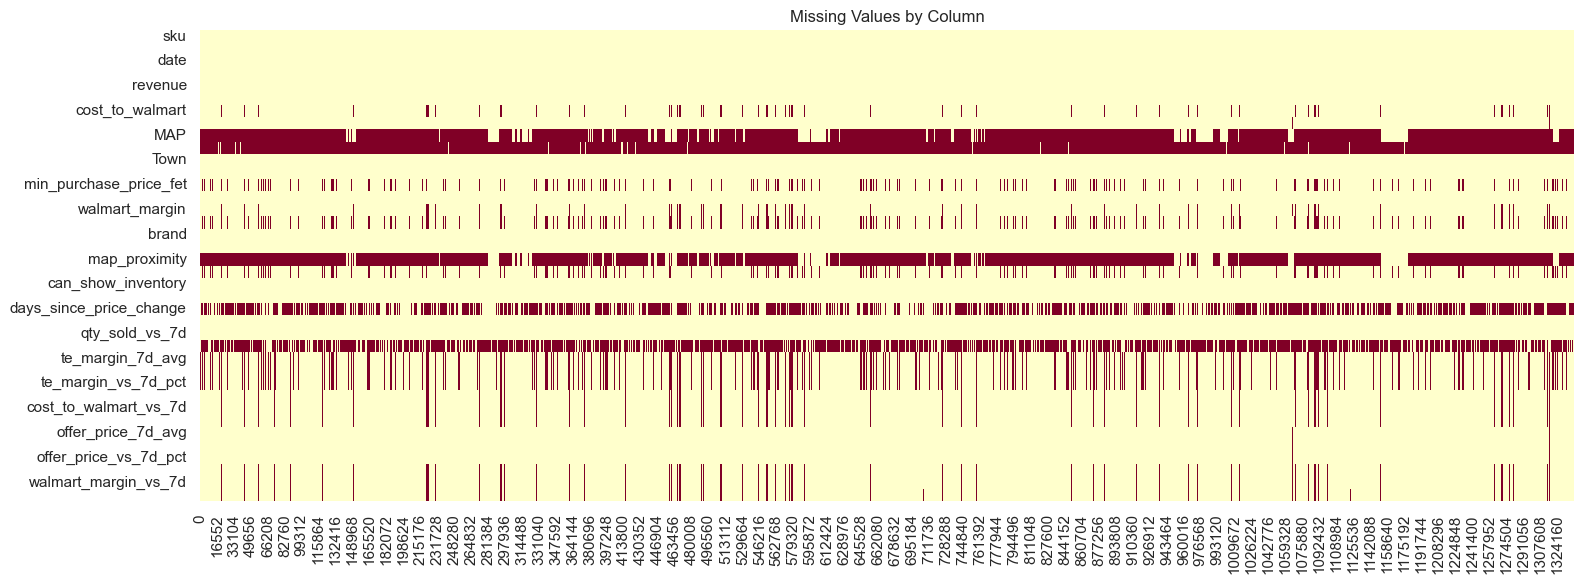

In [25]:
# Missing values heatmap
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(df.isnull().T, cbar=False, cmap="YlOrRd", ax=ax)
ax.set_title("Missing Values by Column")
plt.tight_layout()
plt.show()

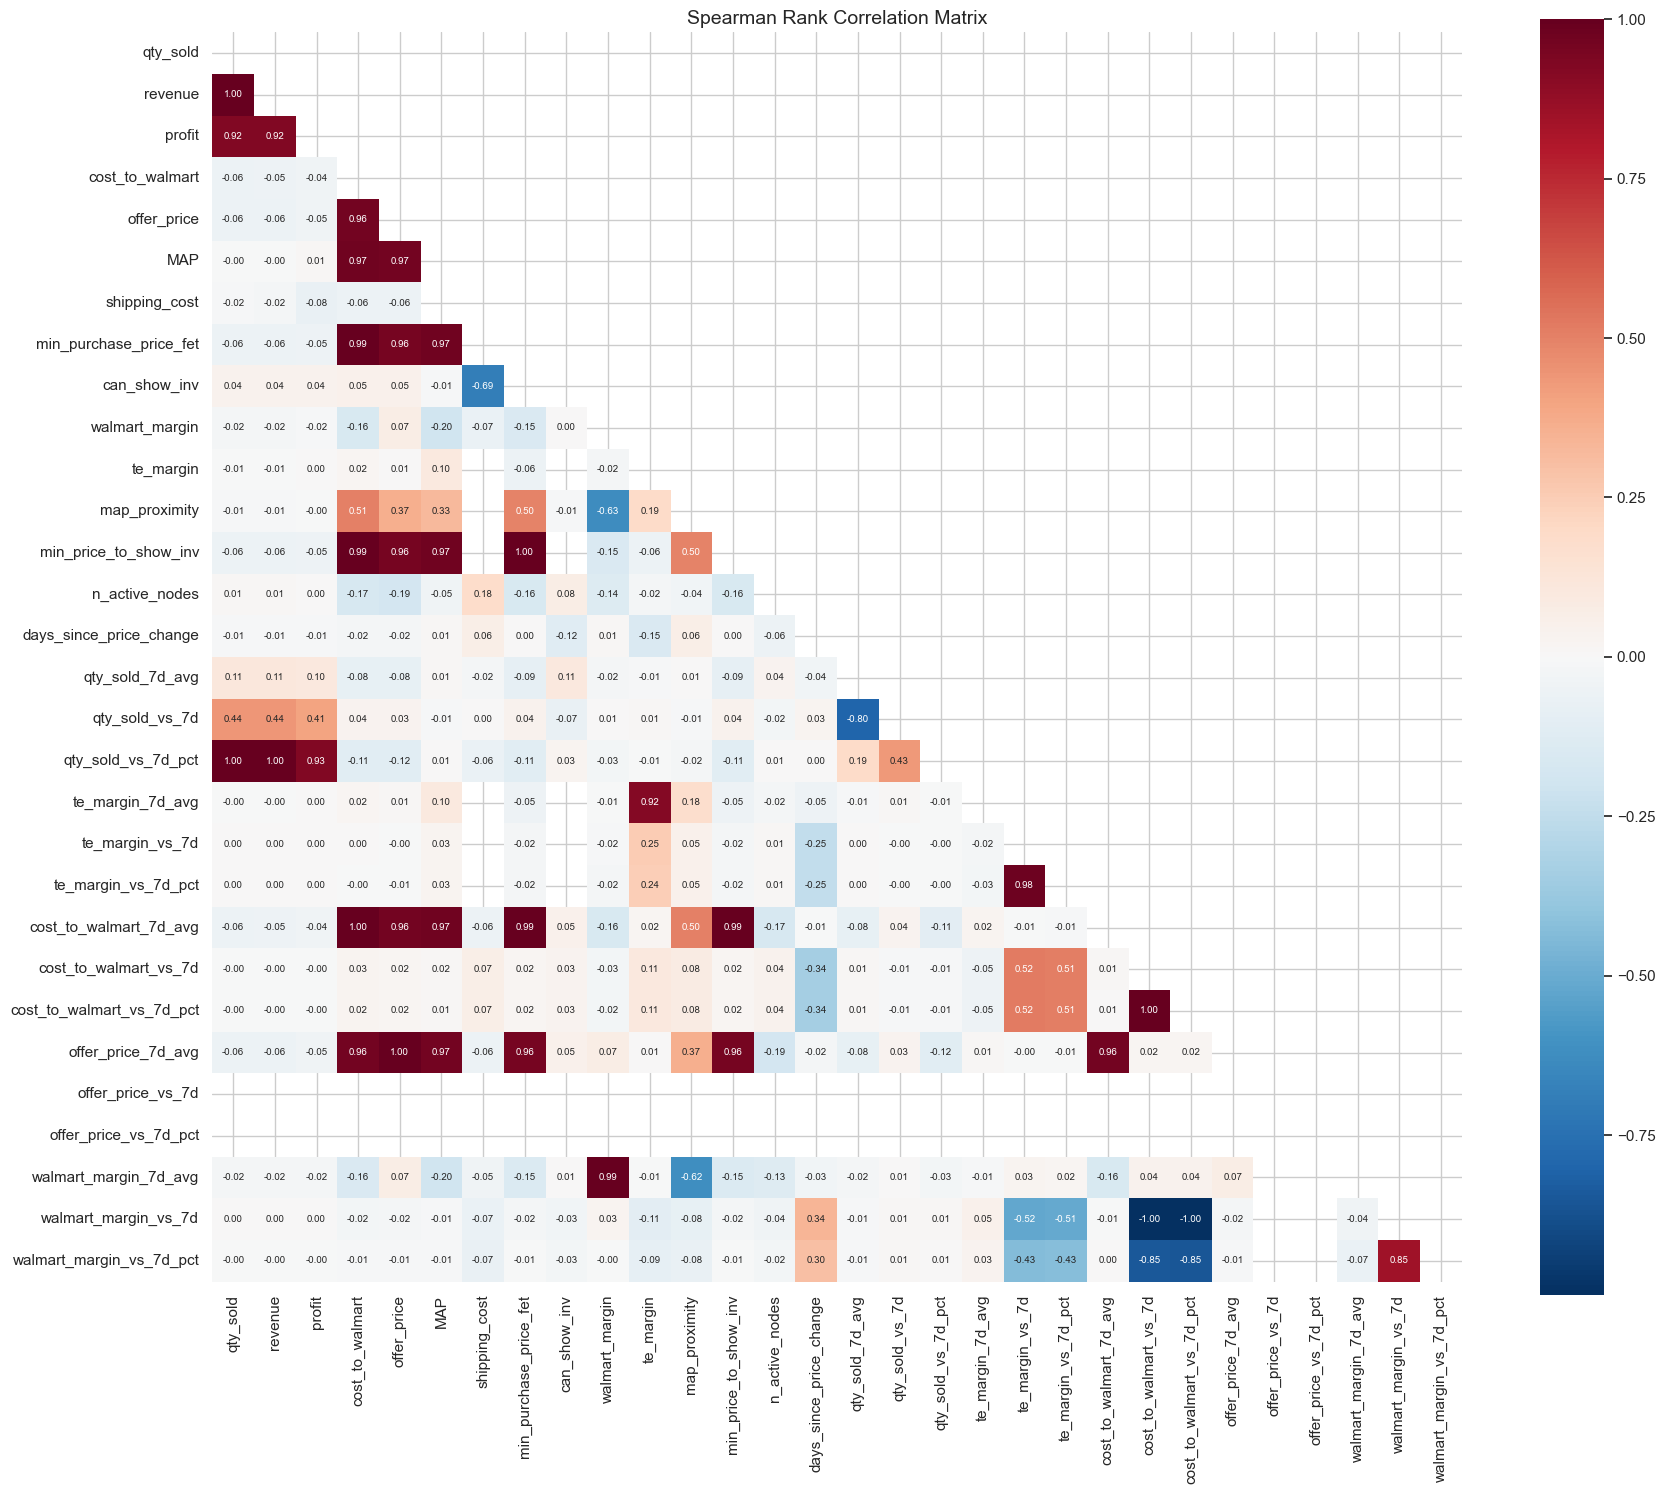

In [26]:
# Spearman correlation matrix (full numeric columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID-like columns
numeric_cols = [c for c in numeric_cols if c not in ["day_of_week"]]

corr_matrix = df[numeric_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, ax=ax,
    annot_kws={"size": 7}, square=True,
)
ax.set_title("Spearman Rank Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

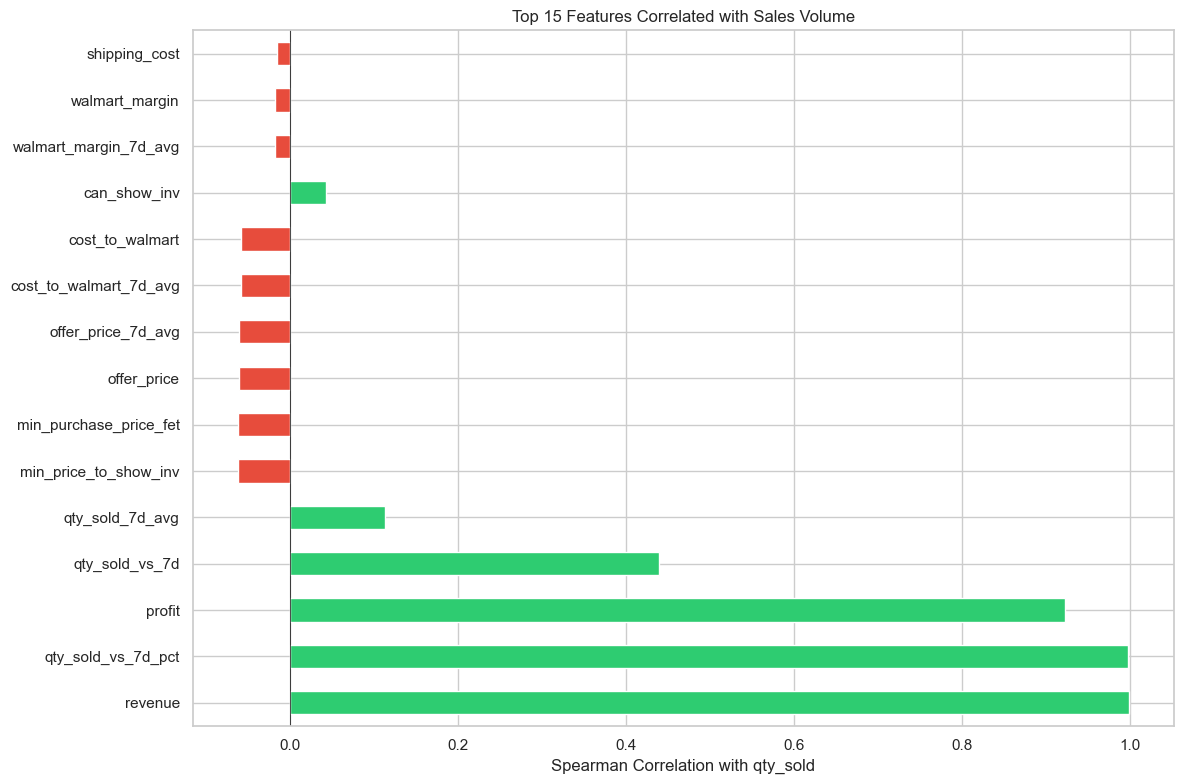


Top 15 correlations with qty_sold:
revenue                   0.999808
qty_sold_vs_7d_pct        0.997945
profit                    0.922970
qty_sold_vs_7d            0.439769
qty_sold_7d_avg           0.112864
min_price_to_show_inv    -0.062284
min_purchase_price_fet   -0.062284
offer_price              -0.060646
offer_price_7d_avg       -0.060646
cost_to_walmart_7d_avg   -0.058347
cost_to_walmart          -0.058300
can_show_inv              0.043023
walmart_margin_7d_avg    -0.017677
walmart_margin           -0.017491
shipping_cost            -0.015588


In [27]:
# Top correlations with qty_sold
target_corrs = (
    corr_matrix["qty_sold"]
    .drop("qty_sold")
    .dropna()
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corrs.head(15)]
target_corrs.head(15).plot.barh(ax=ax, color=colors)
ax.set_xlabel("Spearman Correlation with qty_sold")
ax.set_title("Top 15 Features Correlated with Sales Volume")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop 15 correlations with qty_sold:")
print(target_corrs.head(15).to_string())

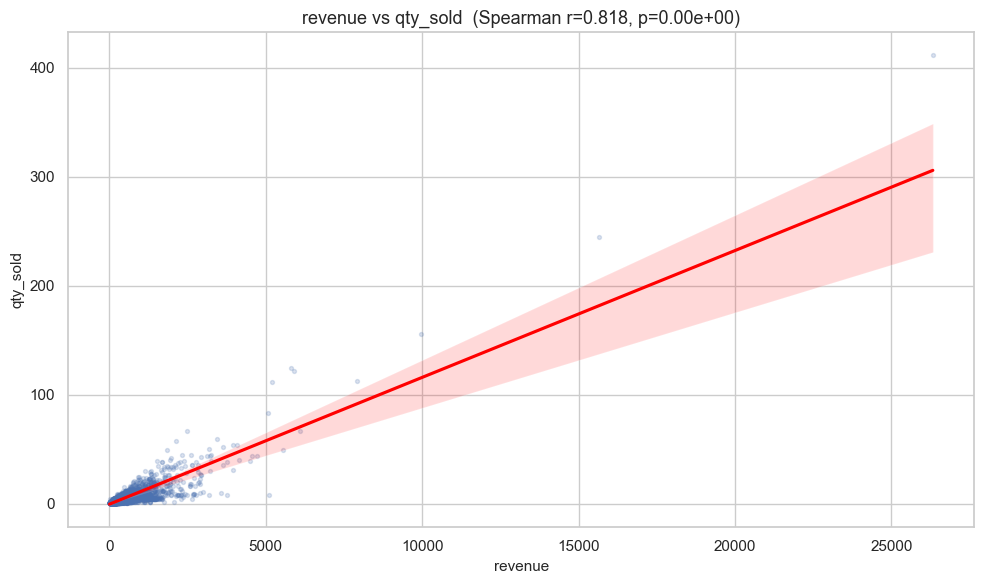

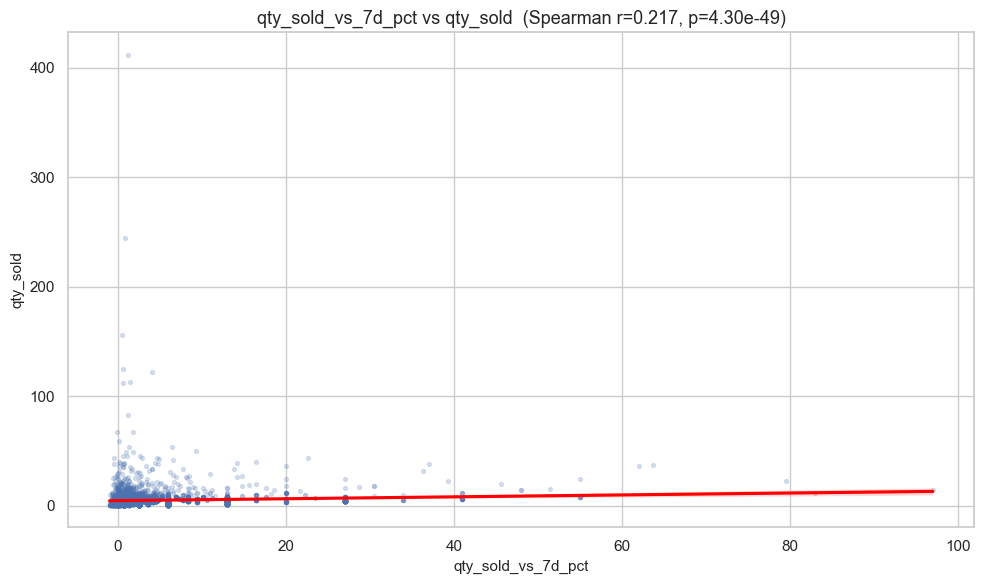

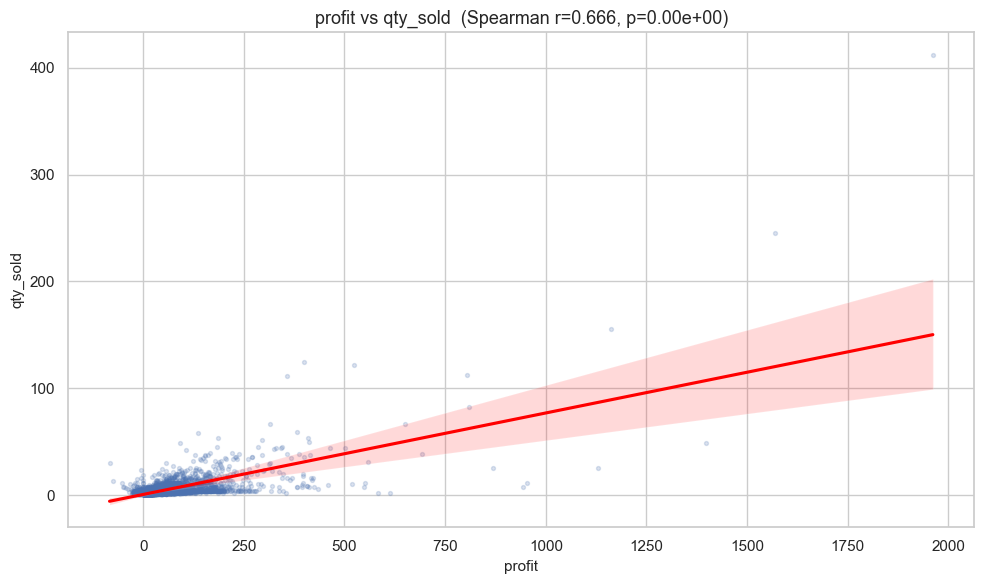

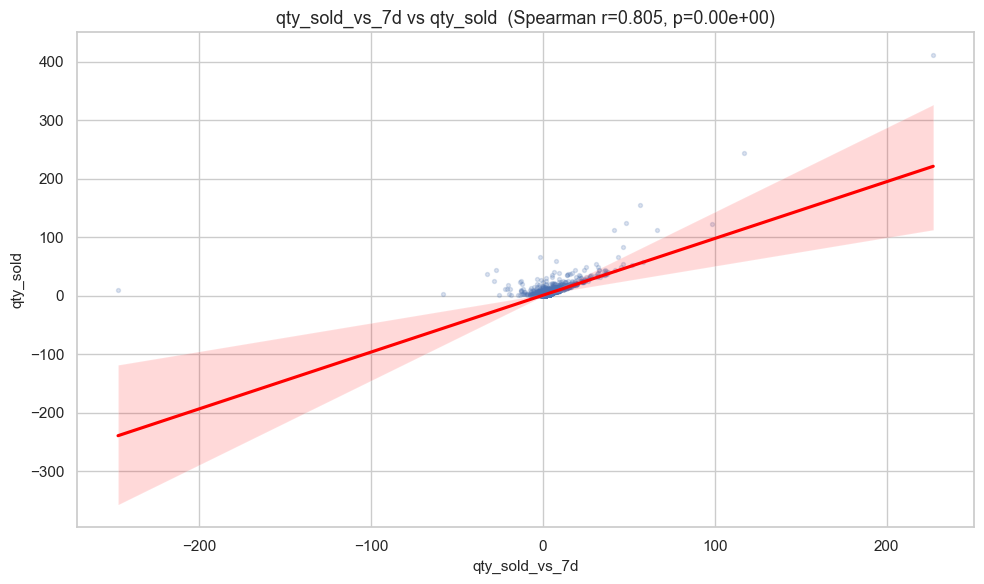

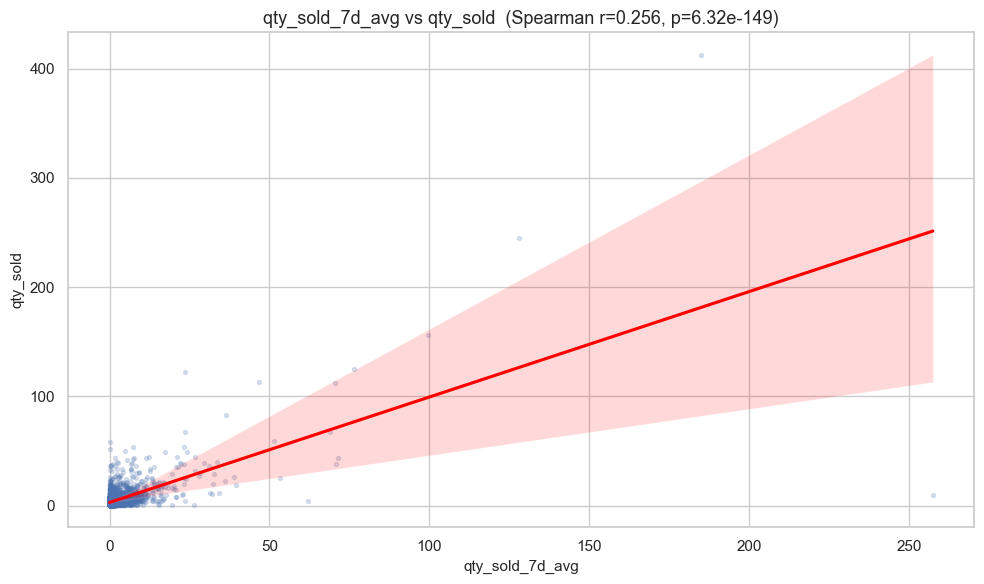

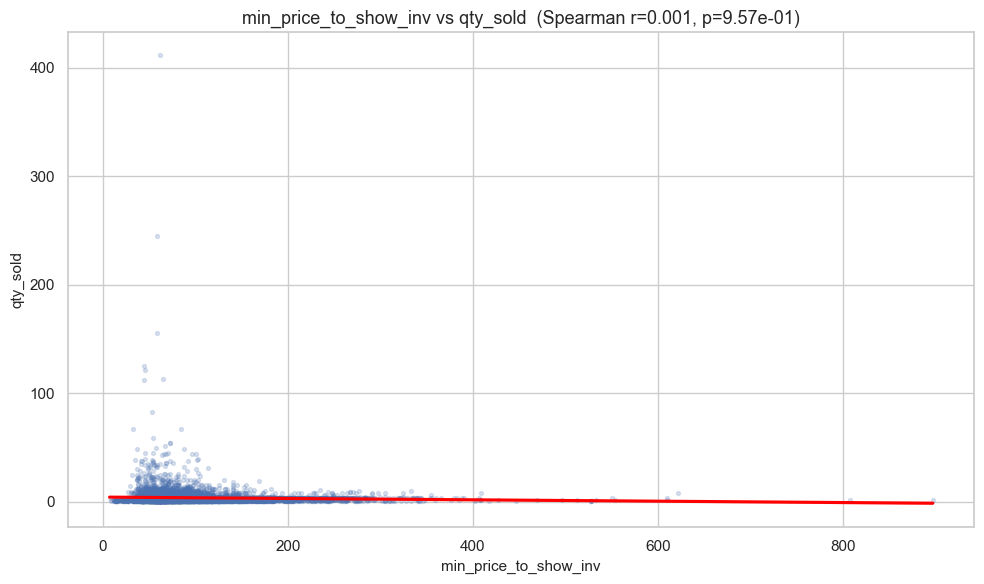

In [28]:
# Scatter plots for top 6 correlated features (individual figures for clarity)
top_features = target_corrs.head(6).index.tolist()

# Sample for performance
df_nonzero = df[df["qty_sold"] > 0]
df_sample = df_nonzero.sample(n=min(10000, len(df_nonzero)), random_state=42)

for col in top_features:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(
        data=df_sample, x=col, y="qty_sold", ax=ax,
        scatter_kws={"alpha": 0.2, "s": 8}, line_kws={"color": "red"},
    )
    valid = df_sample[[col, "qty_sold"]].dropna()
    r, p = stats.spearmanr(valid[col], valid["qty_sold"])
    ax.set_title(f"{col} vs qty_sold  (Spearman r={r:.3f}, p={p:.2e})", fontsize=13)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("qty_sold", fontsize=11)
    plt.tight_layout()
    plt.show()


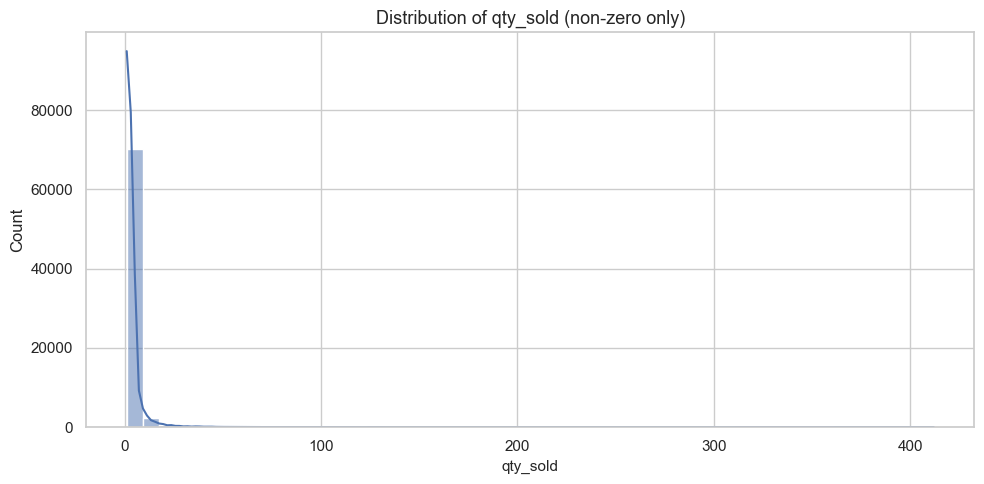

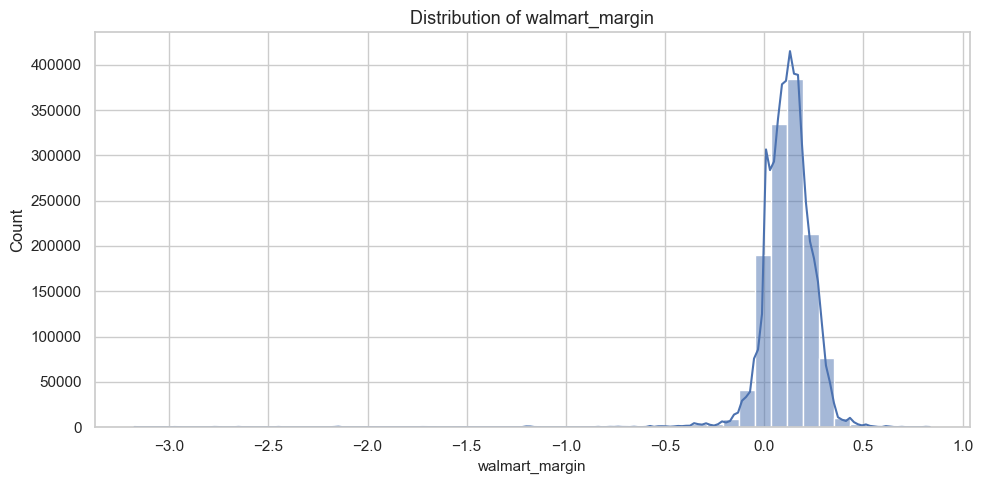

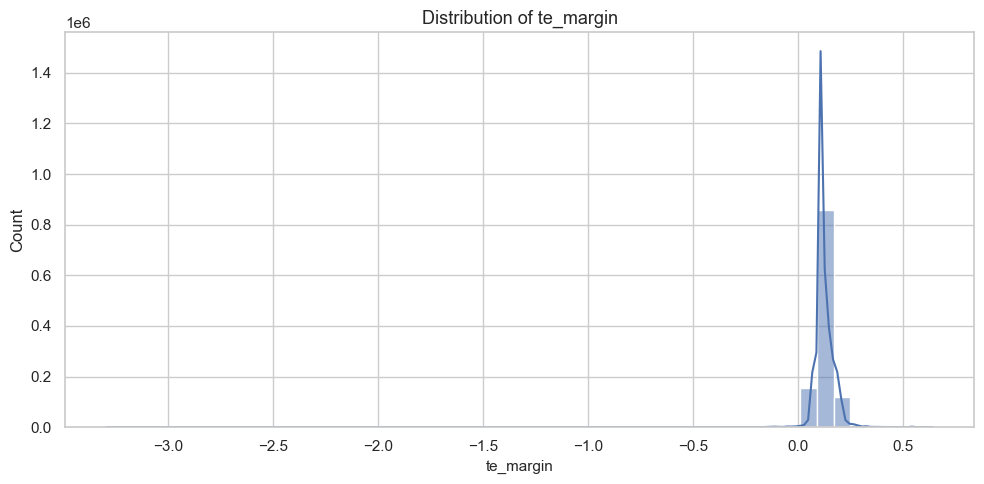

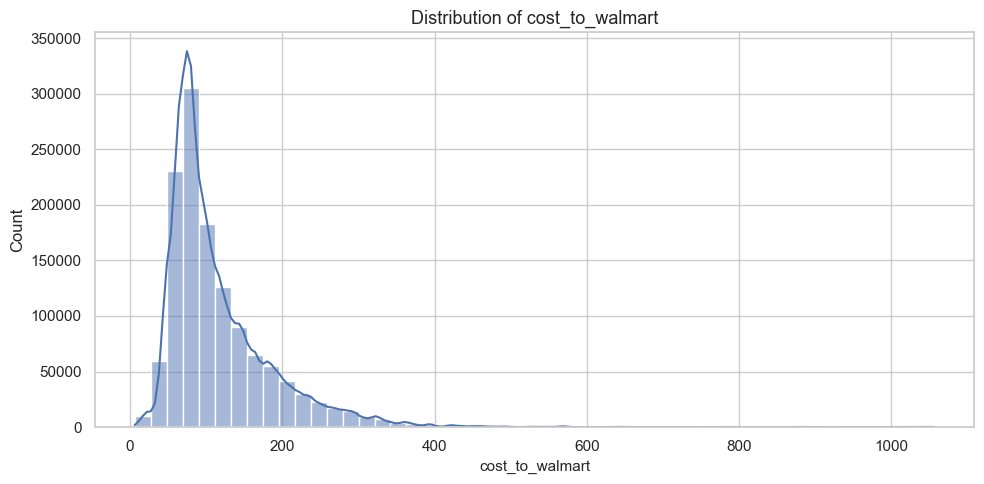

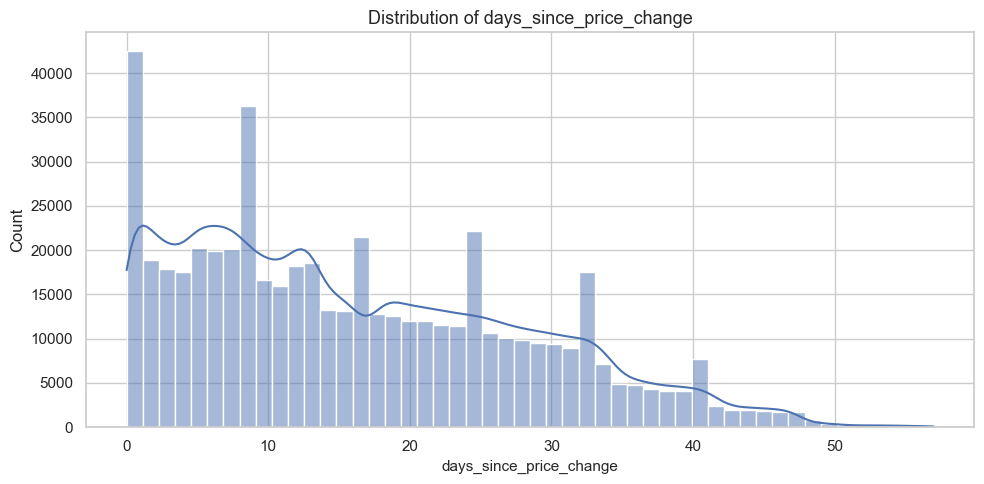

In [29]:
# Distribution plots for key variables (individual figures)
dist_cols = ["qty_sold", "walmart_margin", "te_margin", "cost_to_walmart", "days_since_price_change"]
dist_cols = [c for c in dist_cols if c in df.columns]

for col in dist_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    data = df[col].dropna()
    if col == "qty_sold":
        data = data[data > 0]  # Skip zeros for visibility
        ax.set_title(f"Distribution of {col} (non-zero only)", fontsize=13)
    else:
        ax.set_title(f"Distribution of {col}", fontsize=13)
    sns.histplot(data, ax=ax, bins=50, kde=True)
    ax.set_xlabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()


## 12. Statistical Tests

In [30]:
# Test 1: Price change impact on sales
# Compare qty_sold on days with a recent price change (<=3 days) vs no change (>7 days)
recent_change = df[df["days_since_price_change"] <= 3]["qty_sold"]
no_change = df[df["days_since_price_change"] > 7]["qty_sold"]

if len(recent_change) > 0 and len(no_change) > 0:
    stat, pval = stats.mannwhitneyu(recent_change, no_change, alternative="two-sided")
    print("=== Price Change Impact on Sales ===")
    print(f"Recent change (<=3 days): n={len(recent_change):,}, mean={recent_change.mean():.3f}, median={recent_change.median():.1f}")
    print(f"No recent change (>7 days): n={len(no_change):,}, mean={no_change.mean():.3f}, median={no_change.median():.1f}")
    print(f"Mann-Whitney U stat={stat:.0f}, p-value={pval:.4e}")
    print(f"Significant at 5%: {'Yes' if pval < 0.05 else 'No'}")
else:
    print("Insufficient data for price change analysis")

=== Price Change Impact on Sales ===
Recent change (<=3 days): n=79,271, mean=0.198, median=0.0
No recent change (>7 days): n=374,000, mean=0.182, median=0.0
Mann-Whitney U stat=14911722562, p-value=5.6185e-12
Significant at 5%: Yes


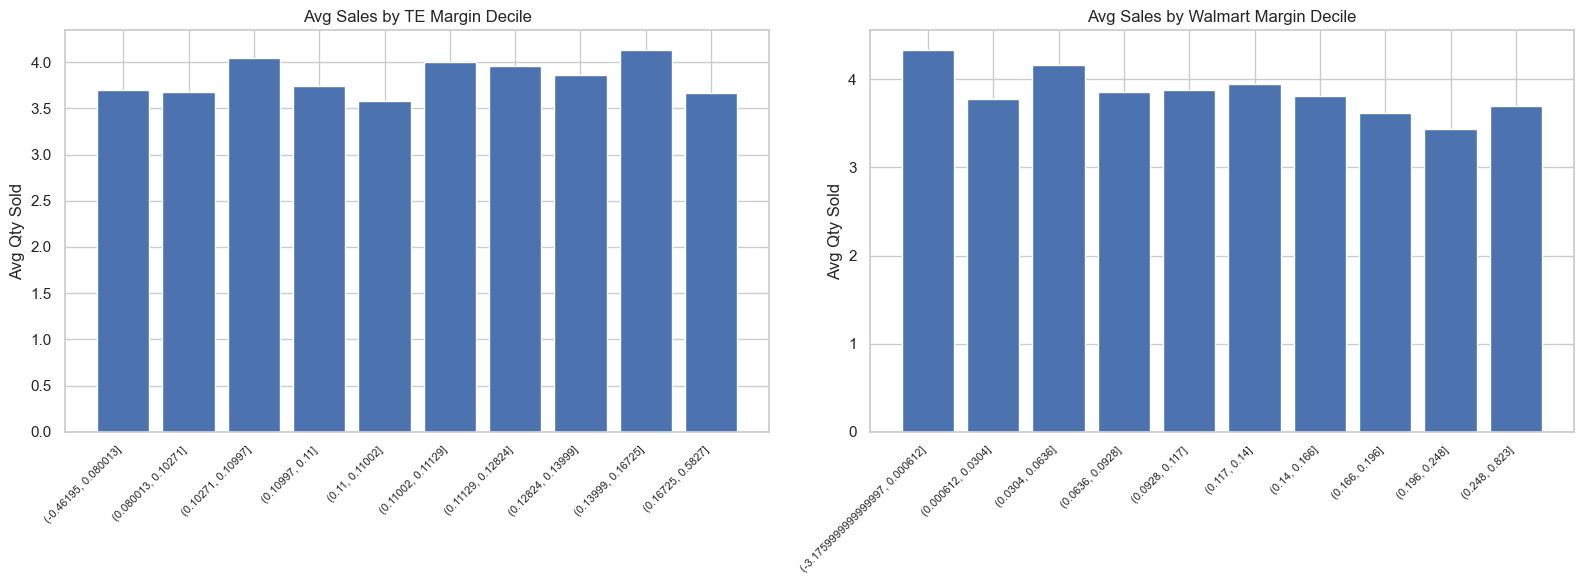

In [31]:
# Test 2: Margin level vs. revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, label in zip(axes, ["te_margin", "walmart_margin"], ["TE Margin", "Walmart Margin"]):
    df_valid = df[df[col].notna() & (df["qty_sold"] > 0)].copy()
    if len(df_valid) > 100:
        df_valid["margin_bin"] = pd.qcut(df_valid[col], 10, duplicates="drop")
        margin_revenue = (
            df_valid.groupby("margin_bin", observed=True)
            .agg(avg_qty=("qty_sold", "mean"), total_qty=("qty_sold", "sum"), count=("qty_sold", "count"))
            .reset_index()
        )
        margin_revenue["margin_bin"] = margin_revenue["margin_bin"].astype(str)
        ax.bar(range(len(margin_revenue)), margin_revenue["avg_qty"])
        ax.set_xticks(range(len(margin_revenue)))
        ax.set_xticklabels(margin_revenue["margin_bin"], rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("Avg Qty Sold")
        ax.set_title(f"Avg Sales by {label} Decile")
    else:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [32]:
# Test 3: Inventory availability vs sales
inv_yes = df[df["can_show_inv"] == 1]["qty_sold"]
inv_no = df[df["can_show_inv"] == 0]["qty_sold"]

print("=== Inventory Availability vs Sales ===")
print(f"With inventory:    n={len(inv_yes):,}, mean={inv_yes.mean():.3f}, median={inv_yes.median():.1f}")
print(f"Without inventory: n={len(inv_no):,}, mean={inv_no.mean():.3f}, median={inv_no.median():.1f}")

if len(inv_yes) > 0 and len(inv_no) > 0:
    stat, pval = stats.mannwhitneyu(inv_yes, inv_no, alternative="two-sided")
    print(f"Mann-Whitney U stat={stat:.0f}, p-value={pval:.4e}")
    print(f"Significant at 5%: {'Yes' if pval < 0.05 else 'No'}")

=== Inventory Availability vs Sales ===
With inventory:    n=1,174,257, mean=0.227, median=0.0
Without inventory: n=166,443, mean=0.120, median=0.0
Mann-Whitney U stat=100628329984, p-value=0.0000e+00
Significant at 5%: Yes


In [33]:
# Test 4: OLS regression
import statsmodels.api as sm

feature_cols = [
    "cost_to_walmart", "offer_price", "walmart_margin", "te_margin",
    "can_show_inv", "shipping_cost", "n_active_nodes", "day_of_week",
    "days_since_price_change",
]
feature_cols = [c for c in feature_cols if c in df.columns]

df_reg = df[feature_cols + ["qty_sold"]].dropna()

if len(df_reg) > 100:
    X = sm.add_constant(df_reg[feature_cols])
    y = df_reg["qty_sold"]
    model = sm.OLS(y, X).fit()
    print(model.summary())
else:
    print("Insufficient data for OLS regression")

                            OLS Regression Results                            
Dep. Variable:               qty_sold   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     10.78
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.30e-13
Time:                        18:17:12   Log-Likelihood:                -16742.
No. Observations:               11660   AIC:                         3.350e+04
Df Residuals:                   11652   BIC:                         3.356e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
cost_to_walmart           

In [34]:
# Also run with log-transformed qty_sold (to handle zero-inflation)
df_reg_log = df_reg[df_reg["qty_sold"] > 0].copy()
if len(df_reg_log) > 100:
    X_log = sm.add_constant(df_reg_log[feature_cols])
    y_log = np.log1p(df_reg_log["qty_sold"])
    model_log = sm.OLS(y_log, X_log).fit()
    print("=== OLS with log(1 + qty_sold), non-zero sales only ===")
    print(model_log.summary())
else:
    print("Insufficient non-zero sales data for log OLS")

=== OLS with log(1 + qty_sold), non-zero sales only ===
                            OLS Regression Results                            
Dep. Variable:               qty_sold   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     4.396
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           8.59e-05
Time:                        18:17:12   Log-Likelihood:                -415.70
No. Observations:                 728   AIC:                             847.4
Df Residuals:                     720   BIC:                             884.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

### Test 5: Price Change Impact on Revenue

Study the correlation between Walmart price changes and revenue directly,
complementing the qty-based analysis in Test 1.

In [35]:
# Price Change Impact on Revenue
if "revenue" in df.columns and "cost_to_walmart_pct_chg" in df.columns:
    df_pc = df[df["cost_to_walmart_pct_chg"].notna() & df["revenue"].notna()].copy()
    df_pc = df_pc[df_pc["cost_to_walmart_pct_chg"] != 0]

    if len(df_pc) > 50:
        from scipy.stats import spearmanr, pearsonr, mannwhitneyu

        r_pearson, p_pearson = pearsonr(df_pc["cost_to_walmart_pct_chg"], df_pc["revenue"])
        r_spearman, p_spearman = spearmanr(df_pc["cost_to_walmart_pct_chg"], df_pc["revenue"])
        print("=== Price Change vs Revenue Correlation ===")
        print(f"Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.4g})")
        print(f"Spearman r = {r_spearman:.4f}  (p = {p_spearman:.4g})")

        # Bucketed analysis
        df_pc["price_change_bucket"] = pd.cut(
            df_pc["cost_to_walmart_pct_chg"],
            bins=[-np.inf, -0.05, -0.01, 0.01, 0.05, np.inf],
            labels=["Large decrease (<-5%)", "Small decrease (-5% to -1%)",
                    "Minimal (-1% to 1%)", "Small increase (1% to 5%)",
                    "Large increase (>5%)"],
        )
        bucket_stats = (
            df_pc.groupby("price_change_bucket", observed=True)
            .agg(n=("revenue", "size"), mean_revenue=("revenue", "mean"),
                 median_revenue=("revenue", "median"), total_revenue=("revenue", "sum"),
                 mean_qty=("qty_sold", "mean"))
            .round(2)
        )
        print()
        print("=== Revenue by Price Change Bucket ===")
        print(bucket_stats.to_string())

        # Visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].scatter(df_pc["cost_to_walmart_pct_chg"] * 100, df_pc["revenue"], alpha=0.15, s=8)
        axes[0].set_xlabel("Price Change (%)")
        axes[0].set_ylabel("Revenue ($)")
        axes[0].set_title(f"Price Change vs Revenue (r={r_spearman:.3f})")
        axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

        bucket_stats["mean_revenue"].plot(kind="bar", ax=axes[1], color="steelblue", alpha=0.8)
        axes[1].set_ylabel("Mean Revenue ($)")
        axes[1].set_title("Mean Revenue by Price Change Bucket")
        axes[1].tick_params(axis="x", rotation=30)

        bucket_stats["mean_qty"].plot(kind="bar", ax=axes[2], color="darkorange", alpha=0.8)
        axes[2].set_ylabel("Mean Qty Sold")
        axes[2].set_title("Mean Qty by Price Change Bucket")
        axes[2].tick_params(axis="x", rotation=30)
        plt.tight_layout()
        plt.show()

        # Pre/post revenue around price change events
        print()
        print("=== Pre/Post Revenue Around Price Change Events ===")
        df_events = df[df["days_since_price_change"].notna()].copy()
        pre_rev = df_events[df_events["days_since_price_change"].between(4, 7)]["revenue"]
        post_rev = df_events[df_events["days_since_price_change"].between(0, 3)]["revenue"]
        print(f"Pre-change (4-7 days before):  n={len(pre_rev):,}, mean=${pre_rev.mean():.2f}")
        print(f"Post-change (0-3 days after):  n={len(post_rev):,}, mean=${post_rev.mean():.2f}")
        if len(pre_rev) > 30 and len(post_rev) > 30:
            stat, pval = mannwhitneyu(post_rev, pre_rev, alternative="two-sided")
            print(f"Mann-Whitney U test: stat={stat:.1f}, p={pval:.4g}")
            pct_change = (post_rev.mean() - pre_rev.mean()) / pre_rev.mean() * 100
            print(f"Revenue change: {pct_change:+.1f}%")
    else:
        print(f"Insufficient price-change rows ({len(df_pc)}) for revenue correlation analysis")
else:
    missing = [c for c in ["revenue", "cost_to_walmart_pct_chg"] if c not in df.columns]
    print(f"Columns missing for price-revenue analysis: {missing}")


Columns missing for price-revenue analysis: ['cost_to_walmart_pct_chg']


## 13. Geographic & Brand Analysis

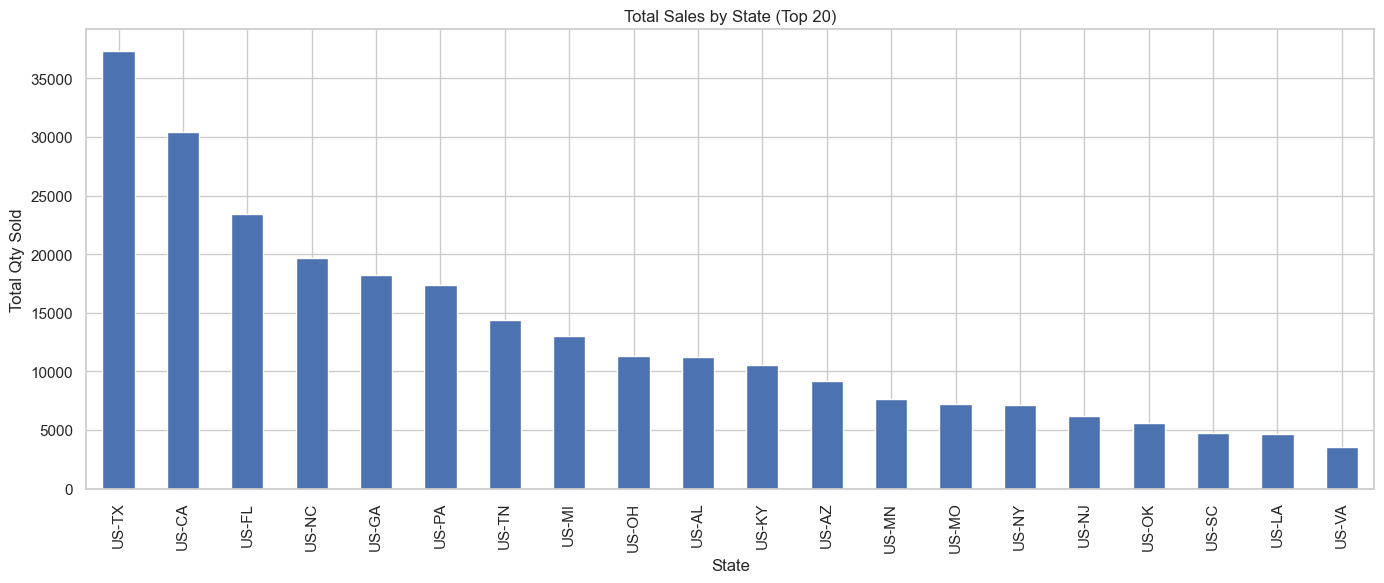

,total_qty,avg_wm_margin,avg_te_margin,n_nodes
State,,,,
US-TX,37313.0,0.123338,0.118428,111
US-CA,30438.0,0.114005,0.119025,110
US-FL,23444.0,0.118519,0.120006,90
US-NC,19680.0,0.098017,0.122146,59
US-GA,18222.0,0.113401,0.115277,52
US-PA,17390.0,0.138915,0.120910,37
US-TN,14403.0,0.131257,0.119895,44
US-MI,13040.0,0.142032,0.128043,34
US-OH,11309.0,0.126580,0.120061,46


In [36]:
# Sales by state
state_sales = (
    df.groupby("State")
    .agg(
        total_qty=("qty_sold", "sum"),
        avg_wm_margin=("walmart_margin", "mean"),
        avg_te_margin=("te_margin", "mean"),
        n_nodes=("node", "nunique"),
    )
    .sort_values("total_qty", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(14, 6))
state_sales["total_qty"].plot.bar(ax=ax)
ax.set_title("Total Sales by State (Top 20)")
ax.set_ylabel("Total Qty Sold")
ax.set_xlabel("State")
plt.tight_layout()
plt.show()

state_sales

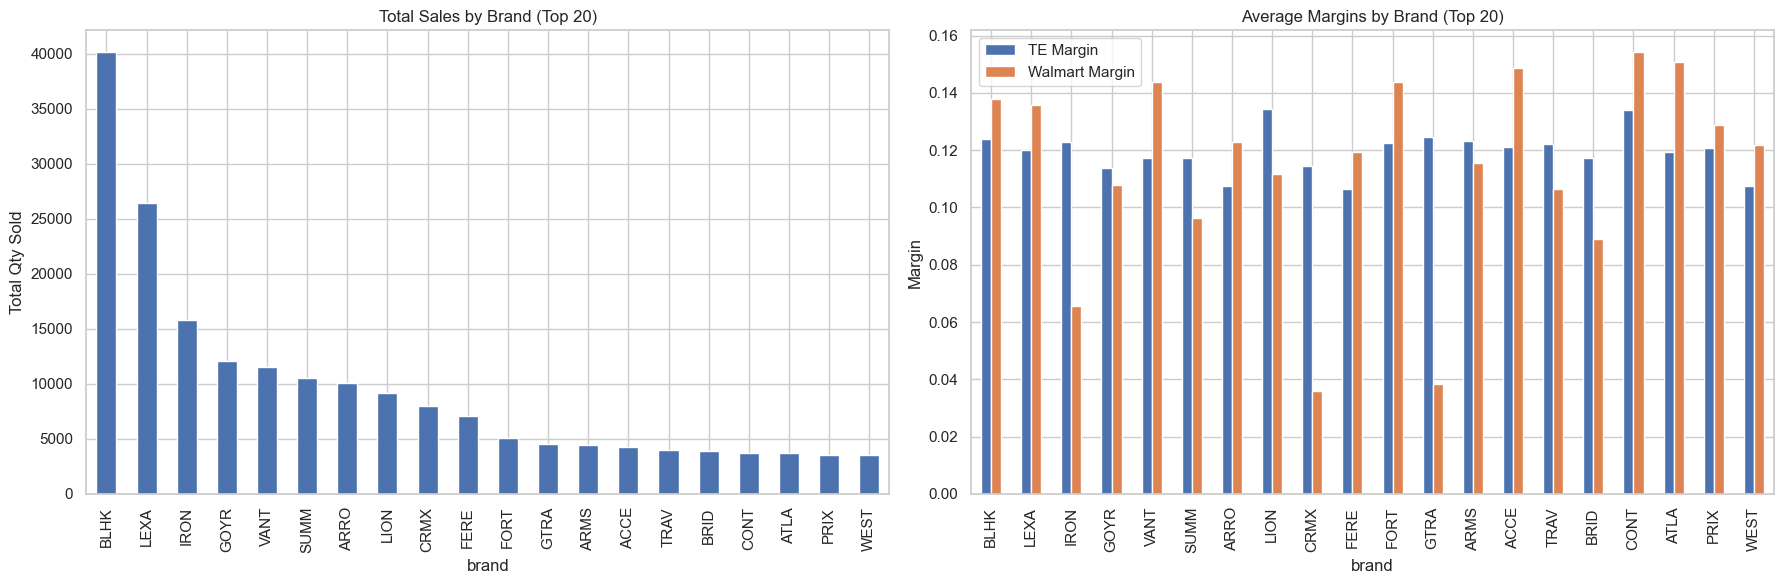

,total_qty,total_revenue,avg_te_margin,avg_wm_margin,n_skus,n_nodes
brand,,,,,,
BLHK,40101.0,3495451.94,0.123815,0.137856,252,61
LEXA,26381.0,2227328.46,0.120099,0.135855,279,97
IRON,15837.0,1228252.96,0.123020,0.065661,160,353
GOYR,12102.0,2027253.95,0.113795,0.107784,294,474
VANT,11533.0,802247.68,0.117107,0.143765,61,310
SUMM,10548.0,959263.64,0.117307,0.096410,158,25
ARRO,10054.0,769239.70,0.107552,0.122754,191,66
LION,9132.0,637846.37,0.134496,0.111790,152,73
CRMX,7971.0,543194.55,0.114575,0.035955,49,17


In [37]:
# Brand-level analysis
brand_analysis = (
    df.groupby("brand")
    .agg(
        total_qty=("qty_sold", "sum"),
        total_revenue=("revenue", "sum"),
        avg_te_margin=("te_margin", "mean"),
        avg_wm_margin=("walmart_margin", "mean"),
        n_skus=("sku", "nunique"),
        n_nodes=("node", "nunique"),
    )
    .sort_values("total_qty", ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

brand_analysis["total_qty"].plot.bar(ax=axes[0])
axes[0].set_title("Total Sales by Brand (Top 20)")
axes[0].set_ylabel("Total Qty Sold")

brand_analysis[["avg_te_margin", "avg_wm_margin"]].plot.bar(ax=axes[1])
axes[1].set_title("Average Margins by Brand (Top 20)")
axes[1].set_ylabel("Margin")
axes[1].legend(["TE Margin", "Walmart Margin"])

plt.tight_layout()
plt.show()

brand_analysis

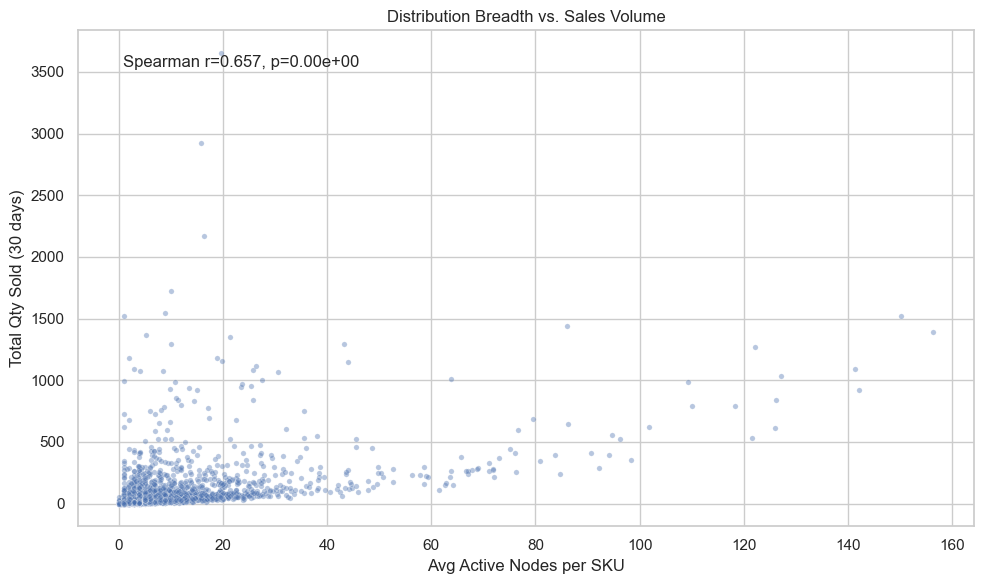

In [38]:
# Node distribution breadth vs sales
breadth = (
    df.groupby("sku")
    .agg(
        avg_active_nodes=("n_active_nodes", "mean"),
        total_qty=("qty_sold", "sum"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=breadth, x="avg_active_nodes", y="total_qty", alpha=0.4, s=15, ax=ax)
ax.set_xlabel("Avg Active Nodes per SKU")
ax.set_ylabel("Total Qty Sold (30 days)")
ax.set_title("Distribution Breadth vs. Sales Volume")

r, p = stats.spearmanr(breadth["avg_active_nodes"], breadth["total_qty"])
ax.text(0.05, 0.95, f"Spearman r={r:.3f}, p={p:.2e}", transform=ax.transAxes, va="top")

plt.tight_layout()
plt.show()

## 14. Summary & Cleanup

### Key Findings

*(Fill in after running the analysis)*

1. **Price change impact:** ...
2. **Top correlated features:** ...
3. **Margin sweet spots:** ...
4. **Inventory availability effect:** ...
5. **Geographic patterns:** ...
6. **Brand insights:** ...
7. **Distribution breadth:** ...

## 15. Extended Feature Engineering

Add tire size (from `warehouse.d_tireproduct`) and MAP tire flag to the dataset for segmented analysis.

In [39]:
# --- Load tire size from warehouse.d_tireproduct ---
import re as _re

try:
    df_tireproduct = loader.dw.run_query(
        'SELECT code AS "Product Code", full_size FROM warehouse.d_tireproduct',
        new_credentials=False,
    )
    df_tireproduct = df_tireproduct.drop_duplicates(subset=["Product Code"])

    # full_size is a numeric encoding, e.g. "2156017" = 215/60R17
    # The last 2 digits represent the rim diameter in inches
    df_tireproduct["tire_diameter"] = (
        df_tireproduct["full_size"]
        .astype(str)
        .str.extract(r"(\d{2})$")[0]
        .astype(float)
    )
    # Keep only reasonable rim diameters (13-30 inches)
    df_tireproduct.loc[
        ~df_tireproduct["tire_diameter"].between(13, 30), "tire_diameter"
    ] = np.nan
    df_tireproduct["tire_size"] = df_tireproduct["full_size"]

    df = df.merge(
        df_tireproduct[["Product Code", "tire_size", "tire_diameter"]],
        left_on="sku", right_on="Product Code", how="left",
    )
    # Clean up duplicate columns from merge
    if "Product Code_y" in df.columns:
        df.drop(columns=[c for c in df.columns if c.endswith("_y")], inplace=True)
        df.rename(columns={c: c.replace("_x", "") for c in df.columns if c.endswith("_x")}, inplace=True)
    elif "Product Code" in df.columns and "Product Code" != "sku":
        df.drop(columns=["Product Code"], inplace=True, errors="ignore")

    print(f"Tire size coverage: {df['tire_size'].notna().mean():.1%}")
    print(f"Tire diameter coverage: {df['tire_diameter'].notna().mean():.1%}")
    print(f"Tire diameter distribution:\n{df['tire_diameter'].value_counts().head(15)}")
except Exception as e:
    print(f"Tire size load failed: {e}")
    df["tire_size"] = np.nan
    df["tire_diameter"] = np.nan

Tire size coverage: 100.0%
Tire diameter coverage: 97.6%
Tire diameter distribution:
tire_diameter
17.0    287790
18.0    287340
16.0    192450
20.0    189300
15.0    118710
19.0    118230
22.0     37410
14.0     33030
21.0     12990
25.0     12840
24.0      7140
26.0      5640
13.0      4980
28.0       570
23.0       270
Name: count, dtype: int64


In [40]:
# MAP tire flag: True if the SKU has a MAP price (minimum allowed price)
df["is_MAP_tire"] = df["MAP"].notna()
print(f"MAP tire distribution:\n{df['is_MAP_tire'].value_counts()}")
print(f"MAP tire %: {df['is_MAP_tire'].mean():.1%}")

MAP tire distribution:
is_MAP_tire
False    1150050
True      190650
Name: count, dtype: int64
MAP tire %: 14.2%


## 16. Price Elasticity by State & Brand-State

Estimate price elasticity at the state and brand-state level using log-log OLS:
`log(qty+1) ~ log(offer_price)`

Elasticity < 0 means higher price → lower sales (expected). More negative = more price-sensitive.

States with valid elasticity estimates: 42


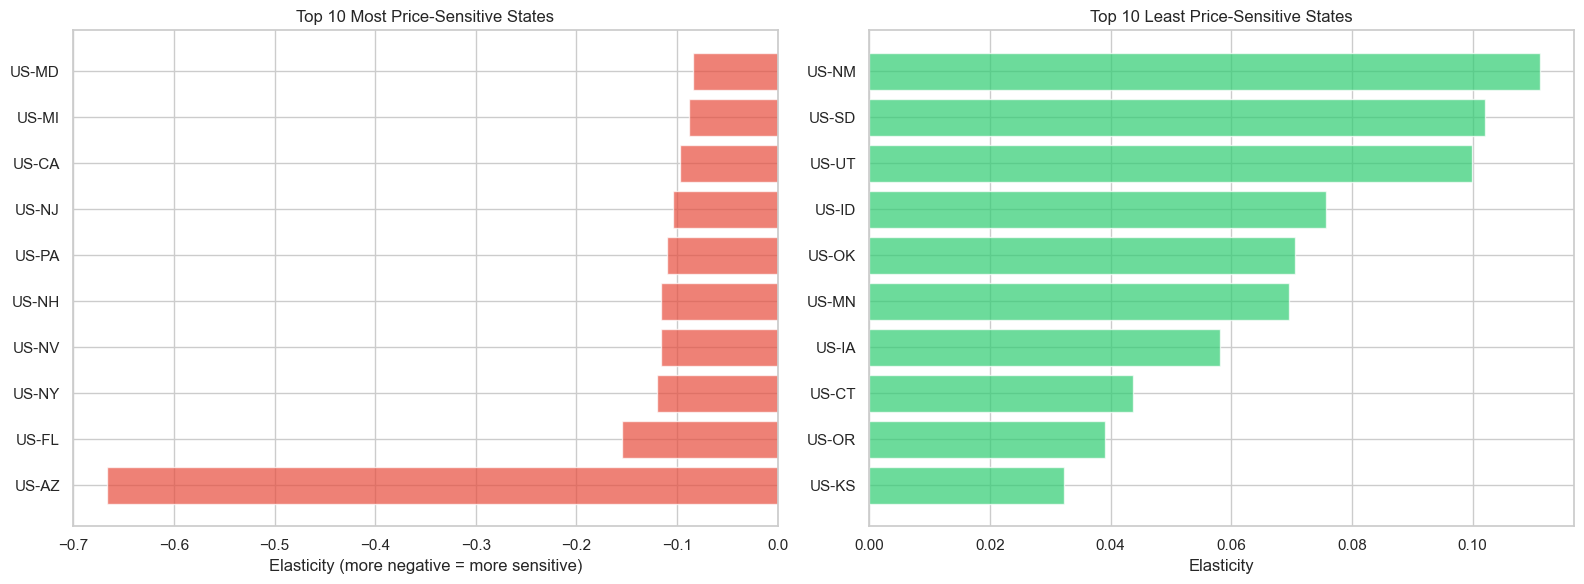

,State,elasticity,SE,p_value,n_obs,ci_lower,ci_upper
2,US-AZ,-0.6669,0.0407,0.0000,1185,-0.7468,-0.5871
6,US-FL,-0.1544,0.0161,0.0000,5537,-0.1858,-0.1229
28,US-NY,-0.1199,0.0250,0.0000,1898,-0.1690,-0.0708
27,US-NV,-0.1159,0.0630,0.0677,167,-0.2393,0.0076
24,US-NH,-0.1157,0.1008,0.2545,79,-0.3133,0.0819
32,US-PA,-0.1103,0.0267,0.0000,3110,-0.1626,-0.0579
25,US-NJ,-0.1036,0.0289,0.0003,1687,-0.1602,-0.0470
3,US-CA,-0.0968,0.0136,0.0000,7342,-0.1235,-0.0701
18,US-MI,-0.0884,0.0220,0.0001,3319,-0.1315,-0.0453
16,US-MD,-0.0842,0.0381,0.0276,571,-0.1589,-0.0095


In [41]:
# --- Elasticity by State ---
import statsmodels.api as sm

df_elast = df[(df["qty_sold"] > 0) & (df["offer_price"] > 0)].copy()

MIN_OBS_STATE = 50
state_elasticity = []

for state, grp in df_elast.groupby("State"):
    if pd.isna(state) or len(grp) < MIN_OBS_STATE:
        continue
    try:
        X = sm.add_constant(np.log(grp["offer_price"]))
        y = np.log1p(grp["qty_sold"])
        model = sm.OLS(y, X).fit()
        coef = model.params.iloc[-1]
        se = model.bse.iloc[-1]
        pval = model.pvalues.iloc[-1]
        state_elasticity.append({
            "State": state, "elasticity": coef, "SE": se, "p_value": pval,
            "n_obs": len(grp), "ci_lower": coef - 1.96 * se, "ci_upper": coef + 1.96 * se,
        })
    except Exception:
        continue

df_state_elast = pd.DataFrame(state_elasticity).sort_values("elasticity")
print(f"States with valid elasticity estimates: {len(df_state_elast)}")

# Bar chart: top/bottom 10
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_elastic = df_state_elast.head(10)
axes[0].barh(top_elastic["State"], top_elastic["elasticity"], color="#e74c3c", alpha=0.7)
axes[0].set_title("Top 10 Most Price-Sensitive States")
axes[0].set_xlabel("Elasticity (more negative = more sensitive)")

top_inelastic = df_state_elast.tail(10)
axes[1].barh(top_inelastic["State"], top_inelastic["elasticity"], color="#2ecc71", alpha=0.7)
axes[1].set_title("Top 10 Least Price-Sensitive States")
axes[1].set_xlabel("Elasticity")

plt.tight_layout()
plt.show()

display(df_state_elast.style.format({"elasticity": "{:.4f}", "SE": "{:.4f}", "p_value": "{:.4f}",
                                      "ci_lower": "{:.4f}", "ci_upper": "{:.4f}"}))


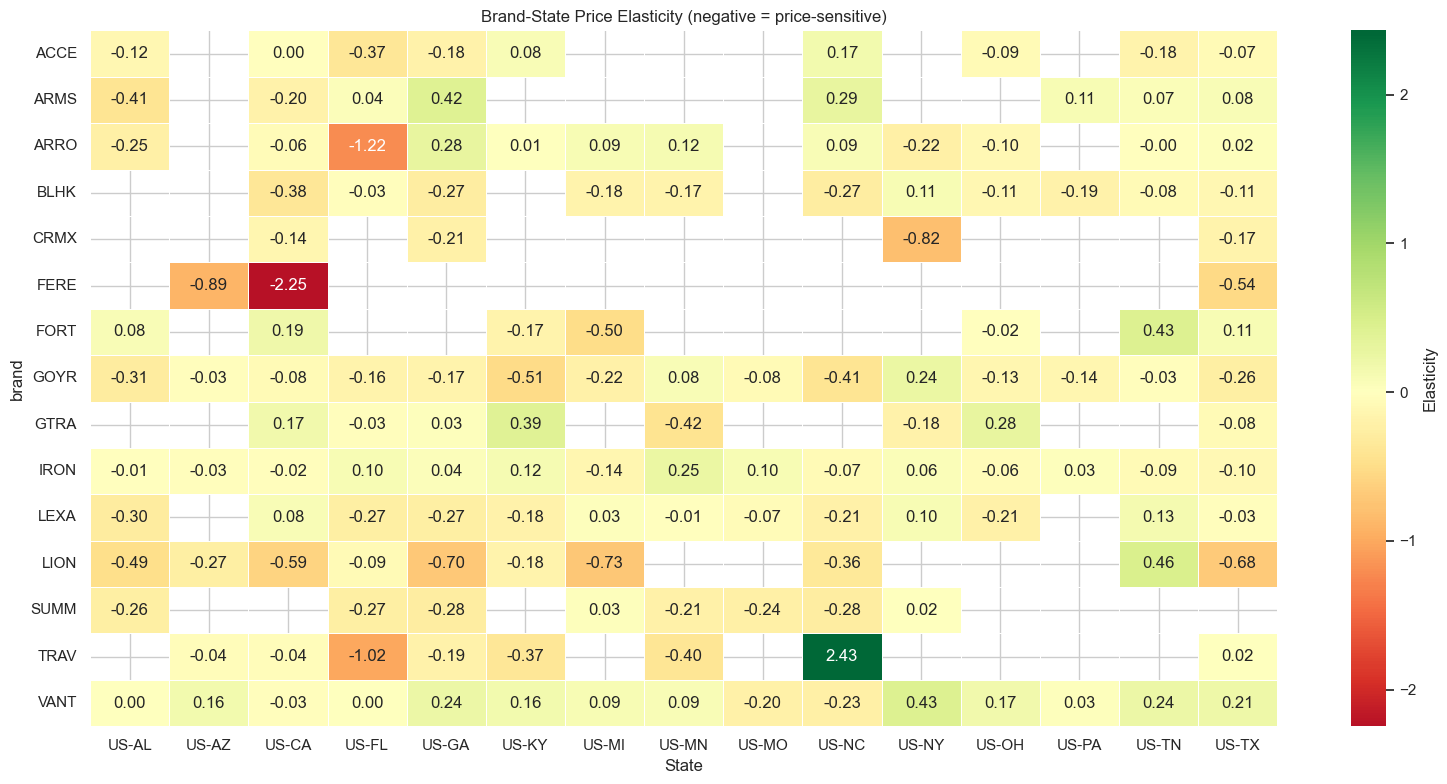


=== TOP 5 MOST PRICE-SENSITIVE Brand-State Segments ===
  FERE in US-CA: elasticity = -2.247**  (n=77)
  ARRO in US-FL: elasticity = -1.218***  (n=256)
  TRAV in US-FL: elasticity = -1.021***  (n=58)
  FERE in US-AZ: elasticity = -0.894*  (n=251)
  CRMX in US-NY: elasticity = -0.819*  (n=136)

=== TOP 5 LEAST PRICE-SENSITIVE Brand-State Segments ===
  TRAV in US-NC: elasticity = 2.432*  (n=36)
  LION in US-TN: elasticity = 0.460*  (n=120)
  VANT in US-NY: elasticity = 0.432*  (n=174)
  FORT in US-TN: elasticity = 0.425  (n=40)
  ARMS in US-GA: elasticity = 0.415  (n=37)


In [42]:
# --- Brand-State Cross-Tabulation ---
MIN_OBS_BRAND_STATE = 30

top_brands_elast = df_elast.groupby("brand")["qty_sold"].sum().nlargest(15).index.tolist()
top_states_elast = df_elast.groupby("State")["qty_sold"].sum().nlargest(15).index.tolist()

brand_state_results = []
for brand in top_brands_elast:
    for state in top_states_elast:
        subset = df_elast[(df_elast["brand"] == brand) & (df_elast["State"] == state)]
        if len(subset) < MIN_OBS_BRAND_STATE:
            brand_state_results.append({"brand": brand, "State": state, "elasticity": np.nan,
                                         "n": len(subset), "p_value": np.nan})
            continue
        try:
            X = sm.add_constant(np.log(subset["offer_price"]))
            y = np.log1p(subset["qty_sold"])
            model = sm.OLS(y, X).fit()
            brand_state_results.append({
                "brand": brand, "State": state,
                "elasticity": model.params.iloc[-1],
                "n": len(subset), "p_value": model.pvalues.iloc[-1],
            })
        except Exception:
            brand_state_results.append({"brand": brand, "State": state, "elasticity": np.nan,
                                         "n": len(subset), "p_value": np.nan})

df_bs_elast = pd.DataFrame(brand_state_results)

# Pivot heatmap
pivot = df_bs_elast.pivot(index="brand", columns="State", values="elasticity")
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, cmap="RdYlGn", center=0, annot=True, fmt=".2f",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Elasticity"})
ax.set_title("Brand-State Price Elasticity (negative = price-sensitive)")
plt.tight_layout()
plt.show()

# Narrative: top 5 most and least elastic segments
df_bs_valid = df_bs_elast.dropna(subset=["elasticity"])
most_elastic = df_bs_valid.nsmallest(5, "elasticity")
least_elastic = df_bs_valid.nlargest(5, "elasticity")

print("\n=== TOP 5 MOST PRICE-SENSITIVE Brand-State Segments ===")
for _, r in most_elastic.iterrows():
    sig = "***" if r["p_value"] < 0.001 else "**" if r["p_value"] < 0.01 else "*" if r["p_value"] < 0.05 else ""
    print(f"  {r['brand']} in {r['State']}: elasticity = {r['elasticity']:.3f}{sig}  (n={r['n']:,})")

print("\n=== TOP 5 LEAST PRICE-SENSITIVE Brand-State Segments ===")
for _, r in least_elastic.iterrows():
    sig = "***" if r["p_value"] < 0.001 else "**" if r["p_value"] < 0.01 else "*" if r["p_value"] < 0.05 else ""
    print(f"  {r['brand']} in {r['State']}: elasticity = {r['elasticity']:.3f}{sig}  (n={r['n']:,})")


In [43]:
# --- City-Level Drill-Down ---
MIN_OBS_CITY = 30
MIN_BRAND_STATE_FOR_CITY = 200

city_results = []
for brand in top_brands_elast:
    for state in top_states_elast:
        bs_subset = df_elast[(df_elast["brand"] == brand) & (df_elast["State"] == state)]
        if len(bs_subset) < MIN_BRAND_STATE_FOR_CITY:
            continue
        for city, city_grp in bs_subset.groupby("Town"):
            if pd.isna(city) or len(city_grp) < MIN_OBS_CITY:
                continue
            try:
                X = sm.add_constant(np.log(city_grp["offer_price"]))
                y = np.log1p(city_grp["qty_sold"])
                model = sm.OLS(y, X).fit()
                city_results.append({
                    "brand": brand, "State": state, "Town": city,
                    "elasticity": model.params.iloc[-1],
                    "n": len(city_grp), "p_value": model.pvalues.iloc[-1],
                })
            except Exception:
                continue

if city_results:
    df_city_elast = pd.DataFrame(city_results)
    # Show only brand-state combos with meaningful city-level variation
    city_var = df_city_elast.groupby(["brand", "State"])["elasticity"].std().reset_index()
    city_var = city_var.rename(columns={"elasticity": "elasticity_std"})
    notable = city_var[city_var["elasticity_std"] > 0.5]

    if len(notable) > 0:
        print(f"Brand-State segments with high city-level elasticity variation (std > 0.5): {len(notable)}")
        for _, r in notable.iterrows():
            cities = df_city_elast[(df_city_elast["brand"] == r["brand"]) & (df_city_elast["State"] == r["State"])]
            print(f"\n  {r['brand']} in {r['State']} (std={r['elasticity_std']:.2f}):")
            for _, c in cities.sort_values("elasticity").iterrows():
                sig = "*" if c["p_value"] < 0.05 else ""
                print(f"    {c['Town']:25s} elasticity={c['elasticity']:.3f}{sig} (n={c['n']:,})")
    else:
        print("No brand-state segments show meaningful city-level variation (std > 0.5).")
        print("City-level sample sizes may be too small for reliable estimates.")
else:
    print("Insufficient data for city-level elasticity estimates (need n>=30 per city).")


Brand-State segments with high city-level elasticity variation (std > 0.5): 2

  ARRO in US-FL (std=0.80):
    Hialeah                   elasticity=-1.568* (n=125)
    Tampa                     elasticity=-0.434* (n=129)

  GOYR in US-NC (std=0.66):
    Whiteville                elasticity=-1.252* (n=49)
    Charlotte                 elasticity=-0.254 (n=80)
    Morrisville               elasticity=0.002 (n=42)


## 17. Heterogeneous Treatment Effects (DiD Decomposition)

Break down the Difference-in-Differences causal estimate by brand, price tier, state,
and MAP status to identify which segments are most/least affected by price changes.

In [44]:
# --- Build DiD Panel ---
# Identify treated SKU-Nodes (those with a price change) and matched controls

df_did = df[df["days_since_price_change"].notna()].copy()

# SKU_Node key
if "SKU_Node" not in df_did.columns:
    df_did["SKU_Node"] = df_did["sku"] + "-" + df_did["node"].astype(str)
if "SKU_Node" not in df.columns:
    df["SKU_Node"] = df["sku"] + "-" + df["node"].astype(str)

# Treated: nodes with non-zero cost change
_changed = df_did["cost_to_walmart_vs_7d"].fillna(0) != 0
treated_candidates = set(df_did.loc[_changed, "SKU_Node"].unique())
all_nodes = set(df_did["SKU_Node"].unique())
control_nodes = all_nodes - treated_candidates

# First event date per treated node
price_events = (
    df_did.loc[_changed]
    .groupby("SKU_Node", sort=False)["date"].min()
    .reset_index().rename(columns={"date": "event_date"})
)

# Require 14-day pre/post window
min_event = pd.Timestamp(START_DATE) + pd.Timedelta(days=14)
max_event = pd.Timestamp(END_DATE) - pd.Timedelta(days=14)
price_events = price_events[
    (price_events["event_date"] >= min_event) & (price_events["event_date"] <= max_event)
]
treated_nodes = set(price_events["SKU_Node"])

# Brand lookup
treated_brands = df[df["SKU_Node"].isin(treated_nodes)].drop_duplicates("SKU_Node").set_index("SKU_Node")["brand"]
control_brand_map = df[df["SKU_Node"].isin(control_nodes)].drop_duplicates("SKU_Node").set_index("SKU_Node")["brand"]

# Match up to 5 controls per brand
brand_to_controls = control_brand_map.groupby(control_brand_map).apply(
    lambda x: x.index[:5].tolist()
).to_dict()

pe = price_events.copy()
pe["brand"] = pe["SKU_Node"].map(treated_brands)
pe = pe.dropna(subset=["brand"])

ctrl_rows = []
for _, row in pe.iterrows():
    for c in brand_to_controls.get(row["brand"], []):
        ctrl_rows.append({"SKU_Node": c, "event_date": row["event_date"]})
df_ctrl_assign = pd.DataFrame(ctrl_rows) if ctrl_rows else pd.DataFrame(columns=["SKU_Node", "event_date"])

df_treat_assign = pe[["SKU_Node", "event_date"]].copy()
df_treat_assign["treated"] = 1
df_ctrl_assign["treated"] = 0
all_assign = pd.concat([df_treat_assign, df_ctrl_assign], ignore_index=True)

# Merge with df
panel_cols = ["SKU_Node", "date", "qty_sold", "revenue", "brand", "State",
              "cost_to_walmart", "offer_price", "te_margin", "walmart_margin",
              "day_of_week", "can_show_inv", "n_active_nodes", "is_MAP_tire"]
panel_cols = [c for c in panel_cols if c in df.columns]
df_did_panel = all_assign.merge(df[panel_cols], on="SKU_Node", how="inner")

# Filter to 7-day pre / 14-day post window
df_did_panel["_delta"] = (df_did_panel["date"] - df_did_panel["event_date"]).dt.days
df_did_panel = df_did_panel[
    (df_did_panel["_delta"] >= -7) & (df_did_panel["_delta"] <= 14)
].copy()
df_did_panel["post"] = (df_did_panel["date"] >= df_did_panel["event_date"]).astype(int)
df_did_panel["treated_x_post"] = df_did_panel["treated"] * df_did_panel["post"]
df_did_panel.drop(columns=["_delta"], inplace=True)

# Price tier (quartile of offer_price within brand)
def _safe_qcut(x):
    try:
        return pd.qcut(x, 4, labels=["Budget", "Mid-Low", "Mid-High", "Premium"], duplicates="drop")
    except ValueError:
        try:
            return pd.qcut(x, 2, labels=["Budget", "Premium"], duplicates="drop")
        except ValueError:
            return pd.Series(["Budget"] * len(x), index=x.index)

df_did_panel["price_tier"] = df_did_panel.groupby("brand")["offer_price"].transform(_safe_qcut)

print(f"DiD panel: {len(df_did_panel):,} rows")
print(f"Treated: {(df_did_panel['treated']==1).sum():,}, Control: {(df_did_panel['treated']==0).sum():,}")


DiD panel: 161,062 rows
Treated: 27,214, Control: 133,848


In [45]:
# --- Heterogeneous DiD Regressions ---
het_results = []

if len(df_did_panel) > 100:
    # 1. By Brand (top 10)
    top_did_brands = df_did_panel["brand"].value_counts().head(10).index.tolist()
    for brand in top_did_brands:
        sub = df_did_panel[df_did_panel["brand"] == brand]
        if len(sub) < 50:
            continue
        sub_reg = sub[["qty_sold", "treated", "post", "treated_x_post", "day_of_week"]].dropna()
        if len(sub_reg) < 50:
            continue
        X = sm.add_constant(sub_reg[["treated", "post", "treated_x_post", "day_of_week"]])
        y = sub_reg["qty_sold"]
        try:
            model = sm.OLS(y, X).fit(cov_type="HC1")
            het_results.append({
                "segment_type": "Brand", "segment_value": brand,
                "ATT": model.params["treated_x_post"], "SE": model.bse["treated_x_post"],
                "p_value": model.pvalues["treated_x_post"], "n_obs": len(sub_reg),
            })
        except Exception:
            continue

    # 2. By Price Tier
    for tier in ["Budget", "Mid-Low", "Mid-High", "Premium"]:
        sub = df_did_panel[df_did_panel["price_tier"] == tier]
        if len(sub) < 50:
            continue
        sub_reg = sub[["qty_sold", "treated", "post", "treated_x_post", "day_of_week"]].dropna()
        if len(sub_reg) < 50:
            continue
        X = sm.add_constant(sub_reg[["treated", "post", "treated_x_post", "day_of_week"]])
        y = sub_reg["qty_sold"]
        try:
            model = sm.OLS(y, X).fit(cov_type="HC1")
            het_results.append({
                "segment_type": "Price Tier", "segment_value": tier,
                "ATT": model.params["treated_x_post"], "SE": model.bse["treated_x_post"],
                "p_value": model.pvalues["treated_x_post"], "n_obs": len(sub_reg),
            })
        except Exception:
            continue

    # 3. By State (top 10)
    top_did_states = df_did_panel["State"].value_counts().head(10).index.tolist()
    for state in top_did_states:
        if pd.isna(state):
            continue
        sub = df_did_panel[df_did_panel["State"] == state]
        if len(sub) < 50:
            continue
        sub_reg = sub[["qty_sold", "treated", "post", "treated_x_post", "day_of_week"]].dropna()
        if len(sub_reg) < 50:
            continue
        X = sm.add_constant(sub_reg[["treated", "post", "treated_x_post", "day_of_week"]])
        y = sub_reg["qty_sold"]
        try:
            model = sm.OLS(y, X).fit(cov_type="HC1")
            het_results.append({
                "segment_type": "State", "segment_value": state,
                "ATT": model.params["treated_x_post"], "SE": model.bse["treated_x_post"],
                "p_value": model.pvalues["treated_x_post"], "n_obs": len(sub_reg),
            })
        except Exception:
            continue

    # 4. By MAP status
    for is_map in [True, False]:
        sub = df_did_panel[df_did_panel["is_MAP_tire"] == is_map]
        if len(sub) < 50:
            continue
        sub_reg = sub[["qty_sold", "treated", "post", "treated_x_post", "day_of_week"]].dropna()
        if len(sub_reg) < 50:
            continue
        X = sm.add_constant(sub_reg[["treated", "post", "treated_x_post", "day_of_week"]])
        y = sub_reg["qty_sold"]
        try:
            model = sm.OLS(y, X).fit(cov_type="HC1")
            het_results.append({
                "segment_type": "MAP Status", "segment_value": "MAP Tire" if is_map else "Non-MAP",
                "ATT": model.params["treated_x_post"], "SE": model.bse["treated_x_post"],
                "p_value": model.pvalues["treated_x_post"], "n_obs": len(sub_reg),
            })
        except Exception:
            continue

df_het = pd.DataFrame(het_results)
if len(df_het) > 0:
    df_het["sig"] = df_het["p_value"].apply(
        lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    )
    print("\n=== Heterogeneous Treatment Effects (ATT = avg daily qty change from price change) ===\n")
    for seg_type in ["Brand", "Price Tier", "State", "MAP Status"]:
        seg_data = df_het[df_het["segment_type"] == seg_type]
        if len(seg_data) == 0:
            continue
        print(f"\n--- By {seg_type} ---")
        for _, r in seg_data.sort_values("ATT").iterrows():
            print(f"  {r['segment_value']:20s}  ATT={r['ATT']:+.4f}{r['sig']}  SE={r['SE']:.4f}  n={r['n_obs']:,}")
    display(df_het.style.format({"ATT": "{:+.4f}", "SE": "{:.4f}", "p_value": "{:.4f}"}))
else:
    print("Insufficient data for heterogeneous treatment effects.")



=== Heterogeneous Treatment Effects (ATT = avg daily qty change from price change) ===


--- By Brand ---
  SUMM                  ATT=-0.1922  SE=0.1188  n=5,676
  TOYO                  ATT=-0.1447***  SE=0.0366  n=4,884
  IRON                  ATT=-0.1087  SE=0.0660  n=5,280
  VANT                  ATT=-0.0999**  SE=0.0367  n=12,672
  LEXA                  ATT=-0.0947***  SE=0.0273  n=23,364
  PRIX                  ATT=-0.0156  SE=0.0480  n=4,620
  GOYR                  ATT=+0.0129  SE=0.0278  n=7,524
  WEST                  ATT=+0.0146  SE=0.0221  n=10,428
  BLHK                  ATT=+0.3347  SE=0.2049  n=7,260
  ARRO                  ATT=+0.4010***  SE=0.0361  n=12,936

--- By Price Tier ---
  Premium               ATT=-0.0415  SE=0.0418  n=29,964
  Mid-High              ATT=-0.0102  SE=0.0295  n=11,352
  Budget                ATT=+0.0298  SE=0.0203  n=112,464
  Mid-Low               ATT=+0.0757  SE=0.0602  n=7,282

--- By State ---
  US-NY                 ATT=-0.5024  SE=0.3103  n

,segment_type,segment_value,ATT,SE,p_value,n_obs,sig
0,Brand,LEXA,-0.0947,0.0273,0.0005,23364,***
1,Brand,ARRO,+0.4010,0.0361,0.0000,12936,***
2,Brand,VANT,-0.0999,0.0367,0.0065,12672,**
3,Brand,WEST,+0.0146,0.0221,0.5098,10428,
4,Brand,GOYR,+0.0129,0.0278,0.6413,7524,
5,Brand,BLHK,+0.3347,0.2049,0.1024,7260,
6,Brand,SUMM,-0.1922,0.1188,0.1058,5676,
7,Brand,IRON,-0.1087,0.0660,0.0995,5280,
8,Brand,TOYO,-0.1447,0.0366,0.0001,4884,***
9,Brand,PRIX,-0.0156,0.0480,0.7459,4620,


## 18. Seasonal Price Sensitivity

Does price elasticity vary across sub-periods within the 90-day analysis window?
Split into 3 monthly sub-periods and compare elasticity estimates.

In [46]:
# --- Sub-period elasticity estimation ---
# Split the 90-day window into 3 ~30-day periods
date_range = pd.date_range(start=START_DATE, end=END_DATE, periods=4)
period_labels = [f"P1 ({date_range[0].strftime('%b %d')}-{date_range[1].strftime('%b %d')})",
                 f"P2 ({date_range[1].strftime('%b %d')}-{date_range[2].strftime('%b %d')})",
                 f"P3 ({date_range[2].strftime('%b %d')}-{date_range[3].strftime('%b %d')})"]

df["sub_period"] = pd.cut(df["date"], bins=date_range, labels=period_labels, include_lowest=True)

df_elast_s = df[(df["qty_sold"] > 0) & (df["offer_price"] > 0)].copy()
top_brands_s = df_elast_s.groupby("brand")["qty_sold"].sum().nlargest(15).index.tolist()

seasonal_results = []
for period in period_labels:
    p_data = df_elast_s[df_elast_s["sub_period"] == period]
    # Overall elasticity for the period
    if len(p_data) >= 50:
        X = sm.add_constant(np.log(p_data["offer_price"]))
        y = np.log1p(p_data["qty_sold"])
        try:
            model = sm.OLS(y, X).fit()
            seasonal_results.append({"period": period, "brand": "ALL", "elasticity": model.params.iloc[-1],
                                      "SE": model.bse.iloc[-1], "p_value": model.pvalues.iloc[-1], "n": len(p_data)})
        except Exception:
            pass
    # Per-brand elasticity
    for brand in top_brands_s:
        b_data = p_data[p_data["brand"] == brand]
        if len(b_data) < 30:
            continue
        try:
            X = sm.add_constant(np.log(b_data["offer_price"]))
            y = np.log1p(b_data["qty_sold"])
            model = sm.OLS(y, X).fit()
            seasonal_results.append({"period": period, "brand": brand, "elasticity": model.params.iloc[-1],
                                      "SE": model.bse.iloc[-1], "p_value": model.pvalues.iloc[-1], "n": len(b_data)})
        except Exception:
            continue

df_seasonal = pd.DataFrame(seasonal_results)

# Test for significant seasonal variation: interaction model
print("=== Overall Elasticity by Sub-Period ===")
overall = df_seasonal[df_seasonal["brand"] == "ALL"]
display(overall[["period", "elasticity", "SE", "p_value", "n"]].style.format(
    {"elasticity": "{:.4f}", "SE": "{:.4f}", "p_value": "{:.4f}"}))

# Interaction test: log(qty+1) ~ log(price) * period_dummy
if len(df_elast_s) > 100 and df_elast_s["sub_period"].nunique() > 1:
    df_interact = df_elast_s.copy()
    period_dummies = pd.get_dummies(df_interact["sub_period"], prefix="period", drop_first=True, dtype=float)
    df_interact = pd.concat([df_interact, period_dummies], axis=1)
    log_price = np.log(df_interact["offer_price"])
    interact_cols = []
    for col in period_dummies.columns:
        interact_col = f"logp_x_{col}"
        df_interact[interact_col] = log_price * df_interact[col]
        interact_cols.append(interact_col)
    X = sm.add_constant(df_interact[["offer_price"] + list(period_dummies.columns) + interact_cols].apply(pd.to_numeric, errors="coerce").dropna(axis=1))
    X = sm.add_constant(pd.concat([log_price, period_dummies, df_interact[interact_cols]], axis=1).dropna())
    y = np.log1p(df_interact["qty_sold"]).loc[X.index]
    try:
        model = sm.OLS(y, X).fit(cov_type="HC1")
        print("\n=== Interaction Model (seasonal variation in elasticity) ===")
        for col in interact_cols:
            if col in model.params.index:
                sig = "***" if model.pvalues[col] < 0.001 else "**" if model.pvalues[col] < 0.01 else "*" if model.pvalues[col] < 0.05 else ""
                print(f"  {col}: coef={model.params[col]:+.4f}{sig}  p={model.pvalues[col]:.4f}")
    except Exception as e:
        print(f"Interaction model failed: {e}")


=== Overall Elasticity by Sub-Period ===


,period,elasticity,SE,p_value,n
0,P1 (Feb 24-Mar 05),-0.0791,0.0067,0.0000,27362
16,P2 (Mar 05-Mar 15),-0.0744,0.0076,0.0000,22444
32,P3 (Mar 15-Mar 25),-0.0489,0.0073,0.0000,23647



=== Interaction Model (seasonal variation in elasticity) ===
  logp_x_period_P2 (Mar 05-Mar 15): coef=+0.0046  p=0.6346
  logp_x_period_P3 (Mar 15-Mar 25): coef=+0.0302**  p=0.0017


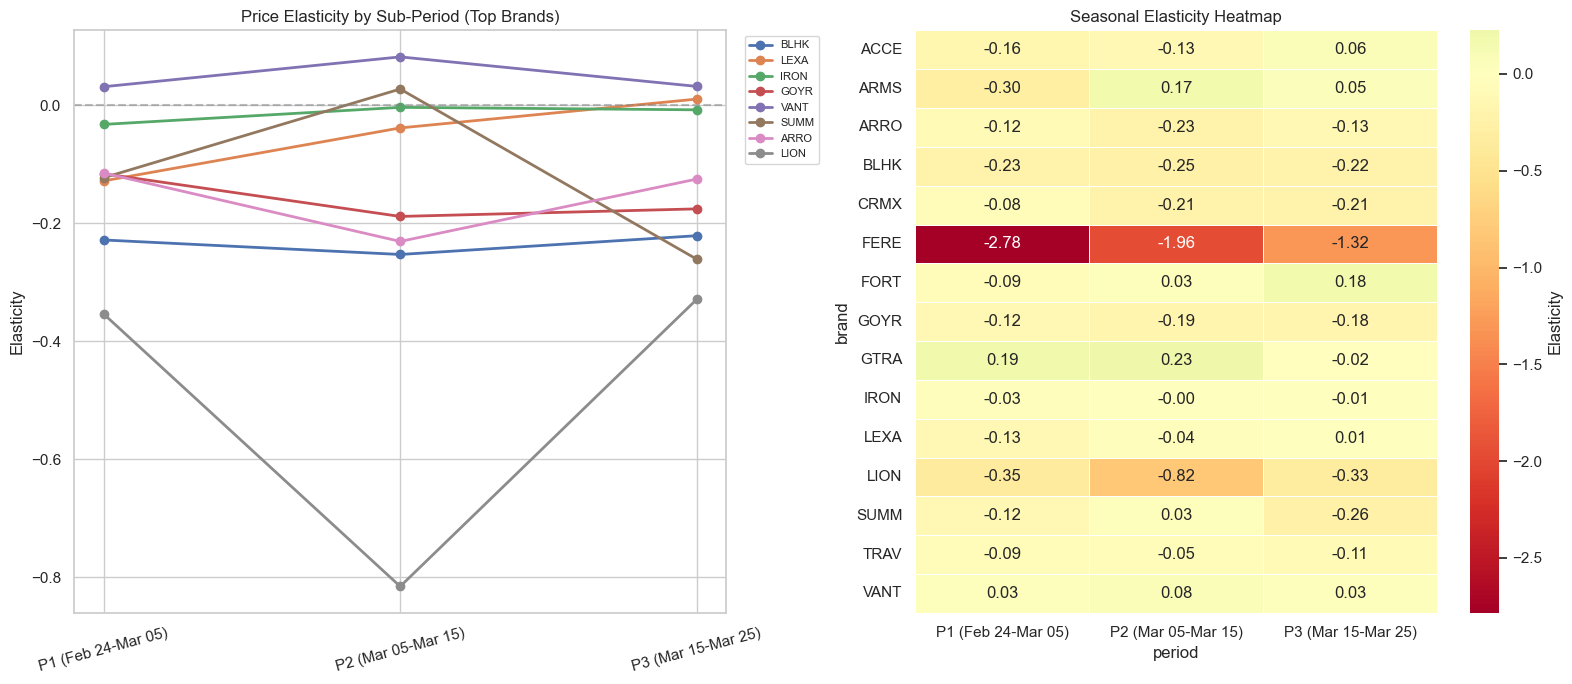


=== Brands with Largest Seasonal Elasticity Shift ===
  FERE: range = 1.468 (min=-2.784, max=-1.317)
  LION: range = 0.486 (min=-0.815, max=-0.329)
  ARMS: range = 0.470 (min=-0.304, max=0.166)
  SUMM: range = 0.288 (min=-0.261, max=0.027)
  FORT: range = 0.268 (min=-0.090, max=0.179)


In [47]:
# --- Seasonal Visualization ---
# Line chart: elasticity by period per brand
brand_seasonal = df_seasonal[df_seasonal["brand"] != "ALL"].copy()

if len(brand_seasonal) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Line chart
    for brand in top_brands_s[:8]:  # top 8 for readability
        b_data = brand_seasonal[brand_seasonal["brand"] == brand].sort_values("period")
        if len(b_data) >= 2:
            axes[0].plot(b_data["period"], b_data["elasticity"], marker="o", label=brand, linewidth=2)
    axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    axes[0].set_title("Price Elasticity by Sub-Period (Top Brands)")
    axes[0].set_ylabel("Elasticity")
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    axes[0].tick_params(axis="x", rotation=15)

    # Heatmap
    pivot_s = brand_seasonal.pivot(index="brand", columns="period", values="elasticity")
    sns.heatmap(pivot_s, cmap="RdYlGn", center=0, annot=True, fmt=".2f",
                linewidths=0.5, ax=axes[1], cbar_kws={"label": "Elasticity"})
    axes[1].set_title("Seasonal Elasticity Heatmap")

    plt.tight_layout()
    plt.show()

    # Narrative: brands with largest seasonal shift
    brand_shift = brand_seasonal.groupby("brand")["elasticity"].agg(["min", "max"])
    brand_shift["range"] = brand_shift["max"] - brand_shift["min"]
    top_shifters = brand_shift.nlargest(5, "range")
    print("\n=== Brands with Largest Seasonal Elasticity Shift ===")
    for brand, r in top_shifters.iterrows():
        print(f"  {brand}: range = {r['range']:.3f} (min={r['min']:.3f}, max={r['max']:.3f})")
else:
    print("Insufficient data for seasonal brand-level visualization.")


## 19. Brand Price Sensitivity Rankings

Ranked table of brands by price elasticity with strategic recommendations.
- **Inelastic** (elasticity closer to 0): candidates for price **increases**
- **Elastic** (large negative elasticity): candidates for price **decreases** to capture volume

In [48]:
# --- Brand Sensitivity Rankings with Recommendations ---
MIN_OBS_BRAND = 30

all_brand_elast = []
for brand, grp in df_elast.groupby("brand"):
    if len(grp) < MIN_OBS_BRAND:
        continue
    try:
        X = sm.add_constant(np.log(grp["offer_price"]))
        y = np.log1p(grp["qty_sold"])
        model = sm.OLS(y, X).fit()
        all_brand_elast.append({
            "brand": brand, "elasticity": model.params.iloc[-1],
            "SE": model.bse.iloc[-1], "p_value": model.pvalues.iloc[-1], "n_obs": len(grp),
        })
    except Exception:
        continue

df_brand_rank = pd.DataFrame(all_brand_elast).sort_values("elasticity")

# Add context columns from the full dataset
brand_stats = df.groupby("brand").agg(
    avg_te_margin=("te_margin", "mean"),
    avg_wm_margin=("walmart_margin", "mean"),
    total_qty=("qty_sold", "sum"),
    total_revenue=("revenue", "sum"),
    n_sku_nodes=("SKU_Node", "nunique"),
    pct_MAP=("is_MAP_tire", "mean"),
    pct_can_show_inv=("can_show_inventory", "mean"),
).reset_index()
df_brand_rank = df_brand_rank.merge(brand_stats, on="brand", how="left")

# Classify sensitivity tier
def _classify(e):
    if e < -1.5: return "Highly Elastic"
    if e < -0.8: return "Elastic"
    if e < -0.3: return "Unit Elastic"
    return "Inelastic"

df_brand_rank["sensitivity_tier"] = df_brand_rank["elasticity"].apply(_classify)

# Recommendation
def _recommend(e):
    if e < -0.8: return "Decrease price to capture volume"
    if e > -0.3: return "Increase price to capture margin"
    return "Monitor - near unit elastic"

df_brand_rank["recommendation"] = df_brand_rank["elasticity"].apply(_recommend)

# Display
print(f"Brands with valid elasticity estimates: {len(df_brand_rank)}")
display(df_brand_rank.style.format({
    "elasticity": "{:.4f}", "SE": "{:.4f}", "p_value": "{:.4f}",
    "avg_te_margin": "{:.1%}", "avg_wm_margin": "{:.1%}",
    "total_qty": "{:,.0f}", "total_revenue": "${:,.0f}",
    "pct_MAP": "{:.0%}", "pct_can_show_inv": "{:.0%}",
}).background_gradient(subset=["elasticity"], cmap="RdYlGn"))

# Top candidates
increase = df_brand_rank[df_brand_rank["recommendation"].str.contains("Increase")].head(5)
decrease = df_brand_rank[df_brand_rank["recommendation"].str.contains("Decrease")].head(5)

print("\n=== TOP 5 PRICE INCREASE CANDIDATES (Inelastic) ===")
for _, r in increase.iterrows():
    print(f"  {r['brand']}: elasticity={r['elasticity']:.3f}, TE margin={r['avg_te_margin']:.1%}, "
          f"MAP={r['pct_MAP']:.0%}, can_show_inv={r['pct_can_show_inv']:.0%}, qty={r['total_qty']:,.0f}")

print("\n=== TOP 5 PRICE DECREASE CANDIDATES (Elastic) ===")
for _, r in decrease.iterrows():
    print(f"  {r['brand']}: elasticity={r['elasticity']:.3f}, TE margin={r['avg_te_margin']:.1%}, "
          f"MAP={r['pct_MAP']:.0%}, can_show_inv={r['pct_can_show_inv']:.0%}, qty={r['total_qty']:,.0f}")

Brands with valid elasticity estimates: 116


,brand,elasticity,SE,p_value,n_obs,avg_te_margin,avg_wm_margin,total_qty,total_revenue,n_sku_nodes,pct_MAP,pct_can_show_inv,sensitivity_tier,recommendation
0,FERE,-2.0804,0.2276,0.0000,421,10.7%,11.9%,"7,080","$334,158",82,0%,66%,Highly Elastic,Decrease price to capture volume
1,MONT,-1.4312,0.3599,0.0001,216,10.8%,-4.4%,"1,947","$131,026",53,0%,78%,Elastic,Decrease price to capture volume
2,LAUF,-1.2123,0.2273,0.0000,100,8.9%,-5.3%,590,"$44,115",66,0%,78%,Elastic,Decrease price to capture volume
3,VERS,-0.6646,0.1457,0.0000,117,4.7%,12.1%,961,"$69,418",24,0%,98%,Unit Elastic,Monitor - near unit elastic
4,DURM,-0.6323,0.3183,0.0519,58,10.7%,1.4%,281,"$45,255",9,0%,85%,Unit Elastic,Monitor - near unit elastic
5,TRAI,-0.5409,0.2629,0.0429,83,13.8%,9.2%,288,"$29,195",59,0%,69%,Unit Elastic,Monitor - near unit elastic
6,MICH,-0.5405,0.0561,0.0000,782,14.0%,12.7%,"3,019","$569,676",884,77%,88%,Unit Elastic,Monitor - near unit elastic
7,DUNL,-0.5089,0.1469,0.0009,71,11.5%,12.0%,280,"$22,482",37,0%,89%,Unit Elastic,Monitor - near unit elastic
8,LION,-0.4923,0.0415,0.0000,2040,13.4%,11.2%,"9,132","$637,846",795,0%,77%,Unit Elastic,Monitor - near unit elastic
9,BRID,-0.4808,0.0450,0.0000,964,11.7%,8.9%,"3,869","$631,907",717,8%,80%,Unit Elastic,Monitor - near unit elastic



=== TOP 5 PRICE INCREASE CANDIDATES (Inelastic) ===
  GRND: elasticity=-0.287, TE margin=11.7%, MAP=0%, can_show_inv=77%, qty=2,566
  ZEET: elasticity=-0.276, TE margin=10.8%, MAP=0%, can_show_inv=78%, qty=2,729
  FIRE: elasticity=-0.263, TE margin=11.5%, MAP=25%, can_show_inv=83%, qty=1,643
  KEND: elasticity=-0.259, TE margin=12.2%, MAP=51%, can_show_inv=91%, qty=1,605
  SCPT: elasticity=-0.252, TE margin=15.4%, MAP=0%, can_show_inv=81%, qty=69

=== TOP 5 PRICE DECREASE CANDIDATES (Elastic) ===
  FERE: elasticity=-2.080, TE margin=10.7%, MAP=0%, can_show_inv=66%, qty=7,080
  MONT: elasticity=-1.431, TE margin=10.8%, MAP=0%, can_show_inv=78%, qty=1,947
  LAUF: elasticity=-1.212, TE margin=8.9%, MAP=0%, can_show_inv=78%, qty=590


## 19B. Sales & Margin Analysis by Tire Size

Distribution of sales and margins segmented by tire diameter.

Tire diameters with data: 16


,tire_diameter,total_qty,avg_qty,total_revenue,avg_te_margin,avg_wm_margin,n_sku_nodes
4,17.000000,"70,622",0.25,"$6,183,727",12.1%,11.4%,1329
5,18.000000,"64,030",0.22,"$6,214,274",12.0%,10.7%,1208
3,16.000000,"43,076",0.22,"$3,373,383",12.2%,12.1%,1027
7,20.000000,"34,496",0.18,"$4,593,110",11.7%,11.7%,921
2,15.000000,"27,430",0.23,"$1,751,654",12.2%,14.2%,551
6,19.000000,"23,827",0.20,"$2,360,461",11.7%,12.1%,470
1,14.000000,"6,259",0.19,"$331,306",11.9%,18.5%,162
9,22.000000,"5,210",0.14,"$745,597",11.6%,11.4%,198
12,25.000000,"2,897",0.23,"$921,155",12.3%,6.4%,94
8,21.000000,"1,808",0.14,"$263,073",12.0%,13.5%,80


2026-03-30 18:17:25,154 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-03-30 18:17:25,155 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-03-30 18:17:25,161 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-03-30 18:17:25,163 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-03-30 18:17:25,170 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-03-30 18:17:25,171 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


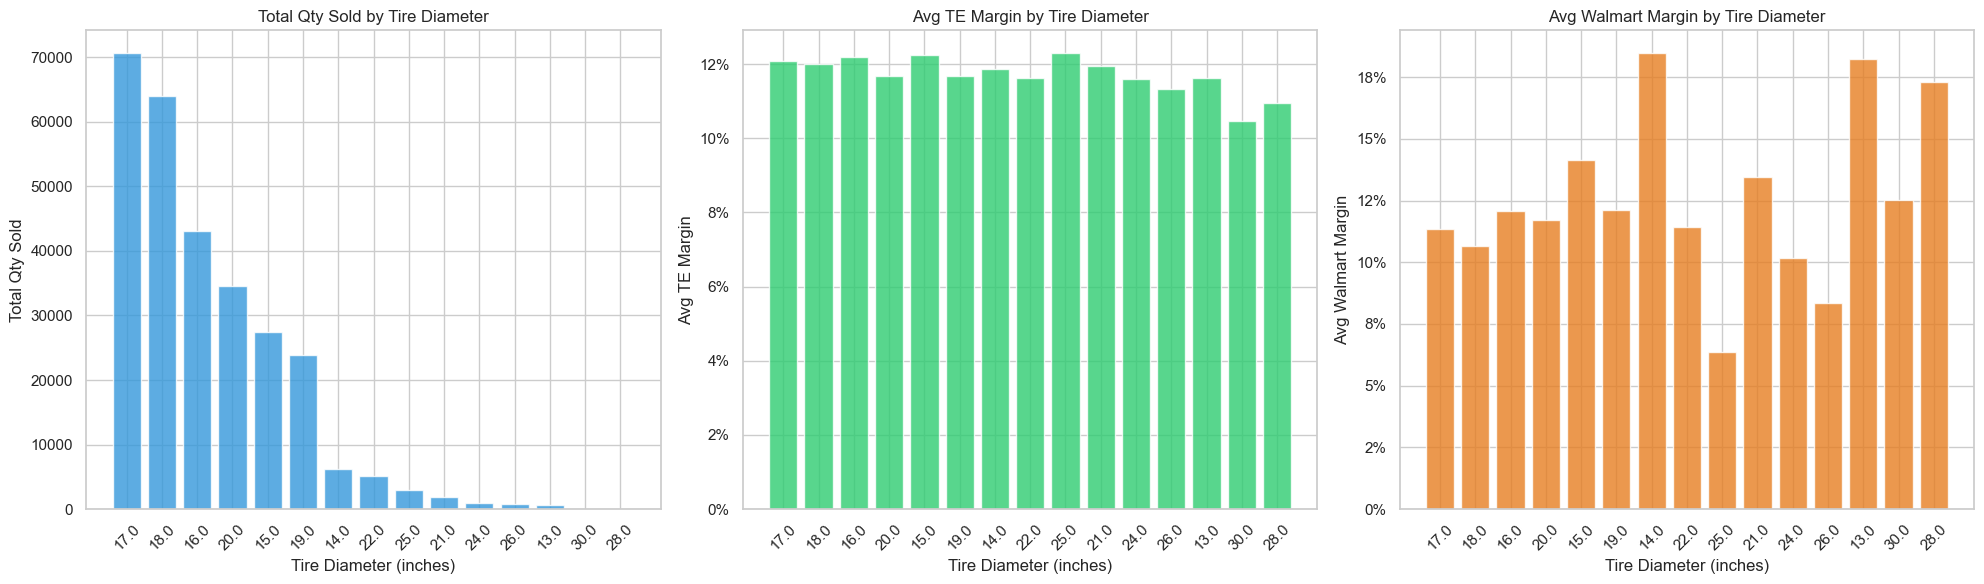


Spearman correlation of tire diameter with key metrics:
  walmart_margin           : -0.0779
  te_margin                : -0.0367
  qty_sold                 : -0.0023
  revenue                  : -0.0002
  offer_price              : +0.4617
  cost_to_walmart          : +0.4741


In [49]:
# --- Sales & Margin by Tire Diameter ---
df_size = df[df["tire_diameter"].notna()].copy()

if len(df_size) > 0:
    # Group by tire diameter
    size_stats = df_size.groupby("tire_diameter").agg(
        total_qty=("qty_sold", "sum"),
        avg_qty=("qty_sold", "mean"),
        total_revenue=("revenue", "sum"),
        avg_te_margin=("te_margin", "mean"),
        avg_wm_margin=("walmart_margin", "mean"),
        n_sku_nodes=("sku", "nunique"),
    ).reset_index().sort_values("total_qty", ascending=False)

    print(f"Tire diameters with data: {len(size_stats)}")
    display(size_stats.head(20).style.format({
        "total_qty": "{:,.0f}", "avg_qty": "{:.2f}",
        "total_revenue": "${:,.0f}",
        "avg_te_margin": "{:.1%}", "avg_wm_margin": "{:.1%}",
    }))

    # Top 15 diameters by sales volume
    top_diameters = size_stats.head(15)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Sales by diameter
    axes[0].bar(top_diameters["tire_diameter"].astype(str), top_diameters["total_qty"], color="#3498db", alpha=0.8)
    axes[0].set_title("Total Qty Sold by Tire Diameter")
    axes[0].set_xlabel("Tire Diameter (inches)")
    axes[0].set_ylabel("Total Qty Sold")
    axes[0].tick_params(axis="x", rotation=45)

    # TE margin by diameter
    axes[1].bar(top_diameters["tire_diameter"].astype(str), top_diameters["avg_te_margin"], color="#2ecc71", alpha=0.8)
    axes[1].set_title("Avg TE Margin by Tire Diameter")
    axes[1].set_xlabel("Tire Diameter (inches)")
    axes[1].set_ylabel("Avg TE Margin")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    axes[1].tick_params(axis="x", rotation=45)

    # Walmart margin by diameter
    axes[2].bar(top_diameters["tire_diameter"].astype(str), top_diameters["avg_wm_margin"], color="#e67e22", alpha=0.8)
    axes[2].set_title("Avg Walmart Margin by Tire Diameter")
    axes[2].set_xlabel("Tire Diameter (inches)")
    axes[2].set_ylabel("Avg Walmart Margin")
    axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    # Correlation of tire diameter with key metrics
    corr_cols = ["tire_diameter", "qty_sold", "revenue", "te_margin", "walmart_margin", "cost_to_walmart", "offer_price"]
    size_corr = df_size[corr_cols].corr(method="spearman")["tire_diameter"].drop("tire_diameter").sort_values()
    print("\nSpearman correlation of tire diameter with key metrics:")
    for col, val in size_corr.items():
        print(f"  {col:25s}: {val:+.4f}")
else:
    print("No tire diameter data available for analysis.")

## 19C. MAP vs Non-MAP Tire Analysis

Compare sales volume, margins, and price sensitivity between MAP-protected and non-MAP tires.

MAP tires: 190,650 rows, 1105 unique SKUs
Non-MAP tires: 1,150,050 rows, 5205 unique SKUs


,metric,MAP_mean,NonMAP_mean,MAP_median,NonMAP_median,MannWhitney_p,significant
0,qty_sold,0.0875,0.2345,0.0000,0.0000,0.0000e+00,True
1,revenue,15.7571,21.2560,0.0000,0.0000,0.0000e+00,True
2,te_margin,0.1298,0.1179,0.1163,0.1100,0.0000e+00,True
3,walmart_margin,0.1565,0.1143,0.1712,0.1150,0.0000e+00,True
4,cost_to_walmart,177.6327,105.2190,170.7900,86.9000,0.0000e+00,True
5,offer_price,210.3930,119.4504,201.9900,99.7200,0.0000e+00,True


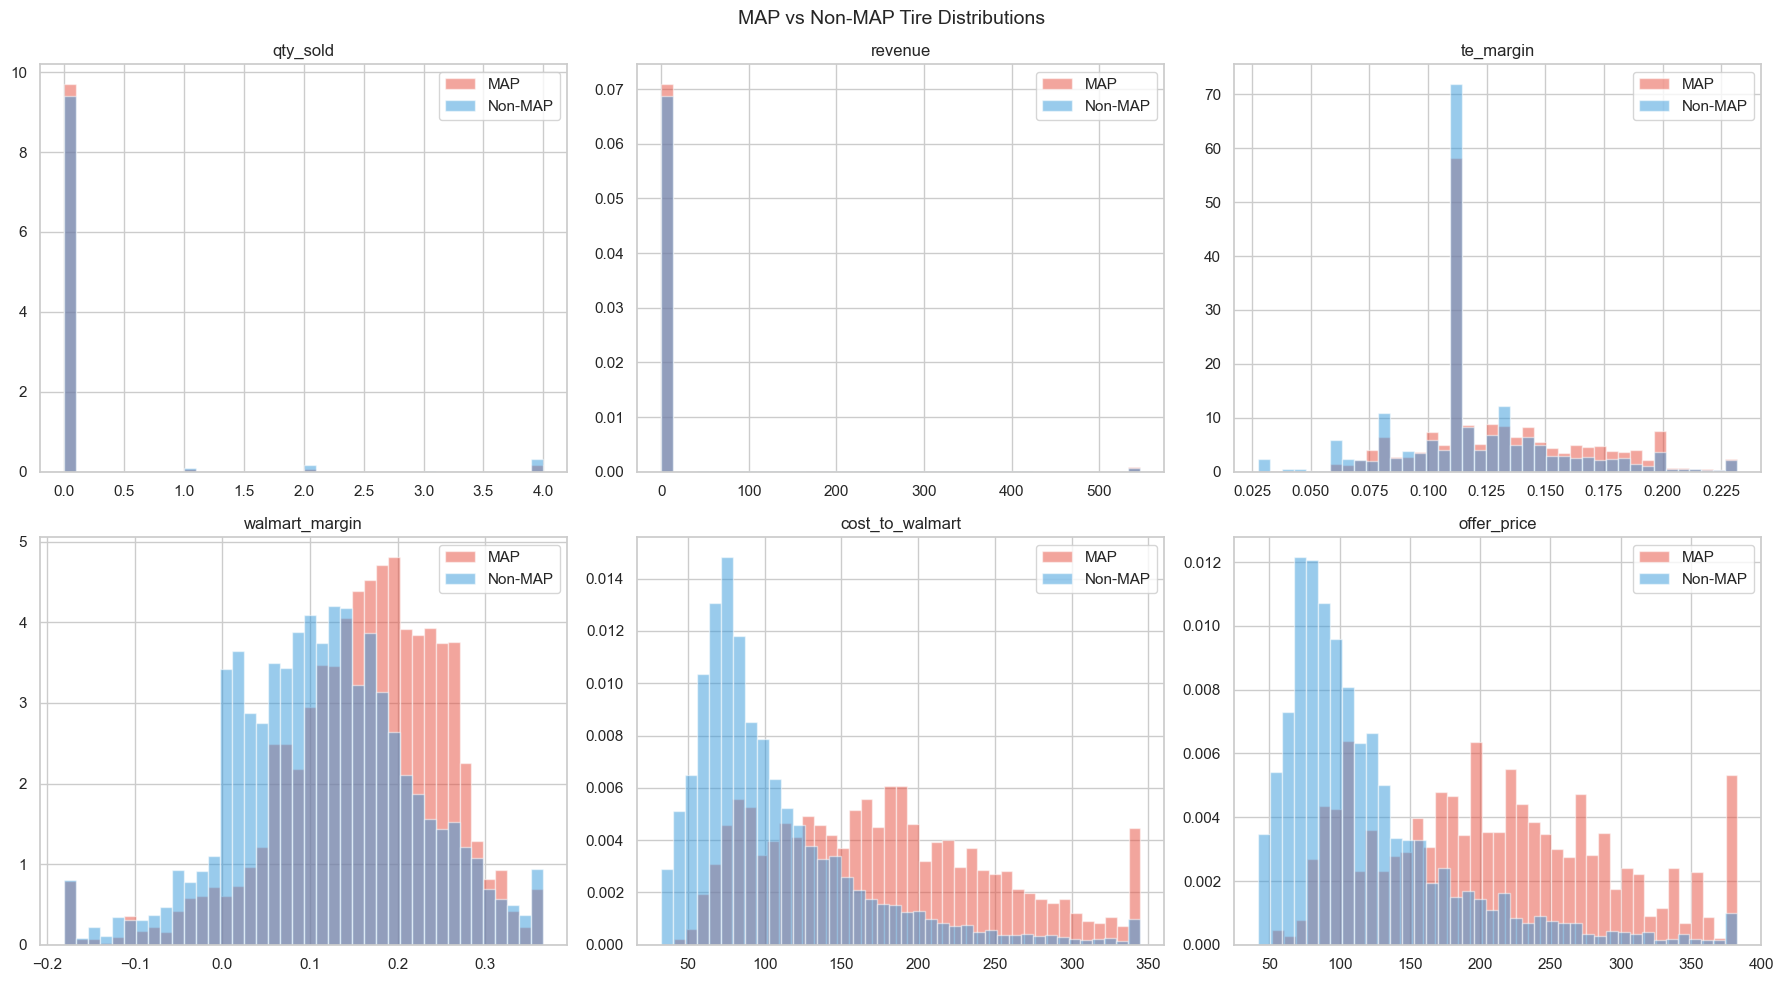


Top 20 brands by sales - MAP share:


,NonMAP_qty,MAP_qty,total,MAP_share
brand,,,,
BLHK,"40,101",0,"40,101",0%
LEXA,"26,381",0,"26,381",0%
IRON,"15,294",543,"15,837",3%
GOYR,"10,142","1,960","12,102",16%
VANT,"11,533",0,"11,533",0%
SUMM,"10,548",0,"10,548",0%
ARRO,"10,054",0,"10,054",0%
LION,"9,132",0,"9,132",0%
CRMX,"7,971",0,"7,971",0%



--- Suggestions ---
Non-MAP tires show higher avg sales. More pricing flexibility may help capture demand.
Consider separate elasticity-based pricing strategies for MAP vs non-MAP segments.


In [50]:
# --- MAP vs Non-MAP Comparison ---
from scipy.stats import mannwhitneyu

map_tires = df[df["is_MAP_tire"] == True]
non_map_tires = df[df["is_MAP_tire"] == False]

print(f"MAP tires: {len(map_tires):,} rows, {map_tires['sku'].nunique()} unique SKUs")
print(f"Non-MAP tires: {len(non_map_tires):,} rows, {non_map_tires['sku'].nunique()} unique SKUs")

# Compare key metrics
compare_cols = ["qty_sold", "revenue", "te_margin", "walmart_margin", "cost_to_walmart", "offer_price"]
comparison = []
for col in compare_cols:
    m_vals = map_tires[col].dropna()
    nm_vals = non_map_tires[col].dropna()
    stat, pval = mannwhitneyu(m_vals, nm_vals, alternative="two-sided") if len(m_vals) > 0 and len(nm_vals) > 0 else (np.nan, np.nan)
    comparison.append({
        "metric": col,
        "MAP_mean": m_vals.mean(),
        "NonMAP_mean": nm_vals.mean(),
        "MAP_median": m_vals.median(),
        "NonMAP_median": nm_vals.median(),
        "MannWhitney_p": pval,
        "significant": pval < 0.05 if not np.isnan(pval) else False,
    })

df_compare = pd.DataFrame(comparison)
display(df_compare.style.format({
    "MAP_mean": "{:.4f}", "NonMAP_mean": "{:.4f}",
    "MAP_median": "{:.4f}", "NonMAP_median": "{:.4f}",
    "MannWhitney_p": "{:.4e}",
}))

# Side-by-side distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, col in enumerate(compare_cols):
    ax = axes[idx // 3, idx % 3]
    m_data = map_tires[col].dropna()
    nm_data = non_map_tires[col].dropna()
    # Clip to reasonable range for visualization
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    ax.hist(m_data.clip(lo, hi), bins=40, alpha=0.5, label="MAP", color="#e74c3c", density=True)
    ax.hist(nm_data.clip(lo, hi), bins=40, alpha=0.5, label="Non-MAP", color="#3498db", density=True)
    ax.set_title(col)
    ax.legend()

plt.suptitle("MAP vs Non-MAP Tire Distributions", fontsize=14)
plt.tight_layout()
plt.show()

# Brand breakdown: MAP vs Non-MAP sales
brand_map = df.groupby(["brand", "is_MAP_tire"]).agg(
    total_qty=("qty_sold", "sum"),
    avg_te_margin=("te_margin", "mean"),
).reset_index()
brand_map_pivot = brand_map.pivot(index="brand", columns="is_MAP_tire", values="total_qty").fillna(0)
brand_map_pivot.columns = ["NonMAP_qty", "MAP_qty"]
brand_map_pivot["total"] = brand_map_pivot.sum(axis=1)
brand_map_pivot["MAP_share"] = brand_map_pivot["MAP_qty"] / brand_map_pivot["total"]
brand_map_pivot = brand_map_pivot.sort_values("total", ascending=False).head(20)

print("\nTop 20 brands by sales - MAP share:")
display(brand_map_pivot.style.format({
    "NonMAP_qty": "{:,.0f}", "MAP_qty": "{:,.0f}", "total": "{:,.0f}", "MAP_share": "{:.0%}",
}))

# Suggestion
print("\n--- Suggestions ---")
if df_compare[df_compare["metric"] == "qty_sold"]["MAP_mean"].values[0] > df_compare[df_compare["metric"] == "qty_sold"]["NonMAP_mean"].values[0]:
    print("MAP tires show higher avg sales. MAP floor may be creating a price anchor that drives volume.")
else:
    print("Non-MAP tires show higher avg sales. More pricing flexibility may help capture demand.")
print("Consider separate elasticity-based pricing strategies for MAP vs non-MAP segments.")

## 19D. Inventory Visibility Analysis (`can_show_inventory`)

Analyze the impact of price-based inventory visibility on sales. `can_show_inventory` is True when
`cost_to_walmart > (Purchase Price + FET) / 0.96`, meaning Walmart can display the item with at least 4% margin.

can_show_inventory = True:  1,131,761 rows (98.7%)
can_show_inventory = False: 14,811 rows (1.3%)
Unique SKU-Nodes visible:   40,934
Unique SKU-Nodes invisible: 1,363


,metric,visible_mean,invisible_mean,visible_median,invisible_median,MannWhitney_p
0,qty_sold,0.2262,0.0908,0.0000,0.0000,1.5404e-69
1,revenue,21.6211,9.2059,0.0000,0.0000,3.8008e-69
2,profit,2.3353,0.6219,0.0000,0.0000,1.7026e-130
3,te_margin,0.1220,-0.0550,0.1100,-0.0171,0.0000e+00
4,walmart_margin,0.1215,0.0709,0.1243,0.0510,0.0000e+00


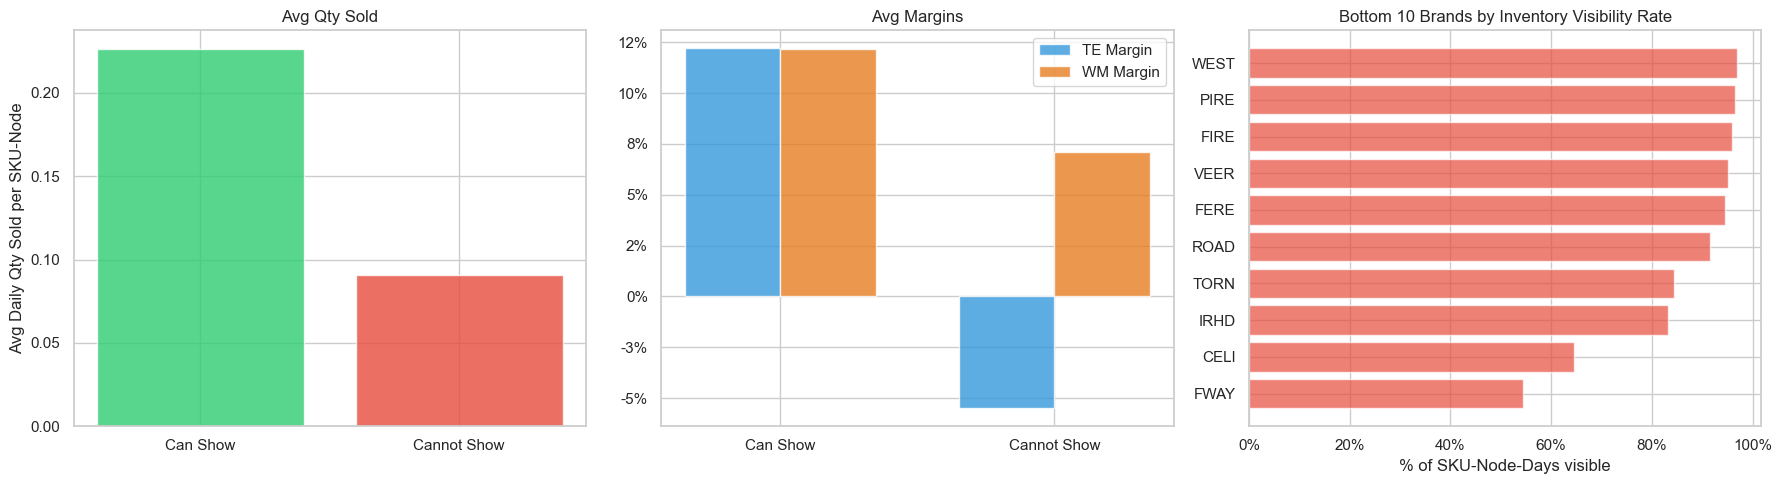


--- Suggestions ---
99% of SKU-Node-Days have sufficient pricing for inventory visibility.


In [51]:
# --- Inventory Visibility Impact ---
# Filter to rows where both prices are available for fair comparison
df_vis = df[df["min_purchase_price_fet"].notna() & df["cost_to_walmart"].notna()].copy()

can_show = df_vis[df_vis["can_show_inventory"] == True]
cant_show = df_vis[df_vis["can_show_inventory"] == False]

print(f"can_show_inventory = True:  {len(can_show):,} rows ({len(can_show)/len(df_vis):.1%})")
print(f"can_show_inventory = False: {len(cant_show):,} rows ({len(cant_show)/len(df_vis):.1%})")
print(f"Unique SKU-Nodes visible:   {can_show[['sku','node']].drop_duplicates().shape[0]:,}")
print(f"Unique SKU-Nodes invisible: {cant_show[['sku','node']].drop_duplicates().shape[0]:,}")

# Sales comparison
vis_metrics = ["qty_sold", "revenue", "profit", "te_margin", "walmart_margin"]
vis_comparison = []
for col in vis_metrics:
    cs = can_show[col].dropna()
    cn = cant_show[col].dropna()
    stat, pval = mannwhitneyu(cs, cn, alternative="two-sided") if len(cs) > 0 and len(cn) > 0 else (np.nan, np.nan)
    vis_comparison.append({
        "metric": col,
        "visible_mean": cs.mean(), "invisible_mean": cn.mean(),
        "visible_median": cs.median(), "invisible_median": cn.median(),
        "MannWhitney_p": pval,
    })

df_vis_compare = pd.DataFrame(vis_comparison)
display(df_vis_compare.style.format({
    "visible_mean": "{:.4f}", "invisible_mean": "{:.4f}",
    "visible_median": "{:.4f}", "invisible_median": "{:.4f}",
    "MannWhitney_p": "{:.4e}",
}))

# Bar chart: visible vs invisible
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Avg qty sold
labels = ["Can Show", "Cannot Show"]
axes[0].bar(labels, [can_show["qty_sold"].mean(), cant_show["qty_sold"].mean()],
            color=["#2ecc71", "#e74c3c"], alpha=0.8)
axes[0].set_title("Avg Qty Sold")
axes[0].set_ylabel("Avg Daily Qty Sold per SKU-Node")

# Avg margins
x = np.arange(2)
w = 0.35
axes[1].bar(x - w/2, [can_show["te_margin"].mean(), cant_show["te_margin"].mean()],
            w, label="TE Margin", color="#3498db", alpha=0.8)
axes[1].bar(x + w/2, [can_show["walmart_margin"].mean(), cant_show["walmart_margin"].mean()],
            w, label="WM Margin", color="#e67e22", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title("Avg Margins")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].legend()

# Brand-level visibility rate
brand_vis = df_vis.groupby("brand")["can_show_inventory"].mean().sort_values()
bottom_10 = brand_vis.head(10)
axes[2].barh(bottom_10.index, bottom_10.values, color="#e74c3c", alpha=0.7)
axes[2].set_title("Bottom 10 Brands by Inventory Visibility Rate")
axes[2].set_xlabel("% of SKU-Node-Days visible")
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

plt.tight_layout()
plt.show()

# Suggestions
print("\n--- Suggestions ---")
vis_rate = df_vis["can_show_inventory"].mean()
if vis_rate < 0.7:
    print(f"Only {vis_rate:.0%} of SKU-Node-Days have prices high enough for Walmart to show inventory.")
    print("Consider raising cost_to_walmart for low-visibility SKU-Nodes to increase listing exposure.")
else:
    print(f"{vis_rate:.0%} of SKU-Node-Days have sufficient pricing for inventory visibility.")

low_vis_brands = brand_vis[brand_vis < 0.5]
if len(low_vis_brands) > 0:
    print(f"\nBrands with <50% visibility: {', '.join(low_vis_brands.index.tolist())}")
    print("These brands may benefit from price adjustments to improve Walmart listing visibility.")

## 19E. Segmented Price Elasticity (Size, MAP, Inventory Visibility)

Recompute brand-level price elasticity broken down by tire diameter group, MAP status, and inventory visibility.

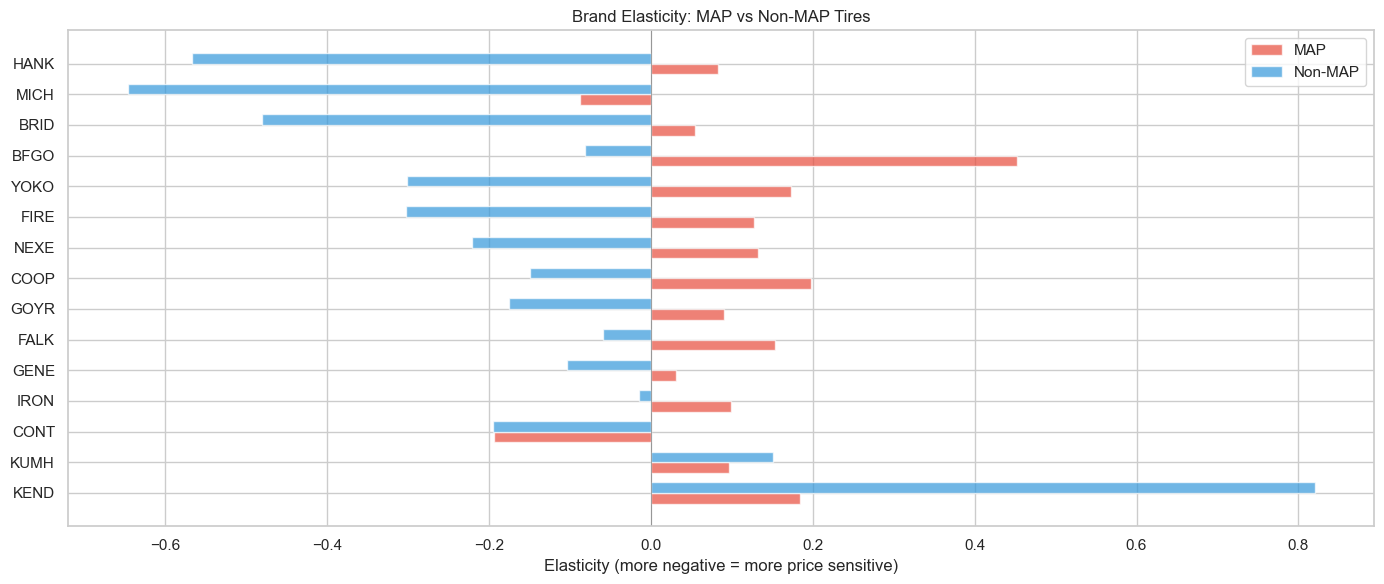


Brands where MAP tires are MORE price-sensitive than Non-MAP:
  KEND: MAP=0.184, Non-MAP=0.820

Brands where Non-MAP tires are MORE price-sensitive:
  IRON: MAP=0.100, Non-MAP=-0.015
  GENE: MAP=0.031, Non-MAP=-0.104
  FALK: MAP=0.153, Non-MAP=-0.059
  GOYR: MAP=0.090, Non-MAP=-0.175
  COOP: MAP=0.198, Non-MAP=-0.149
  NEXE: MAP=0.132, Non-MAP=-0.221
  FIRE: MAP=0.128, Non-MAP=-0.303
  YOKO: MAP=0.173, Non-MAP=-0.301
  BFGO: MAP=0.452, Non-MAP=-0.082
  BRID: MAP=0.055, Non-MAP=-0.480
  MICH: MAP=-0.087, Non-MAP=-0.646
  HANK: MAP=0.083, Non-MAP=-0.567


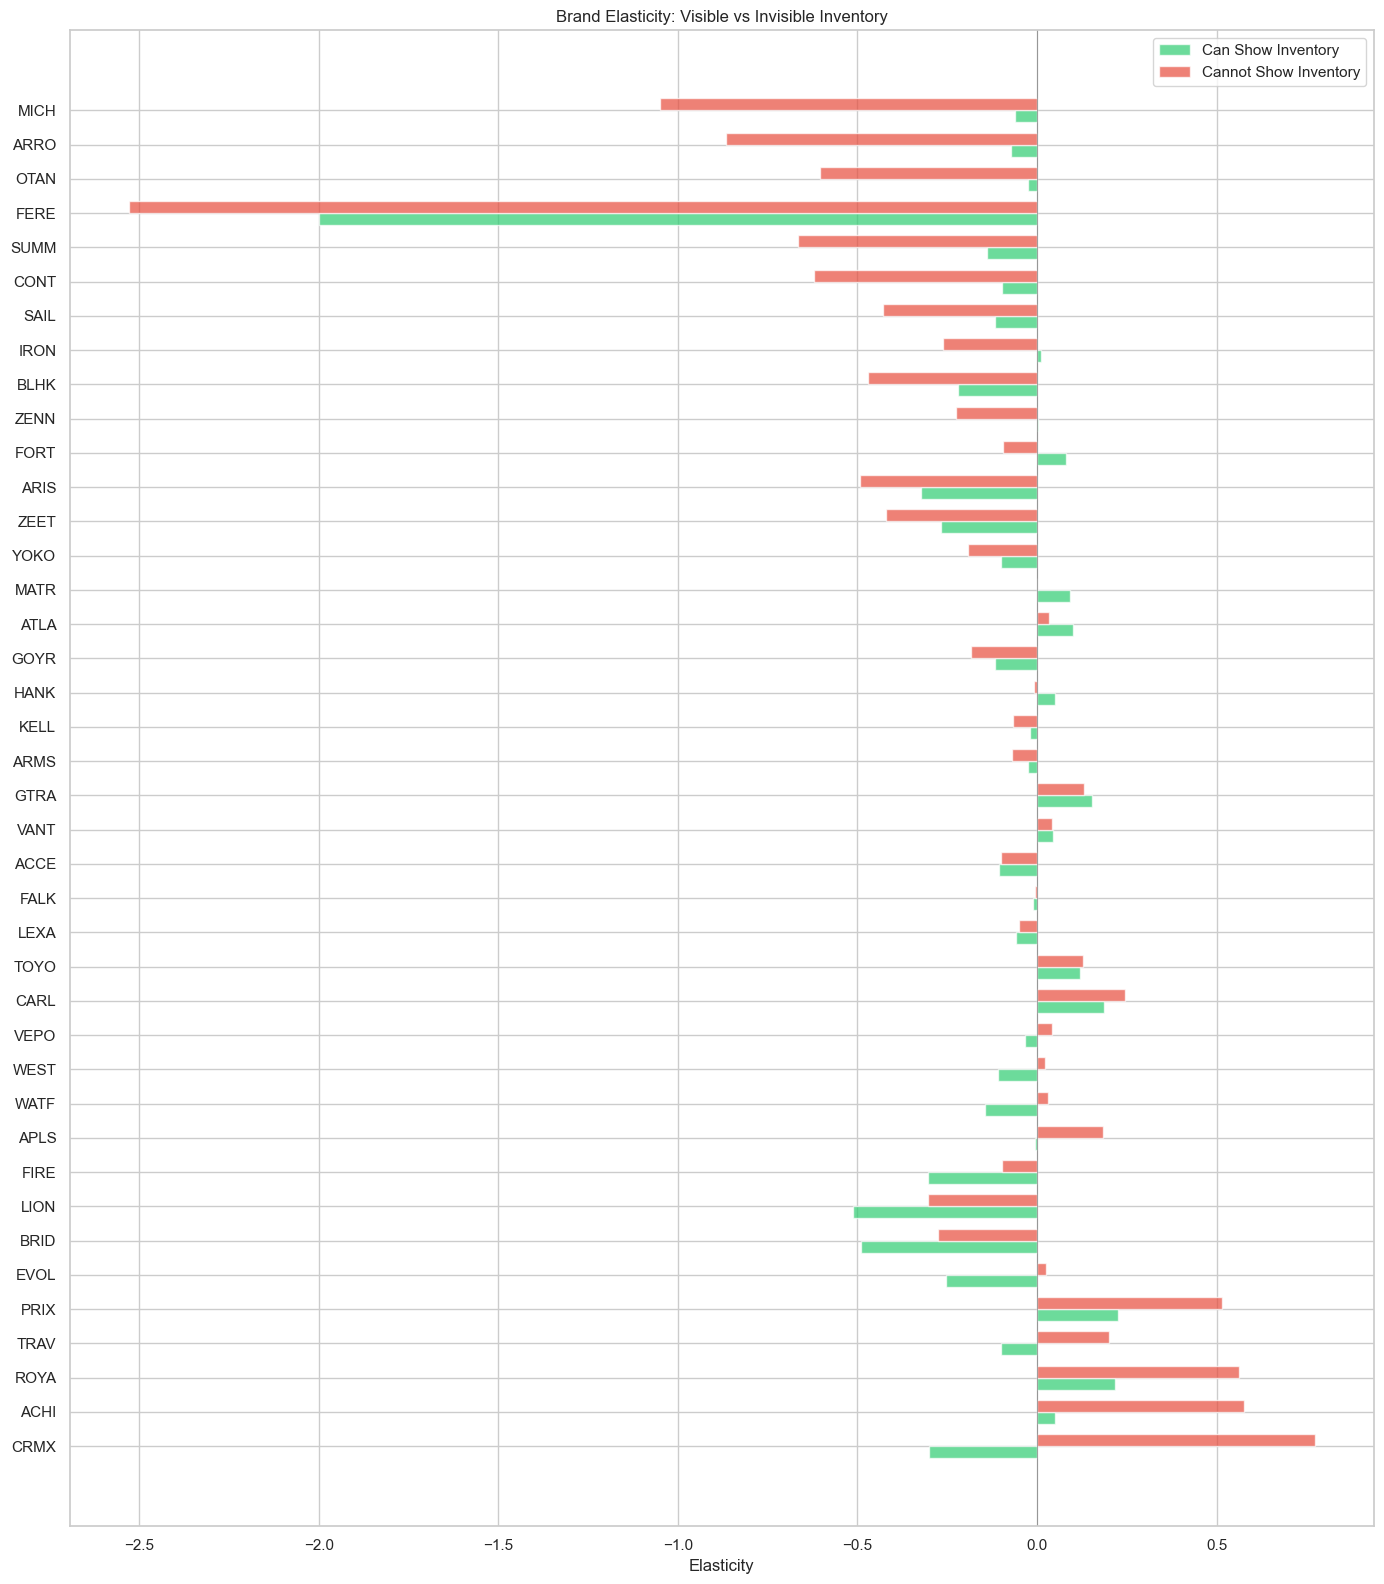

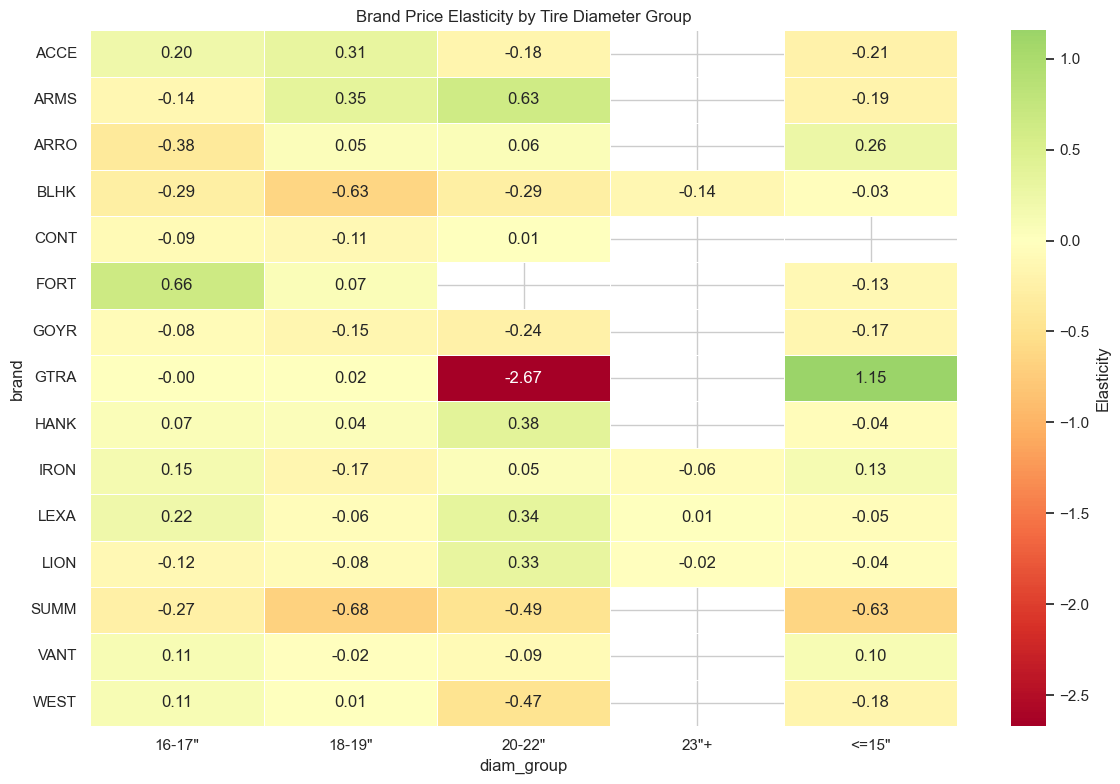


Overall elasticity by tire diameter group:


,diam_group,avg_elasticity,median_elasticity,n_brands
0,"16-17""",0.051112,0.011443,83
1,"18-19""",0.034620,0.011936,70
2,"20-22""",-0.034270,0.101418,57
3,"23""+",-1.280450,0.011177,11
4,"<=15""",-0.297264,-0.044011,58



SEGMENTED ELASTICITY SUMMARY

Key takeaways for pricing strategy:
  MAP tires avg elasticity:     0.094
  Non-MAP tires avg elasticity: -0.082
  -> MAP tires are more price-sensitive on average. Price decreases may drive more volume.
  Most price-sensitive diameter group:  23"+
  Least price-sensitive diameter group: 16-17"
  -> Consider aggressive pricing for elastic diameter groups, margin capture for inelastic ones.


In [52]:
# --- Segmented Elasticity: MAP vs Non-MAP ---
import statsmodels.api as sm

MIN_OBS_SEG = 30
df_elast_seg = df[(df["qty_sold"] > 0) & (df["offer_price"] > 0)].copy()

def compute_elasticity(subset, label):
    """Compute log-log OLS elasticity for a subset."""
    results = []
    for brand, grp in subset.groupby("brand"):
        if len(grp) < MIN_OBS_SEG:
            continue
        try:
            X = sm.add_constant(np.log(grp["offer_price"]))
            y = np.log1p(grp["qty_sold"])
            model = sm.OLS(y, X).fit()
            results.append({
                "brand": brand, "segment": label,
                "elasticity": model.params.iloc[-1],
                "p_value": model.pvalues.iloc[-1], "n_obs": len(grp),
            })
        except Exception:
            continue
    return results

# 1. MAP vs Non-MAP elasticity
map_elast = compute_elasticity(df_elast_seg[df_elast_seg["is_MAP_tire"] == True], "MAP")
nonmap_elast = compute_elasticity(df_elast_seg[df_elast_seg["is_MAP_tire"] == False], "Non-MAP")
df_map_elast = pd.DataFrame(map_elast + nonmap_elast)

if len(df_map_elast) > 0:
    pivot_map = df_map_elast.pivot(index="brand", columns="segment", values="elasticity")
    # Show brands present in both segments
    both = pivot_map.dropna()
    if len(both) > 0:
        both["diff"] = both["MAP"] - both["Non-MAP"]
        both = both.sort_values("diff")

        fig, ax = plt.subplots(figsize=(14, max(6, len(both) * 0.4)))
        x = np.arange(len(both))
        w = 0.35
        ax.barh(x - w/2, both["MAP"], w, label="MAP", color="#e74c3c", alpha=0.7)
        ax.barh(x + w/2, both["Non-MAP"], w, label="Non-MAP", color="#3498db", alpha=0.7)
        ax.set_yticks(x)
        ax.set_yticklabels(both.index)
        ax.set_xlabel("Elasticity (more negative = more price sensitive)")
        ax.set_title("Brand Elasticity: MAP vs Non-MAP Tires")
        ax.legend()
        ax.axvline(0, color="gray", linewidth=0.5)
        plt.tight_layout()
        plt.show()

        print("\nBrands where MAP tires are MORE price-sensitive than Non-MAP:")
        more_sens = both[both["diff"] < -0.1]
        for brand, row in more_sens.iterrows():
            print(f"  {brand}: MAP={row['MAP']:.3f}, Non-MAP={row['Non-MAP']:.3f}")

        print("\nBrands where Non-MAP tires are MORE price-sensitive:")
        less_sens = both[both["diff"] > 0.1]
        for brand, row in less_sens.iterrows():
            print(f"  {brand}: MAP={row['MAP']:.3f}, Non-MAP={row['Non-MAP']:.3f}")
    else:
        print("No brands have sufficient data in both MAP and Non-MAP segments.")

# 2. can_show_inventory: visible vs invisible elasticity
vis_elast = compute_elasticity(df_elast_seg[df_elast_seg["can_show_inventory"] == True], "Visible")
invis_elast = compute_elasticity(df_elast_seg[df_elast_seg["can_show_inventory"] == False], "Invisible")
df_vis_elast = pd.DataFrame(vis_elast + invis_elast)

if len(df_vis_elast) > 0:
    pivot_vis = df_vis_elast.pivot(index="brand", columns="segment", values="elasticity")
    both_vis = pivot_vis.dropna()
    if len(both_vis) > 0:
        both_vis["diff"] = both_vis["Visible"] - both_vis["Invisible"]
        both_vis = both_vis.sort_values("diff")

        fig, ax = plt.subplots(figsize=(14, max(6, len(both_vis) * 0.4)))
        x = np.arange(len(both_vis))
        ax.barh(x - w/2, both_vis["Visible"], w, label="Can Show Inventory", color="#2ecc71", alpha=0.7)
        ax.barh(x + w/2, both_vis["Invisible"], w, label="Cannot Show Inventory", color="#e74c3c", alpha=0.7)
        ax.set_yticks(x)
        ax.set_yticklabels(both_vis.index)
        ax.set_xlabel("Elasticity")
        ax.set_title("Brand Elasticity: Visible vs Invisible Inventory")
        ax.legend()
        ax.axvline(0, color="gray", linewidth=0.5)
        plt.tight_layout()
        plt.show()

# 3. Elasticity by tire diameter group
df_elast_diam = df_elast_seg[df_elast_seg["tire_diameter"].notna()].copy()
# Group diameters into buckets
df_elast_diam["diam_group"] = pd.cut(
    df_elast_diam["tire_diameter"],
    bins=[0, 15, 17, 19, 22, 100],
    labels=["<=15\"", "16-17\"", "18-19\"", "20-22\"", "23\"+"],
)

diam_results = []
for diam, grp in df_elast_diam.groupby("diam_group", observed=True):
    for brand, b_grp in grp.groupby("brand"):
        if len(b_grp) < MIN_OBS_SEG:
            continue
        try:
            X = sm.add_constant(np.log(b_grp["offer_price"]))
            y = np.log1p(b_grp["qty_sold"])
            model = sm.OLS(y, X).fit()
            diam_results.append({
                "brand": brand, "diam_group": str(diam),
                "elasticity": model.params.iloc[-1],
                "p_value": model.pvalues.iloc[-1], "n_obs": len(b_grp),
            })
        except Exception:
            continue

df_diam_elast = pd.DataFrame(diam_results)

if len(df_diam_elast) > 0:
    # Heatmap: brand x diameter group
    top_brands_diam = df_diam_elast.groupby("brand")["n_obs"].sum().nlargest(15).index.tolist()
    pivot_diam = df_diam_elast[df_diam_elast["brand"].isin(top_brands_diam)].pivot(
        index="brand", columns="diam_group", values="elasticity"
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(pivot_diam, cmap="RdYlGn", center=0, annot=True, fmt=".2f",
                linewidths=0.5, ax=ax, cbar_kws={"label": "Elasticity"})
    ax.set_title("Brand Price Elasticity by Tire Diameter Group")
    plt.tight_layout()
    plt.show()

    # Overall diameter elasticity
    diam_overall = df_diam_elast.groupby("diam_group").agg(
        avg_elasticity=("elasticity", "mean"),
        median_elasticity=("elasticity", "median"),
        n_brands=("brand", "nunique"),
    ).reset_index()
    print("\nOverall elasticity by tire diameter group:")
    display(diam_overall)

# --- Summary suggestions ---
print("\n" + "=" * 70)
print("SEGMENTED ELASTICITY SUMMARY")
print("=" * 70)
print("\nKey takeaways for pricing strategy:")
if len(df_map_elast) > 0:
    map_avg = df_map_elast[df_map_elast["segment"] == "MAP"]["elasticity"].mean()
    nonmap_avg = df_map_elast[df_map_elast["segment"] == "Non-MAP"]["elasticity"].mean()
    print(f"  MAP tires avg elasticity:     {map_avg:.3f}")
    print(f"  Non-MAP tires avg elasticity: {nonmap_avg:.3f}")
    if abs(map_avg) > abs(nonmap_avg):
        print("  -> MAP tires are more price-sensitive on average. Price decreases may drive more volume.")
    else:
        print("  -> Non-MAP tires are more price-sensitive. Focus price optimization on non-MAP SKUs.")

if len(df_diam_elast) > 0:
    most_elastic_diam = diam_overall.loc[diam_overall["avg_elasticity"].idxmin(), "diam_group"]
    least_elastic_diam = diam_overall.loc[diam_overall["avg_elasticity"].idxmax(), "diam_group"]
    print(f"  Most price-sensitive diameter group:  {most_elastic_diam}")
    print(f"  Least price-sensitive diameter group: {least_elastic_diam}")
    print("  -> Consider aggressive pricing for elastic diameter groups, margin capture for inelastic ones.")

## 20. Optimal Margin Targeting

For each brand, estimate the TE margin and Walmart margin that maximize revenue or profit.
Fit a quadratic relationship: `qty ~ margin + margin²` to capture the inverted-U shape.

In [53]:
# --- Margin-Sales Relationship by Brand ---
top_brands_margin = df_brand_rank["brand"].head(20).tolist() if len(df_brand_rank) > 0 else top_brands_elast

margin_opt_results = []
df_margin = df[(df["qty_sold"] > 0) & (df["te_margin"].notna()) & (df["te_margin"].between(-0.5, 0.8))].copy()

for brand in top_brands_margin:
    b_data = df_margin[df_margin["brand"] == brand]
    if len(b_data) < 50:
        continue

    for margin_col, margin_name in [("te_margin", "TE Margin"), ("walmart_margin", "Walmart Margin")]:
        b_valid = b_data[b_data[margin_col].notna() & b_data[margin_col].between(-0.5, 0.8)]
        if len(b_valid) < 50:
            continue
        try:
            m = b_valid[margin_col].values
            m2 = m ** 2
            X = sm.add_constant(np.column_stack([m, m2]))
            y = b_valid["qty_sold"].values
            model = sm.OLS(y, X).fit()

            # Vertex of parabola: optimal = -b1 / (2*b2)
            b1, b2 = model.params[1], model.params[2]
            if b2 != 0:
                optimal = -b1 / (2 * b2)
                # Only report if optimal is in a reasonable range
                if -0.1 <= optimal <= 0.5:
                    margin_opt_results.append({
                        "brand": brand, "margin_type": margin_name,
                        "optimal_margin": optimal,
                        "current_avg": b_valid[margin_col].mean(),
                        "gap_pct": optimal - b_valid[margin_col].mean(),
                        "b1": b1, "b2": b2, "R2": model.rsquared,
                        "n_obs": len(b_valid), "is_concave": b2 < 0,
                    })
        except Exception:
            continue

df_margin_opt = pd.DataFrame(margin_opt_results)
if len(df_margin_opt) > 0:
    print("=== Optimal Margin Estimates (Quadratic Fit) ===")
    print("Note: 'is_concave=True' means the relationship has a peak (inverted-U).\n")
    display(df_margin_opt.style.format({
        "optimal_margin": "{:.1%}", "current_avg": "{:.1%}", "gap_pct": "{:+.1%}",
        "b1": "{:.4f}", "b2": "{:.4f}", "R2": "{:.4f}",
    }))

    # Flag brands where current margin is far from optimal
    big_gaps = df_margin_opt[(df_margin_opt["gap_pct"].abs() > 0.03) & df_margin_opt["is_concave"]]
    if len(big_gaps) > 0:
        print("\n=== Brands with >3pp Gap from Optimal Margin ===")
        for _, r in big_gaps.iterrows():
            direction = "increase" if r["gap_pct"] > 0 else "decrease"
            print(f"  {r['brand']} ({r['margin_type']}): optimal={r['optimal_margin']:.1%}, "
                  f"current={r['current_avg']:.1%} -> {direction} by {abs(r['gap_pct']):.1%}")
else:
    print("No brands with valid quadratic margin-sales fit in reasonable range.")


=== Optimal Margin Estimates (Quadratic Fit) ===
Note: 'is_concave=True' means the relationship has a peak (inverted-U).



,brand,margin_type,optimal_margin,current_avg,gap_pct,b1,b2,R2,n_obs,is_concave
0,FERE,TE Margin,11.9%,11.5%,+0.3%,-320.6211,1347.7131,0.0145,378,False
1,FERE,Walmart Margin,22.6%,14.8%,+7.7%,147.0735,-325.9647,0.0500,378,True
2,MONT,TE Margin,25.2%,11.0%,+14.3%,110.8346,-219.6983,0.0498,204,True
3,MONT,Walmart Margin,14.7%,-14.6%,+29.4%,-6.7274,22.8366,0.0305,204,False
4,LAUF,TE Margin,8.3%,8.8%,-0.5%,160.4264,-970.7661,0.0244,77,True
5,VERS,TE Margin,12.3%,10.0%,+2.3%,548.5108,-2230.0542,0.0551,117,True
6,VERS,Walmart Margin,11.3%,12.0%,-0.7%,183.6524,-813.9132,0.0995,117,True
7,DURM,Walmart Margin,-3.2%,0.1%,-3.4%,-16.0506,-248.4319,0.0194,58,True
8,MICH,TE Margin,14.2%,13.9%,+0.2%,-17.3244,61.2092,0.0070,644,False
9,MICH,Walmart Margin,1.3%,13.0%,-11.7%,-0.1440,5.3777,0.0052,644,False



=== Brands with >3pp Gap from Optimal Margin ===
  FERE (Walmart Margin): optimal=22.6%, current=14.8% -> increase by 7.7%
  MONT (TE Margin): optimal=25.2%, current=11.0% -> increase by 14.3%
  DURM (Walmart Margin): optimal=-3.2%, current=0.1% -> decrease by 3.4%
  LION (TE Margin): optimal=0.6%, current=13.4% -> decrease by 12.8%
  BRID (TE Margin): optimal=32.7%, current=12.4% -> increase by 20.3%
  POWE (Walmart Margin): optimal=8.6%, current=0.3% -> increase by 8.3%
  ZEET (TE Margin): optimal=-2.5%, current=10.6% -> decrease by 13.1%
  FIRE (TE Margin): optimal=17.2%, current=11.6% -> increase by 5.6%


=== Revenue-Maximizing vs Profit-Maximizing TE Margin ===



,brand,rev_max_margin,profit_max_margin,current_avg,rev_vs_profit_gap
0,FERE,11.9%,-1.3%,11.5%,+13.2%
1,MONT,25.2%,48.6%,11.0%,-23.3%
2,LAUF,8.3%,15.1%,8.8%,-6.8%
3,VERS,12.3%,19.0%,10.0%,-6.7%
4,MICH,14.2%,37.1%,13.9%,-22.9%
5,LION,0.6%,21.9%,13.4%,-21.3%
6,POWE,14.5%,15.9%,11.6%,-1.4%
7,DCEN,13.8%,-2.0%,11.9%,+15.8%
8,DORA,12.6%,3.0%,11.7%,+9.6%
9,ARIS,10.6%,17.0%,11.3%,-6.4%


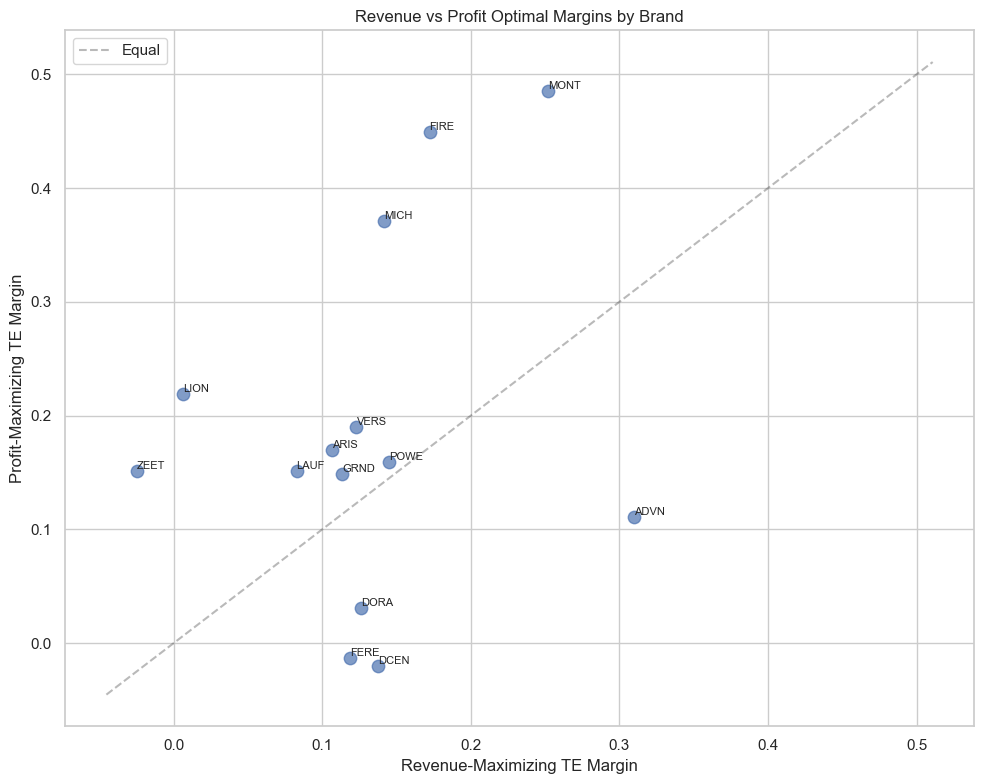

In [54]:
# --- Profit-Maximizing Margin ---
profit_opt_results = []

for brand in top_brands_margin:
    b_data = df_margin[df_margin["brand"] == brand]
    if len(b_data) < 50:
        continue
    b_valid = b_data[b_data["te_margin"].notna() & b_data["cost_to_walmart"].notna()].copy()
    if len(b_valid) < 50:
        continue

    # Profit proxy: qty * te_margin * cost_to_walmart
    b_valid["profit_proxy"] = b_valid["qty_sold"] * b_valid["te_margin"] * b_valid["cost_to_walmart"]

    try:
        m = b_valid["te_margin"].values
        X = sm.add_constant(np.column_stack([m, m ** 2]))
        y = b_valid["profit_proxy"].values
        model = sm.OLS(y, X).fit()
        b1, b2 = model.params[1], model.params[2]
        if b2 != 0:
            optimal_profit = -b1 / (2 * b2)
            if -0.1 <= optimal_profit <= 0.5:
                profit_opt_results.append({
                    "brand": brand,
                    "profit_max_margin": optimal_profit,
                    "current_avg": b_valid["te_margin"].mean(),
                    "is_concave": b2 < 0,
                    "R2": model.rsquared,
                })
    except Exception:
        continue

df_profit_opt = pd.DataFrame(profit_opt_results)

# Compare revenue-maximizing vs profit-maximizing
if len(df_profit_opt) > 0 and len(df_margin_opt) > 0:
    te_rev = df_margin_opt[df_margin_opt["margin_type"] == "TE Margin"][["brand", "optimal_margin"]].rename(
        columns={"optimal_margin": "rev_max_margin"})
    comparison = te_rev.merge(df_profit_opt[["brand", "profit_max_margin", "current_avg"]], on="brand")
    comparison["rev_vs_profit_gap"] = comparison["rev_max_margin"] - comparison["profit_max_margin"]

    print("=== Revenue-Maximizing vs Profit-Maximizing TE Margin ===\n")
    display(comparison.style.format({
        "rev_max_margin": "{:.1%}", "profit_max_margin": "{:.1%}",
        "current_avg": "{:.1%}", "rev_vs_profit_gap": "{:+.1%}",
    }))

    # Scatter plot
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(comparison["rev_max_margin"], comparison["profit_max_margin"], s=80, alpha=0.7)
    for _, r in comparison.iterrows():
        ax.annotate(r["brand"], (r["rev_max_margin"], r["profit_max_margin"]),
                    fontsize=8, ha="left", va="bottom")
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "k--", alpha=0.3, label="Equal")
    ax.set_xlabel("Revenue-Maximizing TE Margin")
    ax.set_ylabel("Profit-Maximizing TE Margin")
    ax.set_title("Revenue vs Profit Optimal Margins by Brand")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for profit-maximizing comparison.")


## 21. What-If Price Change Simulation

Simulate gradual price changes (-5% to +5%) for each brand using estimated elasticity.
- **Elastic brands:** simulate price decreases to capture volume
- **Inelastic brands:** simulate price increases to capture margin

Identify diminishing returns.

In [55]:
# --- Simulation Engine ---
if len(df_brand_rank) > 0:
    pct_changes = np.arange(-0.05, 0.06, 0.01)

    sim_results = []
    for _, br in df_brand_rank.iterrows():
        brand = br["brand"]
        elast = br["elasticity"]
        # Baseline from actual data
        b_data = df[(df["brand"] == brand) & (df["qty_sold"] > 0)]
        if len(b_data) < 30:
            continue
        base_price = b_data["offer_price"].mean()
        base_qty = b_data["qty_sold"].mean()
        base_revenue = base_qty * base_price
        base_cost = b_data["cost_to_walmart"].mean() if "cost_to_walmart" in b_data.columns else base_price * 0.85
        base_profit = base_qty * (base_price - base_cost)

        for pct in pct_changes:
            new_price = base_price * (1 + pct)
            # Constant elasticity model: Q_new = Q_base * (P_new / P_base) ^ elasticity
            if base_price > 0:
                projected_qty = base_qty * (new_price / base_price) ** elast
            else:
                projected_qty = base_qty
            projected_revenue = projected_qty * new_price
            projected_profit = projected_qty * (new_price - base_cost)

            sim_results.append({
                "brand": brand, "pct_change": pct,
                "new_price": new_price, "projected_qty": projected_qty,
                "projected_revenue": projected_revenue, "projected_profit": projected_profit,
                "revenue_change_pct": (projected_revenue - base_revenue) / base_revenue if base_revenue > 0 else 0,
                "profit_change_pct": (projected_profit - base_profit) / base_profit if base_profit > 0 else 0,
                "base_revenue": base_revenue, "base_profit": base_profit,
            })

    df_sim = pd.DataFrame(sim_results)
    print(f"Simulation complete: {df_sim['brand'].nunique()} brands, {len(pct_changes)} price points each")
    print(f"Total simulation rows: {len(df_sim):,}")
else:
    df_sim = pd.DataFrame()
    print("No brand elasticity data available for simulation.")


Simulation complete: 116 brands, 11 price points each
Total simulation rows: 1,276


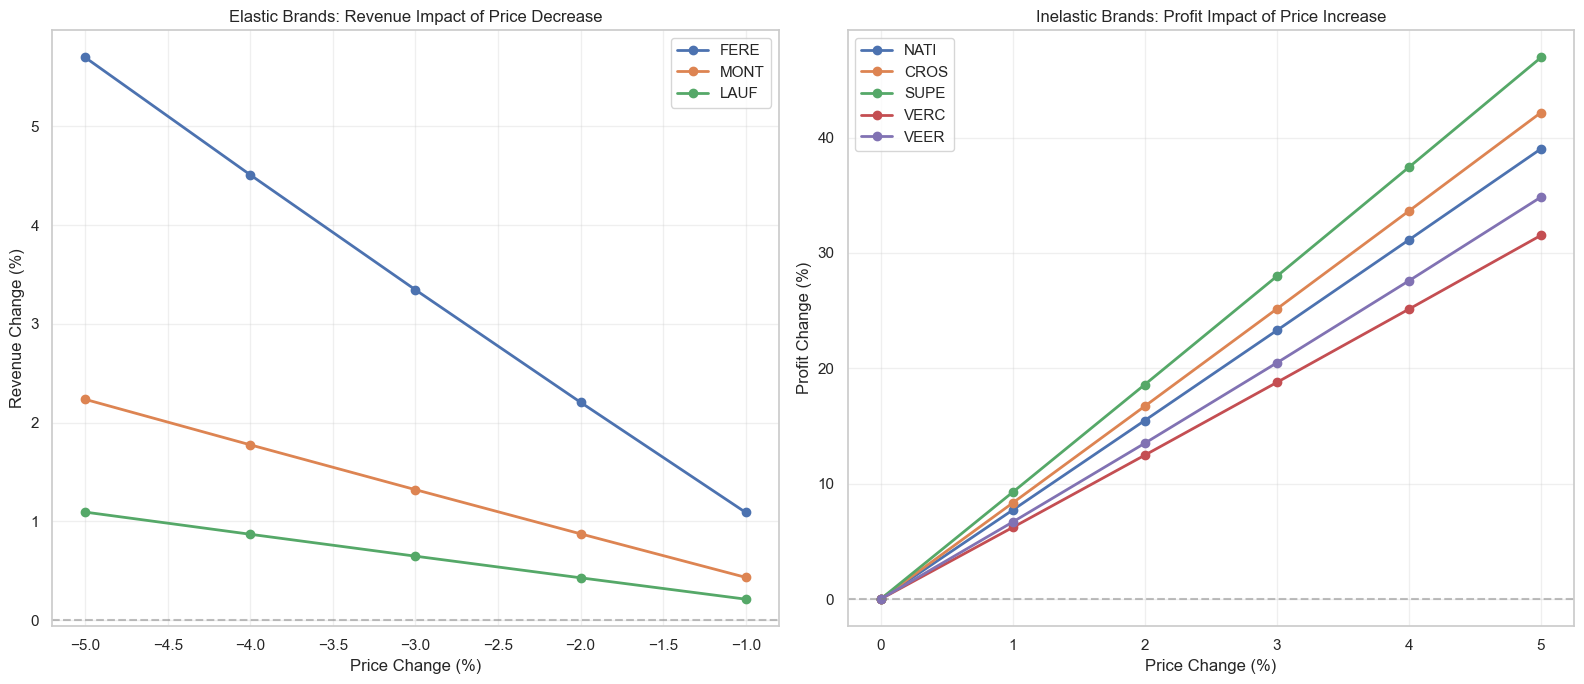


=== Recommended Price Changes (Sweet Spot) ===


,brand,strategy,recommended_pct,expected_revenue_chg,expected_profit_chg
0,FERE,Decrease price,-5%,+5.7%,-
1,MONT,Decrease price,-5%,+2.2%,-
2,LAUF,Decrease price,-5%,+1.1%,-
3,GRND,Increase price,+5%,-,+31.2%
4,ZEET,Increase price,+5%,-,+37.8%
5,FIRE,Increase price,+5%,-,+55.1%
6,KEND,Increase price,+5%,-,+33.4%
7,SCPT,Increase price,+5%,-,+27.8%
8,ADVN,Increase price,+5%,-,+54.3%
9,PETL,Increase price,+5%,-,+33.0%


In [56]:
# --- Visualization & Diminishing Returns ---
if len(df_sim) > 0:
    elastic_brands = df_brand_rank[df_brand_rank["elasticity"] < -0.8]["brand"].head(5).tolist()
    inelastic_brands = df_brand_rank[df_brand_rank["elasticity"] > -0.3]["brand"].tail(5).tolist()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Elastic brands: revenue impact of price decreases
    for brand in elastic_brands:
        b_sim = df_sim[(df_sim["brand"] == brand) & (df_sim["pct_change"] <= 0)].sort_values("pct_change")
        if len(b_sim) > 0:
            axes[0].plot(b_sim["pct_change"] * 100, b_sim["revenue_change_pct"] * 100,
                        marker="o", label=brand, linewidth=2)
    axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    axes[0].set_title("Elastic Brands: Revenue Impact of Price Decrease")
    axes[0].set_xlabel("Price Change (%)")
    axes[0].set_ylabel("Revenue Change (%)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Inelastic brands: profit impact of price increases
    for brand in inelastic_brands:
        b_sim = df_sim[(df_sim["brand"] == brand) & (df_sim["pct_change"] >= 0)].sort_values("pct_change")
        if len(b_sim) > 0:
            axes[1].plot(b_sim["pct_change"] * 100, b_sim["profit_change_pct"] * 100,
                        marker="o", label=brand, linewidth=2)
    axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    axes[1].set_title("Inelastic Brands: Profit Impact of Price Increase")
    axes[1].set_xlabel("Price Change (%)")
    axes[1].set_ylabel("Profit Change (%)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Diminishing returns: find sweet spot per brand
    sweet_spot = []
    for brand in df_sim["brand"].unique():
        b_sim = df_sim[df_sim["brand"] == brand].sort_values("pct_change")
        b_sim["marginal_profit"] = b_sim["projected_profit"].diff() / (b_sim["pct_change"].diff() * b_sim["base_profit"].iloc[0]) if b_sim["base_profit"].iloc[0] != 0 else 0

        elast = df_brand_rank[df_brand_rank["brand"] == brand]["elasticity"].iloc[0]
        if elast < -0.8:  # elastic -> look at decreases
            decreases = b_sim[b_sim["pct_change"] < 0].sort_values("pct_change", ascending=False)
            best_pct = decreases.loc[decreases["revenue_change_pct"].idxmax(), "pct_change"] if len(decreases) > 0 else 0
            best_rev = decreases["revenue_change_pct"].max() if len(decreases) > 0 else 0
            sweet_spot.append({"brand": brand, "strategy": "Decrease price",
                               "recommended_pct": best_pct, "expected_revenue_chg": best_rev})
        elif elast > -0.3:  # inelastic -> look at increases
            increases = b_sim[b_sim["pct_change"] > 0].sort_values("pct_change")
            best_pct = increases.loc[increases["profit_change_pct"].idxmax(), "pct_change"] if len(increases) > 0 else 0
            best_prof = increases["profit_change_pct"].max() if len(increases) > 0 else 0
            sweet_spot.append({"brand": brand, "strategy": "Increase price",
                               "recommended_pct": best_pct, "expected_profit_chg": best_prof})

    df_sweet = pd.DataFrame(sweet_spot)
    if len(df_sweet) > 0:
        print("\n=== Recommended Price Changes (Sweet Spot) ===")
        display(df_sweet.style.format({
            "recommended_pct": "{:+.0%}",
            "expected_revenue_chg": "{:+.1%}",
            "expected_profit_chg": "{:+.1%}",
        }, na_rep="-"))
else:
    print("No simulation data available.")


## 22. Actionable Pricing Strategy by Brand-State Segment

Capstone section combining elasticity, treatment effects, margin analysis, and simulation
into per-segment recommendations.

In [57]:
# --- Build Master Strategy Table ---
strategy_rows = []

# Use brand-state elasticity from §16
if len(df_bs_elast) > 0 and len(df_brand_rank) > 0:
    bs_valid = df_bs_elast.dropna(subset=["elasticity"]).copy()

    for _, r in bs_valid.iterrows():
        brand, state = r["brand"], r["State"]
        elast = r["elasticity"]
        n = r["n"]
        pval = r["p_value"]

        # Get brand-level info
        br_info = df_brand_rank[df_brand_rank["brand"] == brand]
        avg_te = br_info["avg_te_margin"].iloc[0] if len(br_info) > 0 else np.nan
        avg_wm = br_info["avg_wm_margin"].iloc[0] if len(br_info) > 0 else np.nan

        # Get treatment effect if available
        att = np.nan
        if len(df_het) > 0:
            brand_het = df_het[(df_het["segment_type"] == "Brand") & (df_het["segment_value"] == brand)]
            if len(brand_het) > 0:
                att = brand_het["ATT"].iloc[0]

        # Get optimal margin if available
        opt_margin = np.nan
        if len(df_margin_opt) > 0:
            opt = df_margin_opt[(df_margin_opt["brand"] == brand) & (df_margin_opt["margin_type"] == "TE Margin")]
            if len(opt) > 0:
                opt_margin = opt["optimal_margin"].iloc[0]

        # Recommendation logic
        if elast < -0.8:
            action = "Decrease"
            rec_pct = max(-0.05, elast * 0.02)  # conservative: small fraction of elasticity
        elif elast > -0.3:
            action = "Increase"
            rec_pct = min(0.05, abs(elast) * 0.03)
        else:
            action = "Hold"
            rec_pct = 0.0

        # Projected impact (using constant elasticity)
        expected_qty_pct = (1 + rec_pct) ** elast - 1 if rec_pct != 0 else 0
        expected_rev_pct = ((1 + rec_pct) * (1 + expected_qty_pct)) - 1

        # Confidence
        if pval < 0.01 and n > 200:
            confidence = "High"
        elif pval < 0.05 and n > 50:
            confidence = "Medium"
        else:
            confidence = "Low"

        strategy_rows.append({
            "brand": brand, "State": state, "elasticity": elast,
            "treatment_effect": att, "optimal_te_margin": opt_margin,
            "current_te_margin": avg_te, "current_wm_margin": avg_wm,
            "action": action, "recommended_change": rec_pct,
            "expected_qty_impact": expected_qty_pct,
            "expected_revenue_impact": expected_rev_pct,
            "confidence": confidence, "n_obs": n, "p_value": pval,
        })

df_strategy = pd.DataFrame(strategy_rows)
if len(df_strategy) > 0:
    # Sort by expected revenue impact
    df_strategy = df_strategy.sort_values("expected_revenue_impact", ascending=False)
    print(f"Strategy table: {len(df_strategy)} brand-state segments")
    display(df_strategy.head(20).style.format({
        "elasticity": "{:.3f}", "treatment_effect": "{:+.4f}",
        "optimal_te_margin": "{:.1%}", "current_te_margin": "{:.1%}", "current_wm_margin": "{:.1%}",
        "recommended_change": "{:+.1%}", "expected_qty_impact": "{:+.1%}",
        "expected_revenue_impact": "{:+.1%}", "p_value": "{:.4f}",
    }, na_rep="-").background_gradient(subset=["expected_revenue_impact"], cmap="RdYlGn"))
else:
    print("Insufficient data to build strategy table.")


Strategy table: 146 brand-state segments


,brand,State,elasticity,treatment_effect,optimal_te_margin,current_te_margin,current_wm_margin,action,recommended_change,expected_qty_impact,expected_revenue_impact,confidence,n_obs,p_value
141,TRAV,US-NC,2.432,-,-,12.2%,10.6%,Increase,+5.0%,+12.6%,+18.2%,Low,36,0.0190
104,FERE,US-CA,-2.247,-,11.9%,10.7%,11.9%,Decrease,-4.5%,+10.9%,+5.9%,Medium,77,0.0030
94,LION,US-TN,0.460,-,0.6%,13.4%,11.2%,Increase,+1.4%,+0.6%,+2.0%,Medium,120,0.0130
68,VANT,US-NY,0.432,-0.0999,-,11.7%,14.4%,Increase,+1.3%,+0.6%,+1.9%,Medium,174,0.0305
108,FORT,US-TN,0.425,-,-,12.2%,14.4%,Increase,+1.3%,+0.5%,+1.8%,Low,40,0.0505
125,ARMS,US-GA,0.415,-,-,12.3%,11.6%,Increase,+1.2%,+0.5%,+1.8%,Low,37,0.3561
118,GTRA,US-KY,0.390,-,-,12.5%,3.9%,Increase,+1.2%,+0.5%,+1.6%,High,389,0.0022
124,ARMS,US-NC,0.287,-,-,12.3%,11.6%,Increase,+0.9%,+0.2%,+1.1%,Low,32,0.3789
117,GTRA,US-OH,0.284,-,-,12.5%,3.9%,Increase,+0.9%,+0.2%,+1.1%,Low,113,0.0562
81,ARRO,US-GA,0.282,+0.4010,-,10.8%,12.3%,Increase,+0.8%,+0.2%,+1.1%,Medium,119,0.0407


In [58]:
# --- Narrative Summary ---
if len(df_strategy) > 0:
    print("=" * 70)
    print("ACTIONABLE PRICING RECOMMENDATIONS")
    print("=" * 70)

    # Top 10 highest-impact
    top10 = df_strategy.head(10)
    print("\n--- TOP 10 HIGHEST REVENUE IMPACT ---\n")
    for i, (_, r) in enumerate(top10.iterrows(), 1):
        sig = f"[{r['confidence']} confidence]"
        print(f"{i}. **{r['brand']} in {r['State']}** (elasticity={r['elasticity']:.3f}, n={r['n_obs']:,})")
        print(f"   {r['action']} price by {abs(r['recommended_change']):.0%} -> "
              f"Expected revenue: {r['expected_revenue_impact']:+.1%}, "
              f"Expected qty: {r['expected_qty_impact']:+.1%}  {sig}")

    # Quick wins: high confidence, positive revenue impact
    quick_wins = df_strategy[(df_strategy["confidence"] == "High") &
                              (df_strategy["expected_revenue_impact"] > 0)].head(5)
    if len(quick_wins) > 0:
        print("\n--- QUICK WINS (High Confidence, Positive Revenue) ---\n")
        for _, r in quick_wins.iterrows():
            print(f"  {r['brand']} in {r['State']}: {r['action']} {abs(r['recommended_change']):.0%} "
                  f"-> +{r['expected_revenue_impact']:.1%} revenue (n={r['n_obs']:,})")

    # Caution: low confidence or counter-intuitive
    caution = df_strategy[df_strategy["confidence"] == "Low"].head(5)
    if len(caution) > 0:
        print("\n--- CAUTION (Low Confidence - Need More Data) ---\n")
        for _, r in caution.iterrows():
            print(f"  {r['brand']} in {r['State']}: elasticity={r['elasticity']:.3f} "
                  f"(p={r['p_value']:.3f}, n={r['n_obs']:,}) — insufficient evidence")
else:
    print("No strategy recommendations available.")


ACTIONABLE PRICING RECOMMENDATIONS

--- TOP 10 HIGHEST REVENUE IMPACT ---

1. **TRAV in US-NC** (elasticity=2.432, n=36)
   Increase price by 5% -> Expected revenue: +18.2%, Expected qty: +12.6%  [Low confidence]
2. **FERE in US-CA** (elasticity=-2.247, n=77)
   Decrease price by 4% -> Expected revenue: +5.9%, Expected qty: +10.9%  [Medium confidence]
3. **LION in US-TN** (elasticity=0.460, n=120)
   Increase price by 1% -> Expected revenue: +2.0%, Expected qty: +0.6%  [Medium confidence]
4. **VANT in US-NY** (elasticity=0.432, n=174)
   Increase price by 1% -> Expected revenue: +1.9%, Expected qty: +0.6%  [Medium confidence]
5. **FORT in US-TN** (elasticity=0.425, n=40)
   Increase price by 1% -> Expected revenue: +1.8%, Expected qty: +0.5%  [Low confidence]
6. **ARMS in US-GA** (elasticity=0.415, n=37)
   Increase price by 1% -> Expected revenue: +1.8%, Expected qty: +0.5%  [Low confidence]
7. **GTRA in US-KY** (elasticity=0.390, n=389)
   Increase price by 1% -> Expected revenue: +1

## 23. Extended Executive Summary

In [59]:
# --- Extended Executive Summary ---
print("=" * 70)
print("EXTENDED EXECUTIVE SUMMARY")
print(f"Analysis Window: {START_DATE} to {END_DATE}")
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("=" * 70)

# New features
print("\n1. NEW FEATURES")
print(f"   - Tire size coverage: {df['tire_size'].notna().mean():.1%}")
print(f"   - MAP-governed tires: {df['is_MAP_tire'].mean():.1%}")
if df["tire_diameter"].notna().any():
    print(f"   - Most common diameters: {df['tire_diameter'].value_counts().head(5).to_dict()}")

# State elasticity
print("\n2. STATE-LEVEL PRICE SENSITIVITY")
if len(df_state_elast) > 0:
    most_sens = df_state_elast.iloc[0]
    least_sens = df_state_elast.iloc[-1]
    print(f"   - Most price-sensitive state: {most_sens['State']} (elasticity={most_sens['elasticity']:.3f})")
    print(f"   - Least price-sensitive state: {least_sens['State']} (elasticity={least_sens['elasticity']:.3f})")
    print(f"   - States analyzed: {len(df_state_elast)}")

# Brand-State highlights
print("\n3. BRAND-STATE HIGHLIGHTS")
if len(df_bs_elast) > 0:
    bs_valid = df_bs_elast.dropna(subset=["elasticity"])
    print(f"   - Brand-State segments analyzed: {len(bs_valid)}")
    if len(bs_valid) > 0:
        top = bs_valid.nsmallest(3, "elasticity")
        for _, r in top.iterrows():
            print(f"   - {r['brand']} in {r['State']}: elasticity={r['elasticity']:.3f} (highly sensitive)")

# Treatment effects
print("\n4. HETEROGENEOUS TREATMENT EFFECTS")
if len(df_het) > 0:
    map_effects = df_het[df_het["segment_type"] == "MAP Status"]
    if len(map_effects) > 0:
        for _, r in map_effects.iterrows():
            print(f"   - {r['segment_value']}: ATT={r['ATT']:+.4f}{r['sig']}")

# Seasonal
print("\n5. SEASONAL PRICE SENSITIVITY")
if len(df_seasonal) > 0:
    overall = df_seasonal[df_seasonal["brand"] == "ALL"]
    for _, r in overall.iterrows():
        print(f"   - {r['period']}: overall elasticity={r['elasticity']:.4f}")

# Strategy highlights
print("\n6. TOP RECOMMENDATIONS")
if len(df_strategy) > 0:
    n_increase = (df_strategy["action"] == "Increase").sum()
    n_decrease = (df_strategy["action"] == "Decrease").sum()
    n_hold = (df_strategy["action"] == "Hold").sum()
    print(f"   - {n_increase} segments: increase price")
    print(f"   - {n_decrease} segments: decrease price")
    print(f"   - {n_hold} segments: hold current price")
    high_conf = df_strategy[df_strategy["confidence"] == "High"]
    print(f"   - High-confidence recommendations: {len(high_conf)}")

print("\n" + "=" * 70)
print("END OF EXTENDED ANALYSIS")
print("=" * 70)


EXTENDED EXECUTIVE SUMMARY
Analysis Window: 2026-02-24 to 2026-03-25
Dataset: 1,340,700 rows, 43 columns

1. NEW FEATURES
   - Tire size coverage: 100.0%
   - MAP-governed tires: 14.2%
   - Most common diameters: {17.0: 287790, 18.0: 287340, 16.0: 192450, 20.0: 189300, 15.0: 118710}

2. STATE-LEVEL PRICE SENSITIVITY
   - Most price-sensitive state: US-AZ (elasticity=-0.667)
   - Least price-sensitive state: US-NM (elasticity=0.111)
   - States analyzed: 42

3. BRAND-STATE HIGHLIGHTS
   - Brand-State segments analyzed: 146
   - FERE in US-CA: elasticity=-2.247 (highly sensitive)
   - ARRO in US-FL: elasticity=-1.218 (highly sensitive)
   - TRAV in US-FL: elasticity=-1.021 (highly sensitive)

4. HETEROGENEOUS TREATMENT EFFECTS
   - MAP Tire: ATT=+0.0167
   - Non-MAP: ATT=+0.0246

5. SEASONAL PRICE SENSITIVITY
   - P1 (Feb 24-Mar 05): overall elasticity=-0.0791
   - P2 (Mar 05-Mar 15): overall elasticity=-0.0744
   - P3 (Mar 15-Mar 25): overall elasticity=-0.0489

6. TOP RECOMMENDATIONS
 

## 24. Save & Cleanup

In [60]:
# Save the extended dataset (with new features)
project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
output_dir = os.path.join(project_root, "outputs")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"correlation_dataset_{END_DATE}.parquet")
try:
    df.to_parquet(output_path, index=False)
    print(f"Dataset saved to {output_path}")
except Exception as e:
    output_path = output_path.replace(".parquet", ".csv")
    df.to_csv(output_path, index=False)
    print(f"Parquet failed ({e}), saved as CSV: {output_path}")

print(f"Shape: {df.shape}")

# Cleanup
try:
    loader.close()
except NameError:
    pass  # loader not available in cached mode
print("Done.")


2026-03-30 18:17:35,804 INFO Google API service connection closed.


2026-03-30 18:17:35,805 INFO Data warehouse adapter closed.


Dataset saved to C:\Users\valen\Desktop\WalmartPricing\outputs\correlation_dataset_2026-03-25.parquet
Shape: (1340700, 43)
Done.
